<!-- # Visualisations

Loads saved results from `Results/` and produces publication-quality figures.
Each figure is saved to `Plots/` as a PNG with metadata recorded in
the result group's manifest JSON.

**Run order**
1. *Setup* — imports, style, helpers
2. *Q(k) diagnostics* — raw and interpolated self-energy
3. *Exciton & photon dispersion*
4. *Lower polariton dispersion*
5. *Hopfield coefficients*
6. *Detuning*
7. *Interaction strengths vs k* -->


In [1]:
import sys
sys.path.insert(0, '.')

import json
import datetime
from dataclasses import replace
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, FixedLocator, MaxNLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from polaritons.io         import load_result, load_latest, list_results, save_result, make_sweep_stem
from polaritons.dispersion import DispersionModel
from polaritons.many_body  import (
	hopfield_coefficients,
	polariton_interaction_strength,
	Pi0,
)
from polaritons.parameters import Params
from polaritons.units      import (
	CM_INV_PER_M_INV,
	k_nat_to_cm,
	k_cm_to_nat,
	energy_nat_to_eV,
	energy_nat_to_meV,
	energy_nat_to_microeV,
	energy_nat_to_neV,
	interaction_nat_to_microev_um2,
)
from polaritons.plotting   import (
	SUPERSCRIPT,
	superscript_int,
	format_number,
	format_power_value,
	format_power_value_fixed,
	clean_number_slug,
	eta_line_style as _eta_line_style_helper,
	eta_indices_descending as _eta_indices_descending_helper,
	eta_values_descending,
	cavity_label,
	cavity_slug,
	display_kernel_type,
	build_result_slug,
	build_result_label as _build_result_label_helper,
	calculate_critical_momentum,
	q_energy_values,
	semiconductor_offset_eV,
	semiconductor_offset_natural,
	to_absolute_eV,
	axis_names,
	hide_axis_offset,
	tick_formatter,
	format_plot_ticks,
	apply_centered_critical_axis,
)

# ---------------------------------------------------------------------------
# Matplotlib style
# ---------------------------------------------------------------------------
CMAP_NAME = "magma"
CMAP = plt.get_cmap(CMAP_NAME)
SHOW_M_PRIME_LABEL = True
MAX_PLOT_ETAS = 5  # cap on η curves drawn per plot

plt.rcParams.update({
	'font.family'               : 'serif',
	'font.serif'                : ['DejaVu Serif'],
	'font.size'                 : 14,
	'axes.labelsize'            : 16,
	'axes.titlesize'            : 16,
	'xtick.labelsize'           : 14,
	'ytick.labelsize'           : 14,
	'legend.fontsize'           : 13,
	'figure.titlesize'          : 18,
	'axes.formatter.limits'     : (-99, 99),
	'axes.formatter.useoffset'  : False,
	'image.cmap'                : CMAP_NAME,
})

PLOTS_DIR = Path("Plots")
PLOTS_DIR.mkdir(exist_ok=True)
PLOT_MANIFESTS = {}
CM_INV_LABEL = "cm⁻¹"
INTERACTION_UNIT_LABEL = "μeV μm²"


# ---------------------------------------------------------------------------
# Notebook-local helpers (bind to CMAP / eta_grid / SHOW_M_PRIME_LABEL globals).
# ---------------------------------------------------------------------------

def eta_line_style(index, eta_value, *, linestyle="-"):
	return _eta_line_style_helper(index, len(eta_grid), eta_value, linestyle=linestyle, cmap=CMAP)


def selected_eta_indices(n=MAX_PLOT_ETAS):
	"""Up to `n` evenly-spaced indices into `eta_grid`, in descending order."""
	count = min(n, len(eta_grid))
	if count <= 0:
		return []
	picks = [0] if count == 1 else list(np.unique(np.linspace(0, len(eta_grid) - 1, count, dtype=int)))
	return _eta_indices_descending_helper(eta_grid, indices=picks)


def build_result_label(kernel_type, xi_m, m_prime):
	return _build_result_label_helper(kernel_type, xi_m, m_prime, show_m_prime=SHOW_M_PRIME_LABEL)


def k_nat_to_cm_array(k_nat, p_nat):
	return np.asarray(k_nat_to_cm(k_nat, p_nat), dtype=float)


def context_metadata(ctx):
	xi_value = None if ctx["xi_m"] is None else float(ctx["xi_m"])
	return {
		"source_stem" : ctx["q_stem"],
		"kernel_stem" : ctx["kernel_stem"],
		"kernel_type" : ctx["kernel_type"],
		"xi_independent": bool(ctx["xi_independent"]),
		"xi_m"        : xi_value,
		"m_prime"     : float(ctx["m_prime"]),
		"result_label": ctx["result_label_text"],
		"calculation_units": "natural",
		"sweep_schema": SWEEP_SCHEMA,
		"critical_eta": ctx.get("critical_eta"),
		"critical_k_natural": ctx.get("critical_k_natural"),
		"critical_k_cm_inv": ctx.get("critical_k_cm_inv"),
	}


# ---------------------------------------------------------------------------
# Figure-saving / manifest (notebook-local: depends on `plot_context` global)
# ---------------------------------------------------------------------------

def _ensure_group_manifest(ctx):
	slug = ctx["result_slug_text"]
	if slug not in PLOT_MANIFESTS:
		group_dir = PLOTS_DIR / slug
		group_dir.mkdir(parents=True, exist_ok=True)
		PLOT_MANIFESTS[slug] = {
			"created_at": datetime.datetime.now(datetime.timezone.utc).isoformat(),
			"updated_at": None,
			"group": {
				"slug": slug,
				"directory": str(group_dir),
				**context_metadata(ctx),
			},
			"figures": [],
		}
	return PLOT_MANIFESTS[slug]


def save_figure(fig, name, meta=None, dpi=150, file_meta_suffix=None):
	"""Save `fig` to Plots/<result_slug>/<name>[_suffix].png and update the group manifest.

	* Axis titles are blanked just before `savefig` and restored afterwards,
	  so inline notebook display keeps the titles but exported PNGs do not.
	* If ``file_meta_suffix`` is a non-empty dict, ``_key=val`` tokens
	  (using ``clean_number_slug`` for numeric values) are appended to the
	  filename so the saved PNG is self-describing.
	"""
	ctx = globals().get("plot_context")
	if ctx is None:
		raise RuntimeError("save_figure requires an active plot_context. Call apply_context first.")

	manifest = _ensure_group_manifest(ctx)
	group_dir = Path(manifest["group"]["directory"])

	# Append metadata tokens to the filename for self-describing exports.
	def _slug_value(value):
		if isinstance(value, bool):
			return "1" if value else "0"
		if isinstance(value, (int, float, np.integer, np.floating)):
			return clean_number_slug(value)
		return str(value).replace(" ", "_").replace("/", "-")

	file_name = name
	if file_meta_suffix:
		tokens = "_".join(f"{key}={_slug_value(val)}" for key, val in file_meta_suffix.items())
		file_name = f"{name}__{tokens}"
	png_path = group_dir / f"{file_name}.png"

	# Strip titles, suptitle, and (if any) figure text used as title; restore after savefig.
	saved_titles = [(ax, ax.get_title()) for ax in fig.axes]
	saved_suptitle = fig._suptitle.get_text() if getattr(fig, "_suptitle", None) is not None else None
	for ax, _ in saved_titles:
		ax.set_title("")
	if saved_suptitle is not None:
		fig.suptitle("")
	try:
		fig.savefig(png_path, bbox_inches="tight", dpi=dpi)
	finally:
		for ax, title in saved_titles:
			ax.set_title(title)
		if saved_suptitle is not None:
			fig.suptitle(saved_suptitle)

	group_meta = manifest["group"]
	compact_meta = {k: v for k, v in (meta or {}).items() if group_meta.get(k) != v}
	if file_meta_suffix:
		compact_meta = {**compact_meta, "file_meta_suffix": dict(file_meta_suffix)}
	manifest["figures"] = [r for r in manifest["figures"] if r["name"] != file_name]
	manifest["figures"].append({
		"name": file_name,
		"saved_at": datetime.datetime.now(datetime.timezone.utc).isoformat(),
		"png": str(png_path),
		"metadata": compact_meta,
	})
	manifest["updated_at"] = datetime.datetime.now(datetime.timezone.utc).isoformat()
	with open(group_dir / f"{ctx['result_slug_text']}_manifest.json", "w") as f:
		json.dump(manifest, f, indent=2, default=str)
	print(f"Saved  {png_path}")


def apply_smart_colorbar(cbar, vmax=None, *, decimals=2, low=1e-4, high=1e5):
	"""Apply the smart formatter to a colourbar.

	Plain numeric tick labels are used unless ``|vmax|`` falls outside
	``[low, high)``, in which case fixed-decimal scientific form is used.
	If ``vmax`` is None, it is inferred from the colourbar's data limits.
	"""
	if vmax is None:
		try:
			vmin, vmax = cbar.mappable.get_clim()
			vmax = max(abs(float(vmin)), abs(float(vmax)))
		except Exception:
			vmax = None
	cbar.formatter = tick_formatter("smart", decimals=decimals, zero_tol=0.0, max_abs=vmax, low=low, high=high)
	cbar.update_ticks()

print("Setup complete.")


Setup complete.


## Load results

Choose which saved result set to visualise.  By default the most recently
saved Q result is loaded; change `Q_STEM` / `SWEEP_IDX` to pick a specific run.


In [2]:
# Set Q_STEMS to a list of specific stems, or None to plot every current-schema Q result.
Q_STEMS = None
SHOW_M_PRIME_LABEL = True
SWEEP_SCHEMA = "sigma_uniform_v1"

PARAM_FIELDS = (
	"E_bind", "E_gap_bare", "m_e", "m_h", "m_rest",
	"Omega", "m_prime", "n_refr", "N_qw", "D_0", "xi",
	"T", "concentration", "g_ex", "in_natural_units",
	"E_unit", "L_unit", "c", "hbar", "k_B",
)


def reconstruct_params(raw):
	kwargs = {name: raw[name] for name in PARAM_FIELDS if name in raw}
	params = Params(**kwargs)
	if not params.in_natural_units:
		raise ValueError("Q metadata must contain natural-unit Params. Regenerate results with Polarition Disorder.ipynb.")
	return params


def discover_q_stems():
	if Q_STEMS is not None:
		return list(Q_STEMS)
	metas = [
		meta for meta in list_results("Results/Q_results", prefix="Q")
		if meta.get("calculation_units") == "natural" and meta.get("sweep_schema") == SWEEP_SCHEMA
	]
	if not metas:
		raise FileNotFoundError(
			"No current-schema natural Q results found in Results/Q_results. "
			"Run Polarition Disorder.ipynb after this update."
		)
	return [meta["_stem"] for meta in metas]


def build_plot_context(q_stem_value):
	Q_data, meta = load_result("Results/Q_results", q_stem_value)
	if meta.get("calculation_units") != "natural" or meta.get("sweep_schema") != SWEEP_SCHEMA:
		raise ValueError(f"{q_stem_value} is not a current-schema natural result; regenerate it.")
	meta["_stem"] = q_stem_value
	raw = meta["params"]
	params = reconstruct_params(raw)
	eta_values = np.array(meta["eta_grid"])
	q_values = np.array(meta["q_picard"])
	kernel_name = meta["kernel_type"]
	xi_independent = bool(meta.get("xi_independent", False))
	xi_value = None if xi_independent else float(meta["xi_m"])
	m_prime_value = float(meta.get("m_prime", raw["m_prime"]))
	critical = calculate_critical_momentum(q_values, eta_values, Q_data, params, target_eta=1.0)
	t_nat = float(q_values.max())
	t_cm  = float(k_nat_to_cm(t_nat, params))
	dynamic_ticks_cm = [float(v) for v in np.linspace(0.0, t_cm, 5)]
	base = Path("Results/Q_results")
	def _load_npy(suffix):
		path = base / f"{q_stem_value}_{suffix}.npy"
		return np.load(path) if path.exists() else None
	Sigma_arr               = _load_npy("Sigma")
	E_k_prime_arr           = _load_npy("E_k_prime")
	E_ext_grid_arr = _load_npy("E_ext_grid")
	if E_ext_grid_arr is None:
		# Backwards compatibility with older results that saved the pass-1 grid only.
		E_ext_grid_arr = _load_npy("E_ext_grid_pass1")
	if E_ext_grid_arr is None and "E_ext_grid" in meta:
		E_ext_grid_arr = np.array(meta["E_ext_grid"])
	# Broadcast the single E_ext grid across all η so downstream code can
	# uniformly index `E_ext_grids_arr[ei]` regardless of η.
	n_eta = len(eta_values)
	if E_ext_grid_arr is not None:
		E_ext_grids_arr = np.broadcast_to(E_ext_grid_arr, (n_eta, len(E_ext_grid_arr))).copy()
	else:
		E_ext_grids_arr = None
	return {
		"Q_results"           : Q_data,
		"q_meta"              : meta,
		"q_stem"              : q_stem_value,
		"p_nat"               : params,
		"eta_grid"            : eta_values,
		"q_picard"            : q_values,
		"kernel_stem"         : meta.get("kernel_stem"),
		"kernel_type"         : kernel_name,
		"xi_independent"      : xi_independent,
		"xi_m"                : xi_value,
		"m_prime"             : m_prime_value,
		"result_slug_text"    : build_result_slug(kernel_name, xi_value, m_prime_value),
		"result_label_text"   : build_result_label(kernel_name, xi_value, m_prime_value),
		"t_nat"               : t_nat,
		"t_cm"                : t_cm,
		"dynamic_ticks_cm"    : dynamic_ticks_cm,
		"Sigma_arr"           : Sigma_arr,
		"E_k_prime_arr"       : E_k_prime_arr,
		"E_ext_grid_arr"      : E_ext_grid_arr,
		"E_ext_grids_arr"     : E_ext_grids_arr,
		"E_offset_eV"         : semiconductor_offset_eV(params),
		"E_offset_nat"        : semiconductor_offset_natural(params),
		**critical,
	}


def context_sort_key(ctx):
	kernel_rank = 0 if ctx["kernel_type"] in ("nongaussian", "ng") else 1
	xi_rank = -float("inf") if ctx["xi_m"] is None else float(ctx["xi_m"])
	return (kernel_rank, xi_rank, float(ctx["m_prime"]), str(ctx["q_stem"]))


def apply_context(ctx):
	for key, value in ctx.items():
		globals()[key] = value
	globals()["plot_context"] = ctx

	model_value = DispersionModel(p_nat, q_picard, eta_grid, Q_results)
	globals()["model"] = model_value

	k_domain_max_value = float(q_picard.max())
	positive_q = q_picard[q_picard > 0]
	if positive_q.size == 0:
		raise ValueError(f"Q grid for {q_stem} has no positive momentum samples.")
	first_positive_value = float(positive_q[0])
	k_disp_max = min(float(k_cm_to_nat(40_000.0, p_nat)), k_domain_max_value)
	if k_disp_max <= first_positive_value:
		k_disp_max = k_domain_max_value
	if k_disp_max <= first_positive_value:
		raise ValueError(f"Q grid for {q_stem} does not span more than one positive momentum sample.")

	globals().update({
		"k_domain_max"    : k_domain_max_value,
		"first_positive_k": first_positive_value,
		"k_zero"          : np.array([0.0]),
		"k_disp"          : np.linspace(0.0, k_disp_max, 200),
		"k_wide"          : np.linspace(0.0, k_domain_max_value, 500),
		"k_full_log"      : np.geomspace(first_positive_value, k_domain_max_value, 700),
	})
	globals().update({
		"k_disp_cm"    : k_nat_to_cm_array(k_disp, p_nat),
		"k_wide_cm"    : k_nat_to_cm_array(k_wide, p_nat),
		"k_full_log_cm": k_nat_to_cm_array(k_full_log, p_nat),
	})
	return model_value


plot_contexts = [build_plot_context(stem) for stem in discover_q_stems()]
plot_contexts.sort(key=context_sort_key)
apply_context(plot_contexts[0])

print(f"Loaded {len(plot_contexts)} Q result context(s):")
for ctx in plot_contexts:
	shape = ctx["Q_results"].shape
	critical_text = "none" if ctx["critical_k_cm_inv"] is None else format_power_value_fixed(ctx["critical_k_cm_inv"], decimals=2)
	print(f"  {ctx['q_stem']}: {ctx['result_label_text']}  shape={shape}  kcrit={critical_text}  saved_at={ctx['q_meta'].get('saved_at')}")
print(f"Momentum domain of first context: 0 to {float(k_nat_to_cm(k_domain_max, p_nat)):.3g} {CM_INV_LABEL}")


Loaded 2 Q result context(s):
  Q_0e65b8: Non-Gaussian, m'=0.15  shape=(11, 7500)  kcrit=5.50×10⁶  saved_at=2026-05-26T09:37:45.254453+00:00
  Q_3716ad: ξ=20 nm, m'=0.15  shape=(11, 7500)  kcrit=2.45×10⁶  saved_at=2026-05-27T00:05:09.440395+00:00
Momentum domain of first context: 0 to 9.09e+06 cm⁻¹


## Self-energy contours Σ(k, E_ext)

Re/Im Σ panels for up to three η values per result, with the on-shell curve E_k'(k) overlaid in white. Signed panels use a diverging coolwarm-style colormap.


Saved  Plots/nongaussian_mprime0p15/Sigma_contour_eta_0.00_nongaussian_mprime0p15.png


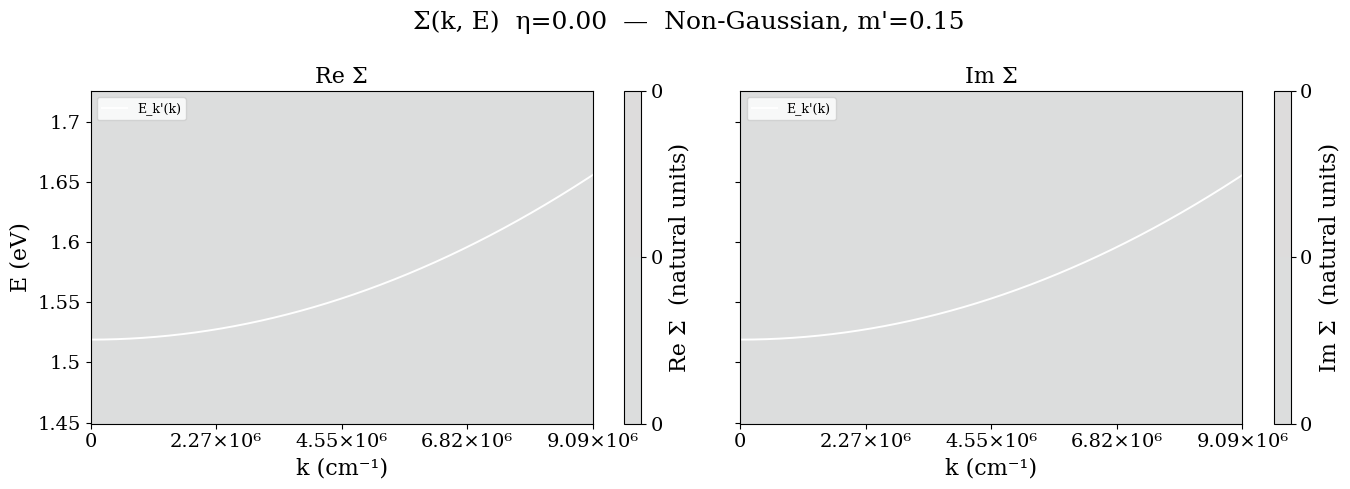

Saved  Plots/nongaussian_mprime0p15/Sigma_contour_eta_1.00_nongaussian_mprime0p15.png


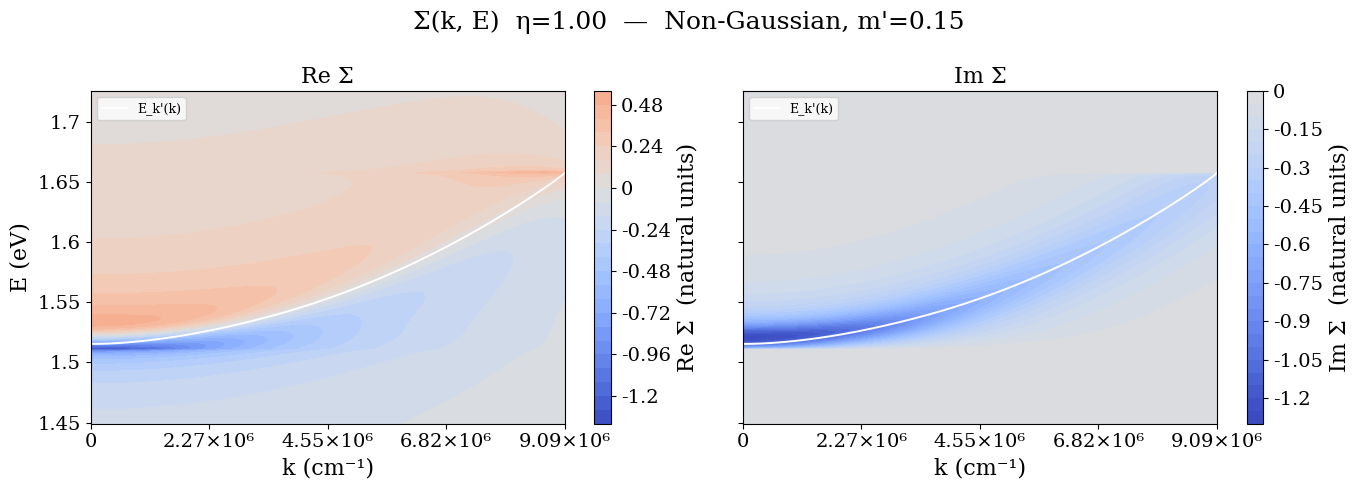

Saved  Plots/nongaussian_mprime0p15/Sigma_contour_eta_2.00_nongaussian_mprime0p15.png


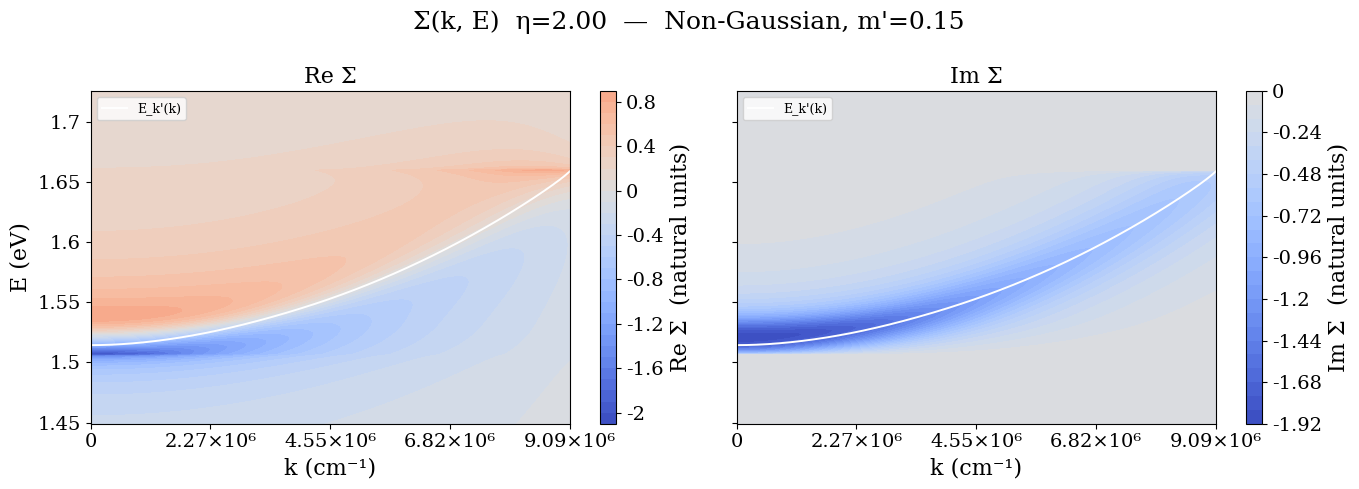

Saved  Plots/xi20nm_mprime0p15/Sigma_contour_eta_0.00_xi20nm_mprime0p15.png


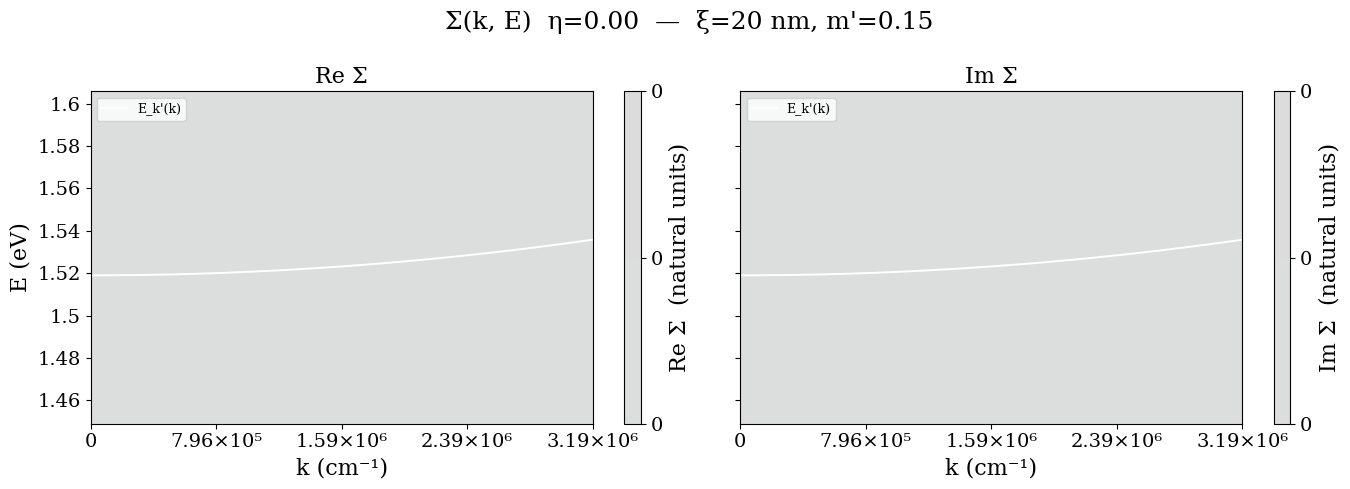

Saved  Plots/xi20nm_mprime0p15/Sigma_contour_eta_1.00_xi20nm_mprime0p15.png


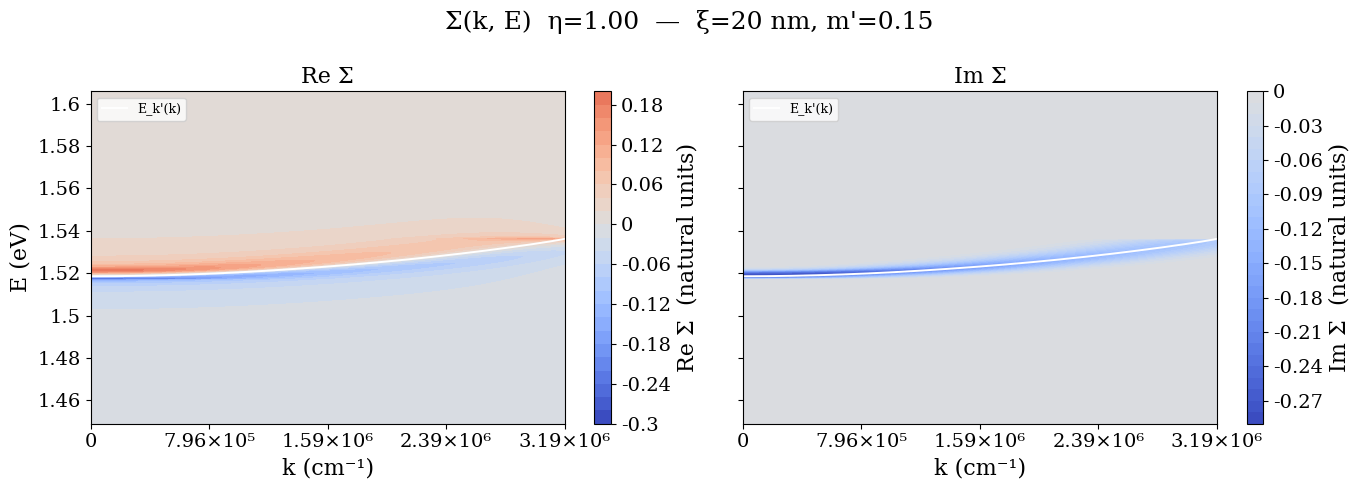

Saved  Plots/xi20nm_mprime0p15/Sigma_contour_eta_2.00_xi20nm_mprime0p15.png


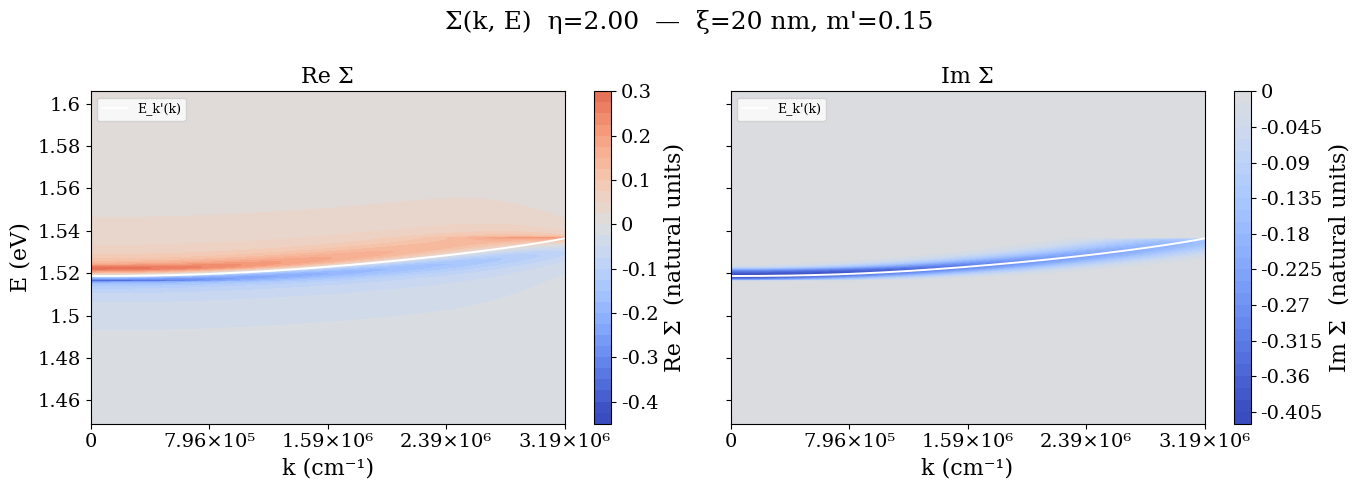

In [3]:
# Sigma contour plots Re/Im Sigma(k, E_ext), with on-shell E_k'(k) overlay.
# E_ext y-axis is shown in absolute eV (band-bottom-relative + semiconductor offset).
from matplotlib.colors import TwoSlopeNorm
from matplotlib.ticker import FuncFormatter

SIGMA_ETAS = (0.0, 1.0, 2.0)
SIGMA_CONTOUR_LEVELS = 30
SIGMA_DIVERGING_CMAP = "coolwarm"
SIGMA_COLORBAR_DECIMALS = 4


def _diverging_norm(values):
	finite = values[np.isfinite(values)]
	if finite.size == 0:
		return None
	vmax = float(np.max(np.abs(finite)))
	if vmax == 0.0:
		vmax = 1.0
	return TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)


def _select_sigma_eta_indices(eta_grid_arr, targets=SIGMA_ETAS, max_n=3):
	eta_arr = np.asarray(eta_grid_arr)
	picked = []
	for t in targets[:max_n]:
		idx = int(np.argmin(np.abs(eta_arr - float(t))))
		if idx not in picked:
			picked.append(idx)
	return picked


def _fixed_decimal_formatter(decimals=SIGMA_COLORBAR_DECIMALS):
	return FuncFormatter(lambda value, pos: format_power_value_fixed(value, decimals=decimals, zero_tol=0.0))


for plot_context in plot_contexts:
	apply_context(plot_context)
	if plot_context["Sigma_arr"] is None or plot_context["E_ext_grids_arr"] is None:
		print(f"Skipping Sigma contours for {result_label_text}: no Sigma sidecar saved.")
		continue

	Sigma         = plot_context["Sigma_arr"]
	E_k_prime     = plot_context["E_k_prime_arr"]
	E_ext_grids   = plot_context["E_ext_grids_arr"]   # (n_eta, n_E)
	q             = q_picard
	q_cm          = k_nat_to_cm_array(q, p_nat)
	t_cm          = plot_context["t_cm"]
	ticks_cm      = plot_context["dynamic_ticks_cm"]
	offset_eV     = plot_context["E_offset_eV"]

	for ei in _select_sigma_eta_indices(eta_grid):
		eta    = float(eta_grid[ei])
		E_ext  = E_ext_grids[ei]
		E_axis = energy_nat_to_eV(E_ext, p_nat) + offset_eV
		# Convert Sigma to eV for plotting (Sigma is an energy in natural units).
		Sig_re = energy_nat_to_eV(np.real(Sigma[ei]), p_nat)
		Sig_im = energy_nat_to_eV(np.imag(Sigma[ei]), p_nat)

		fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
		for ax, data, title in (
			(axs[0], Sig_re, "Re Σ"),
			(axs[1], Sig_im, "Im Σ"),
		):
			norm = _diverging_norm(data)
			cs = ax.contourf(q_cm, E_axis, data, levels=SIGMA_CONTOUR_LEVELS,
							cmap=SIGMA_DIVERGING_CMAP, norm=norm)
			cbar = fig.colorbar(cs, ax=ax, label=f"{title}  (eV)")
			apply_smart_colorbar(cbar, decimals=SIGMA_COLORBAR_DECIMALS)
			ek = E_k_prime[ei] if E_k_prime is not None else None
			if ek is not None:
				ek_eV = energy_nat_to_eV(ek, p_nat) + offset_eV
				ax.plot(q_cm, np.where(np.isfinite(ek), ek_eV, np.nan),
						color="white", lw=1.4, label="E_k'(k)")
				ax.legend(loc="upper left", fontsize=9)
			ax.set_xlabel(f"k ({CM_INV_LABEL})")
			ax.set_title(title)
			ax.set_xlim(0.0, t_cm)
			format_plot_ticks(ax, axes="x", ticks=ticks_cm, formatter="fixed_power", decimals=2)
			format_plot_ticks(ax, axes="y")
		axs[0].set_ylabel("E (eV)")
		fig.suptitle(f"Σ(k, E)  η={eta:.2f}  —  {result_label_text}", y=1.02)
		plt.tight_layout()
		save_figure(fig, f"Sigma_contour_eta_{eta:.2f}_{result_slug_text}", meta={
			**context_metadata(plot_context),
			"eta": float(eta),
			"eta_index": int(ei),
			"k_max_cm_inv": t_cm,
			"E_axis": "absolute_eV",
			"Sigma_units": "eV",
			"colorbar_decimals": SIGMA_COLORBAR_DECIMALS,
		})
		plt.show()
		plt.close(fig)



## Σ(k, E) / η at fixed external energies

For 5 fixed values of `E_ext` spanning the swept window, plot `Σ(k, E) / η`
versus k. Disorder enters the propagator only through the `−η q` prefactor,
so this normalisation collapses the η-dependence when the response is
linear in disorder and exposes the genuinely non-linear contributions.


Saved  Plots/nongaussian_mprime0p15/Sigma_over_eta_fixedE_nongaussian_mprime0p15.png


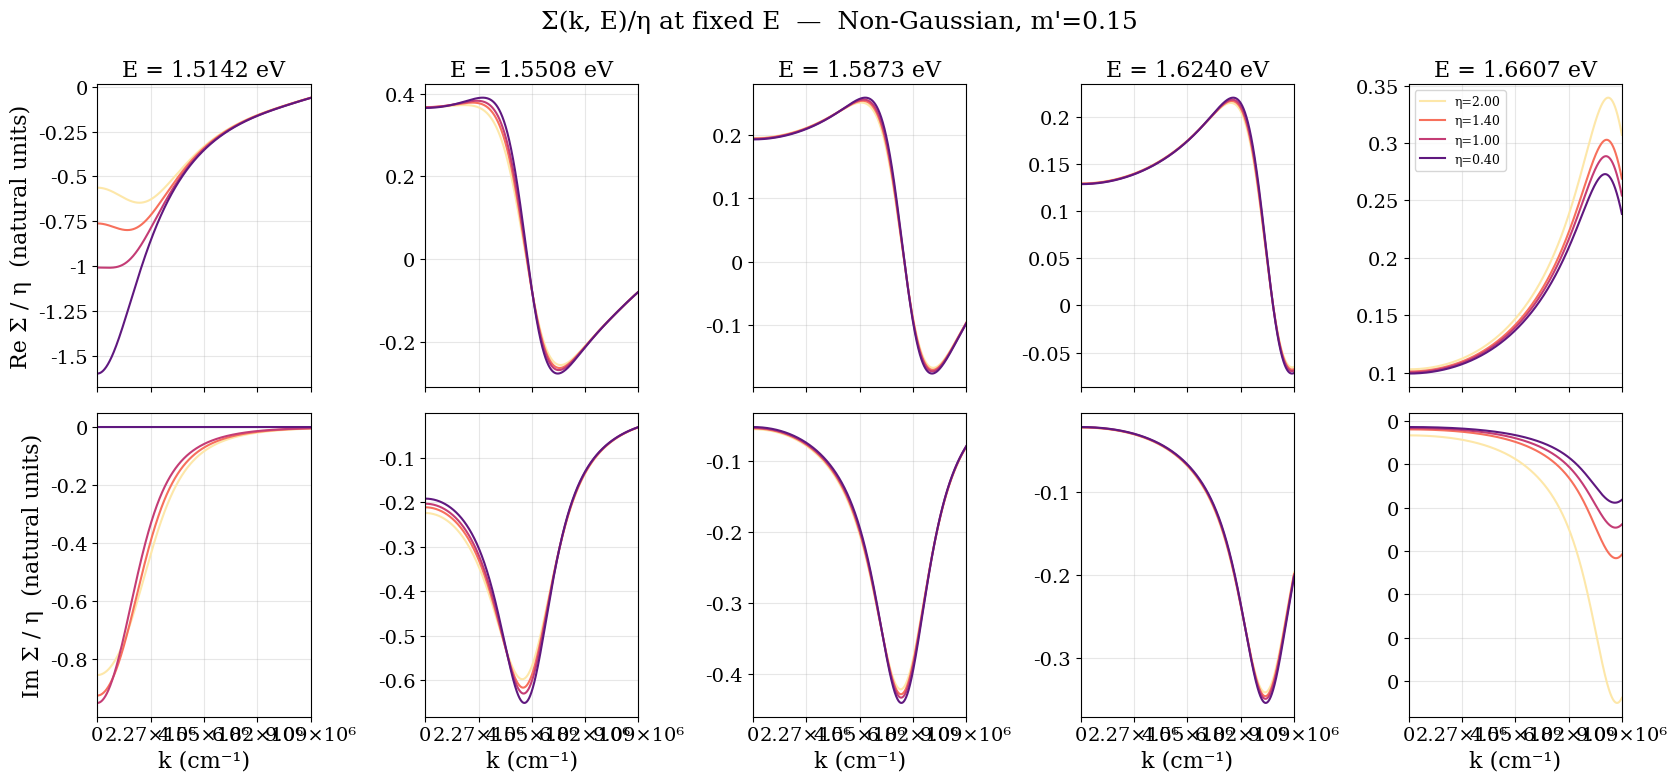

Saved  Plots/xi20nm_mprime0p15/Sigma_over_eta_fixedE_xi20nm_mprime0p15.png


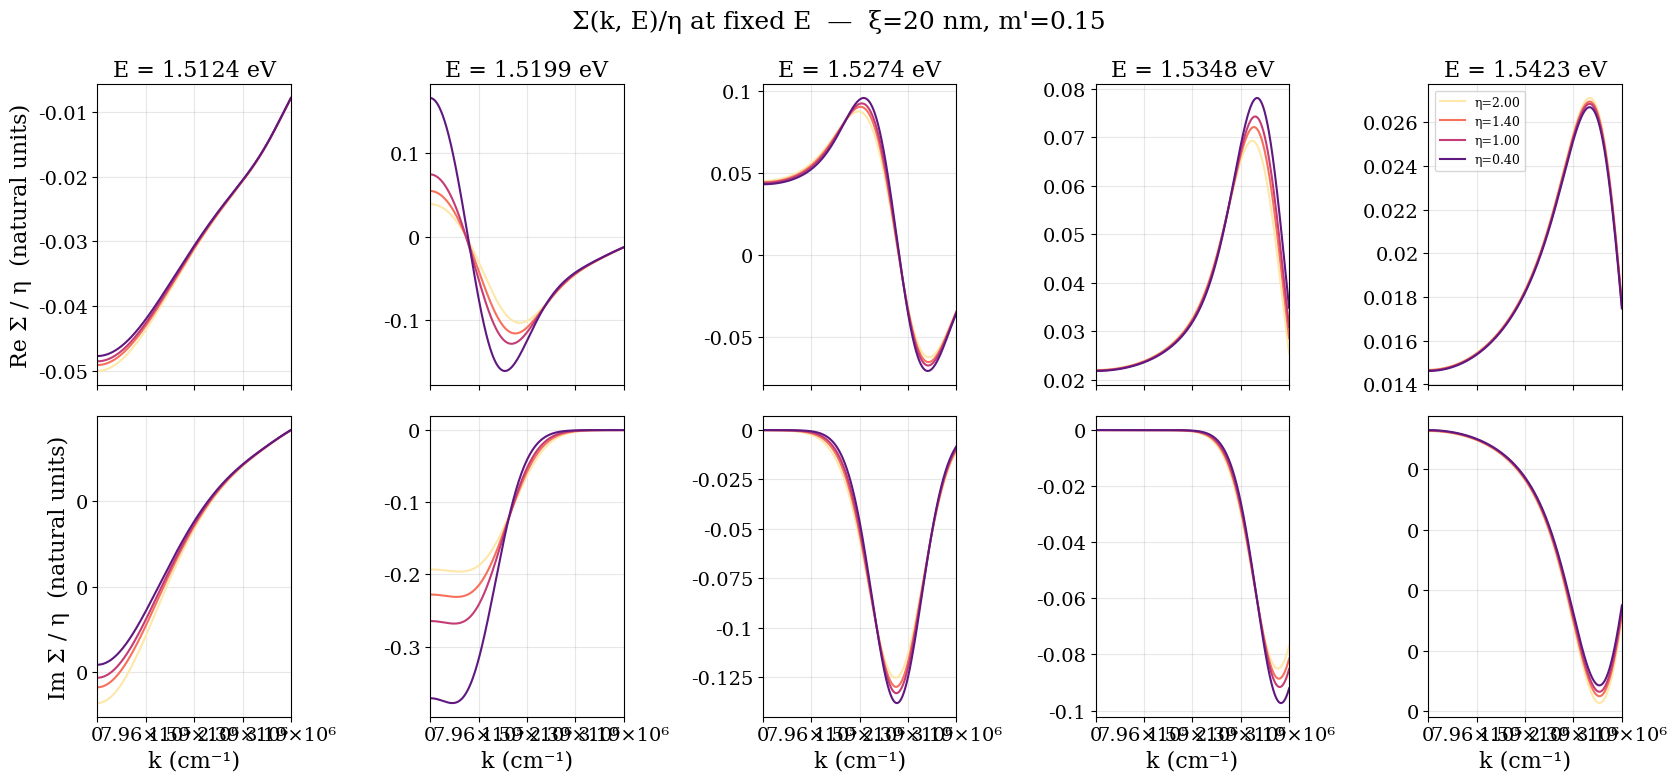

In [4]:
# Sigma(k, E_ext) / eta at 5 fixed E_ext values for each context.
# Curves are drawn only for eta > 0 (eta = 0 has Sigma identically zero).
N_FIXED_E_SLICES = 5


def _select_e_ext_indices(E_ext_arr, n=N_FIXED_E_SLICES):
	"""Evenly spaced indices into E_ext spanning the interior of the grid."""
	n_E = len(E_ext_arr)
	if n_E < n:
		return list(range(n_E))
	# Skip the very ends (they are sometimes pathological) by using a fraction.
	return list(np.linspace(int(0.1 * n_E), int(0.9 * n_E) - 1, n, dtype=int))


def _select_nonzero_eta_indices(eta_grid_arr):
	eta_arr = np.asarray(eta_grid_arr, dtype=float)
	# Reuse the descending picker, then drop eta=0 entries.
	return [i for i in selected_eta_indices() if not np.isclose(float(eta_arr[i]), 0.0)]


for plot_context in plot_contexts:
	apply_context(plot_context)
	if plot_context["Sigma_arr"] is None or plot_context["E_ext_grids_arr"] is None:
		print(f"Skipping Sigma/η slices for {result_label_text}: no Sigma sidecar saved.")
		continue

	Sigma       = plot_context["Sigma_arr"]
	E_ext_grids = plot_context["E_ext_grids_arr"]   # (n_eta, n_E)
	q_cm        = k_nat_to_cm_array(q_picard, p_nat)
	t_cm        = plot_context["t_cm"]
	ticks_cm    = plot_context["dynamic_ticks_cm"]
	offset_eV   = plot_context["E_offset_eV"]

	eta_indices = _select_nonzero_eta_indices(eta_grid)
	if not eta_indices:
		print(f"Skipping Sigma/η slices for {result_label_text}: only eta=0 available.")
		continue

	# All etas share the same E_ext grid (broadcasted), so pick from row 0.
	E_ext_arr = E_ext_grids[0]
	e_indices = _select_e_ext_indices(E_ext_arr)
	n_cols = len(e_indices)

	fig, axs = plt.subplots(2, n_cols, figsize=(3.4 * n_cols, 8), sharex=True)
	if n_cols == 1:
		axs = axs.reshape(2, 1)

	for col, ej in enumerate(e_indices):
		E_val_nat = float(E_ext_arr[ej])
		E_val_eV  = float(energy_nat_to_eV(np.array([E_val_nat]), p_nat)[0]) + offset_eV
		ax_re, ax_im = axs[0, col], axs[1, col]

		for ei in eta_indices:
			eta_val = float(eta_grid[ei])
			clr, linestyle = eta_line_style(ei, eta_val, linestyle="-")
			lbl = f"η={eta_val:.2f}"
			slice_re = np.real(Sigma[ei, ej, :]) / eta_val
			slice_im = np.imag(Sigma[ei, ej, :]) / eta_val
			ax_re.plot(q_cm, slice_re, color=clr, linestyle=linestyle, label=lbl)
			ax_im.plot(q_cm, slice_im, color=clr, linestyle=linestyle, label=lbl)

		ax_re.set_title(f"E = {E_val_eV:.4f} eV")
		ax_re.grid(alpha=0.3)
		ax_im.grid(alpha=0.3)
		ax_im.set_xlabel(f"k ({CM_INV_LABEL})")
		ax_re.set_xlim(0.0, t_cm)
		ax_im.set_xlim(0.0, t_cm)
		format_plot_ticks(ax_re, axes="x", ticks=ticks_cm, formatter="fixed_power", decimals=2)
		format_plot_ticks(ax_im, axes="x", ticks=ticks_cm, formatter="fixed_power", decimals=2)
		format_plot_ticks(ax_re, axes="y")
		format_plot_ticks(ax_im, axes="y")

	axs[0, 0].set_ylabel("Re Σ / η  (natural units)")
	axs[1, 0].set_ylabel("Im Σ / η  (natural units)")
	axs[0, -1].legend(fontsize=9, loc="best")
	fig.suptitle(f"Σ(k, E)/η at fixed E  —  {result_label_text}", y=1.0)
	plt.tight_layout()
	save_figure(fig, f"Sigma_over_eta_fixedE_{result_slug_text}", meta={
		**context_metadata(plot_context),
		"E_ext_indices": [int(j) for j in e_indices],
		"E_ext_natural": [float(E_ext_arr[j]) for j in e_indices],
		"E_ext_eV_absolute": [float(energy_nat_to_eV(np.array([E_ext_arr[j]]), p_nat)[0]) + offset_eV for j in e_indices],
		"eta_indices": [int(i) for i in eta_indices],
		"eta_values": [float(eta_grid[i]) for i in eta_indices],
		"k_max_cm_inv": t_cm,
	})
	plt.show()
	plt.close(fig)



## Picard integrand surface  K(q,k) · F(q, Q(q, E), E)

For a chosen disorder amplitude and a couple of external energies, plot the
**unintegrated** Picard integrand as a 2-D surface over (k, q):

$$\\mathcal{I}(q, k; E, \\eta) = K(q, k) \\; F\\!\\big(q,\\; Q(q, E),\\; E,\\; \\eta\\big)$$

where `Q(q, E) = -Σ(q, E)` is read off the saved Picard fixed point. Integrating
$\\mathcal{I}$ over `q` against the trapezoidal weights returns the Picard map
that produces `Σ(k, E)`; visualising the integrand directly shows which `q`
regions dominate the kernel sum at each `k`.


Saved  Plots/nongaussian_mprime0p15/integrand_surface_nongaussian_mprime0p15.png


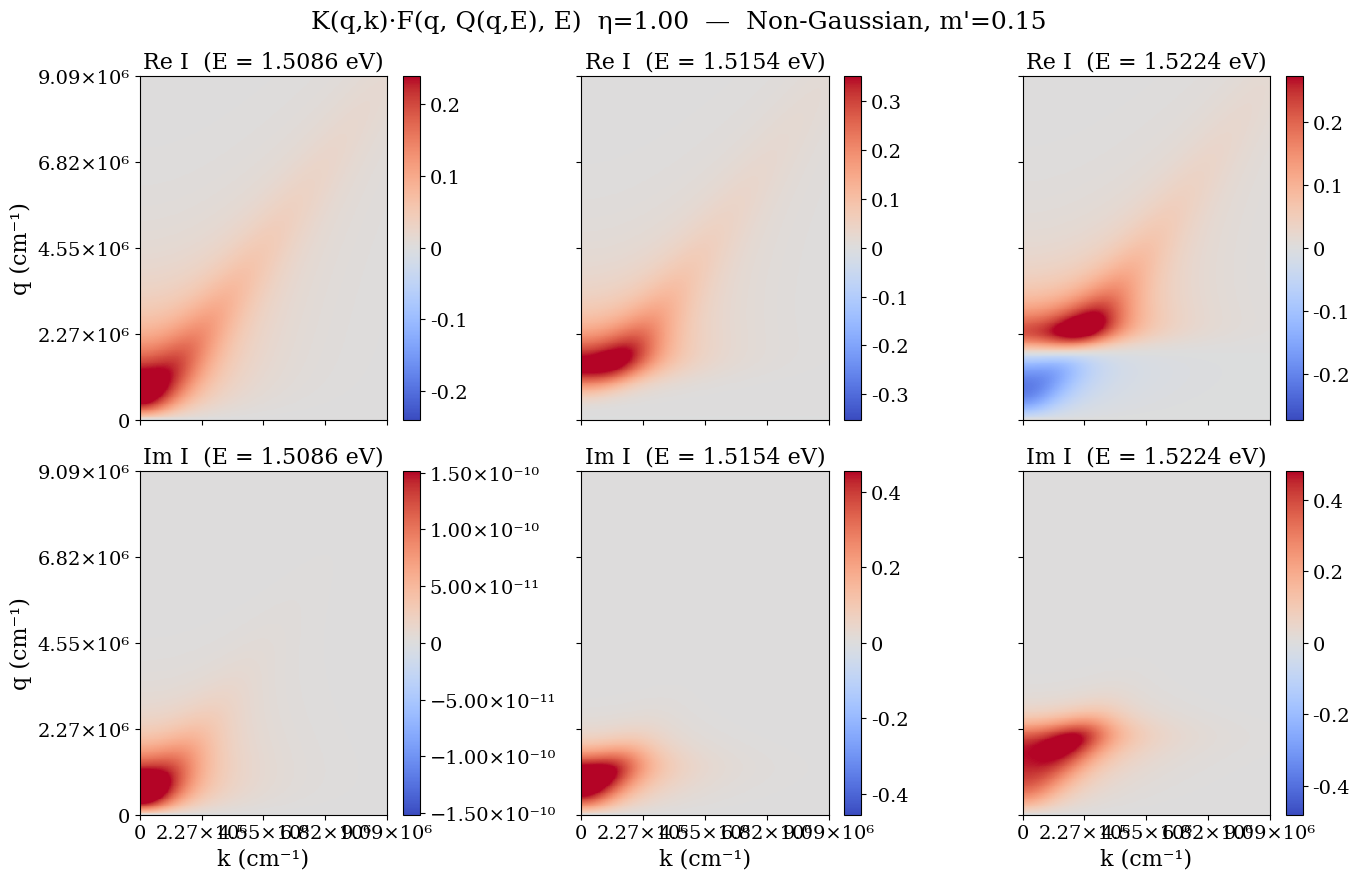

Saved  Plots/xi20nm_mprime0p15/integrand_surface_xi20nm_mprime0p15.png


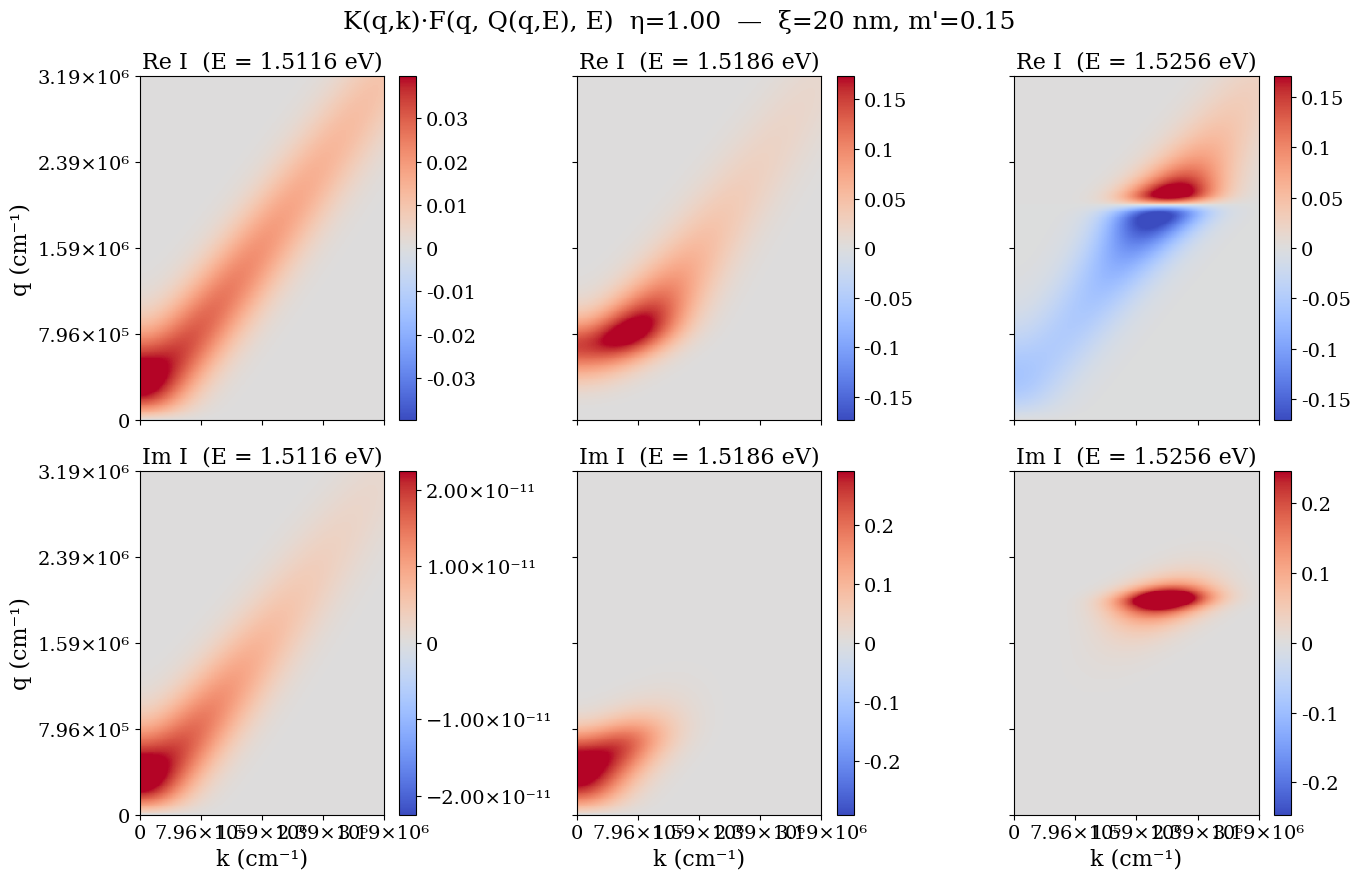

In [5]:
# Picard integrand surface I(q, k; E, eta) = K(q,k) * F(q, Q(q, E), E, eta).
# Plots Re/Im I as pcolormesh panels for a few fixed E values at one eta.
from polaritons.kernel import make_propagator

INTEGRAND_ETA_TARGET     = 1.0          # eta value to use (nearest match picked)
INTEGRAND_E_REFERENCE_K_CM = 40_000.0   # E values are picked near Re E_ex at this k (cm^-1)
INTEGRAND_E_SPACING_FRAC  = 0.5         # spacing of the three E columns as a fraction of Omega
INTEGRAND_MAX_GRID_POINTS = 400         # downsample axes for plotting / memory
INTEGRAND_PERCENTILE     = 99.0         # robust colour-scale percentile


def _downsample_indices(n: int, target: int = INTEGRAND_MAX_GRID_POINTS):
	if n <= target:
		return np.arange(n)
	stride = int(np.ceil(n / target))
	idx = np.unique(np.r_[np.arange(0, n, stride), n - 1])
	return idx


for plot_context in plot_contexts:
	apply_context(plot_context)
	if plot_context["Sigma_arr"] is None or plot_context["E_ext_grids_arr"] is None:
		print(f"Skipping integrand surface for {result_label_text}: no Sigma sidecar saved.")
		continue
	if kernel_stem is None:
		print(f"Skipping integrand surface for {result_label_text}: no kernel_stem in Q metadata.")
		continue

	K_mesh, k_meta = load_result("Results/integrand_meshes", kernel_stem)
	q_all          = np.array(k_meta["q_picard"])
	if K_mesh.shape != (len(q_all), len(q_all)) or len(q_all) != len(q_picard):
		print(f"Skipping integrand surface for {result_label_text}: kernel/Q grid mismatch.")
		continue

	ei = int(np.argmin(np.abs(eta_grid - INTEGRAND_ETA_TARGET)))
	eta_val = float(eta_grid[ei])
	if np.isclose(eta_val, 0.0):
		print(f"Skipping integrand surface for {result_label_text}: nearest eta is 0.")
		continue

	F_full   = make_propagator(p_nat)
	E_ext_arr = plot_context["E_ext_grids_arr"][ei]
	n_E       = len(E_ext_arr)

	# Pick three E columns clustered around Re E_ex(k_ref, eta_used), spaced by
	# INTEGRAND_E_SPACING_FRAC * Omega.  Snap each to the nearest E_ext sample
	# and drop duplicates / out-of-range targets.
	k_ref_nat   = float(k_cm_to_nat(INTEGRAND_E_REFERENCE_K_CM, p_nat))
	E_target    = float(np.real(model.E_ex(np.array([k_ref_nat]), eta_val)[0]))
	Omega_nat   = float(np.real(p_nat.Omega))
	E_offsets   = np.array([-1.0, 0.0, 1.0]) * INTEGRAND_E_SPACING_FRAC * Omega_nat
	E_targets   = E_target + E_offsets
	e_indices   = []
	for E_t in E_targets:
		j = int(np.argmin(np.abs(E_ext_arr - E_t)))
		if j not in e_indices:
			e_indices.append(j)
	e_indices = sorted(e_indices)

	q_idx = _downsample_indices(len(q_picard))
	q_sub = q_picard[q_idx]
	q_sub_cm = k_nat_to_cm_array(q_sub, p_nat)
	t_cm     = plot_context["t_cm"]
	ticks_cm = plot_context["dynamic_ticks_cm"]
	offset_eV = plot_context["E_offset_eV"]

	n_cols = len(e_indices)
	fig, axs = plt.subplots(2, n_cols, figsize=(4.6 * n_cols, 9), sharex=True, sharey=True)
	if n_cols == 1:
		axs = axs.reshape(2, 1)

	panel_meta = []
	for col, ej in enumerate(e_indices):
		E_val_nat = float(E_ext_arr[ej])
		E_val_eV  = float(energy_nat_to_eV(np.array([E_val_nat]), p_nat)[0]) + offset_eV

		# Q(q) along the full natural grid at (eta_val, E_val_nat).
		Q_full = -plot_context["Sigma_arr"][ei, ej, :]
		F_vec  = F_full(q_picard, Q_full, E_ext=E_val_nat, eta=eta_val)  # (N,)

		# Full integrand K[q, k] * F[q]: rows indexed by q, columns by k.
		integrand_full = K_mesh * F_vec[:, None]
		integrand_sub  = integrand_full[np.ix_(q_idx, q_idx)]
		re_sub = np.real(integrand_sub)
		im_sub = np.imag(integrand_sub)

		for row, (data, label) in enumerate([
			(re_sub, f"Re I  (E = {E_val_eV:.4f} eV)"),
			(im_sub, f"Im I  (E = {E_val_eV:.4f} eV)"),
		]):
			ax = axs[row, col]
			finite = data[np.isfinite(data)]
			if finite.size:
				vmax = float(np.percentile(np.abs(finite), INTEGRAND_PERCENTILE))
				if vmax == 0.0:
					vmax = float(np.max(np.abs(finite))) or 1.0
			else:
				vmax = 1.0
			norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)
			mesh = ax.pcolormesh(q_sub_cm, q_sub_cm, data, shading="auto",
								cmap=SIGMA_DIVERGING_CMAP, norm=norm)
			cbar = fig.colorbar(mesh, ax=ax)
			apply_smart_colorbar(cbar)
			ax.set_title(label, fontsize=11)
			ax.set_xlim(0.0, t_cm)
			ax.set_ylim(0.0, t_cm)
			format_plot_ticks(ax, axes=("x", "y"), ticks=ticks_cm, formatter="fixed_power", decimals=2)
			if row == 1:
				ax.set_xlabel(f"k ({CM_INV_LABEL})")
			if col == 0:
				ax.set_ylabel(f"q ({CM_INV_LABEL})")
		panel_meta.append({
			"E_ext_index"   : int(ej),
			"E_ext_natural" : E_val_nat,
			"E_ext_eV_absolute": E_val_eV,
			"abs_percentile_max": float(vmax),
		})

	fig.suptitle(f"K(q,k)·F(q, Q(q,E), E)  η={eta_val:.2f}  —  {result_label_text}", y=1.0)
	plt.tight_layout()
	save_figure(fig, f"integrand_surface_{result_slug_text}", meta={
		**context_metadata(plot_context),
		"eta_target"      : INTEGRAND_ETA_TARGET,
		"eta_used"        : eta_val,
		"eta_index"       : int(ei),
		"E_panels"        : panel_meta,
		"E_reference_k_cm_inv": INTEGRAND_E_REFERENCE_K_CM,
		"E_reference_nat" : E_target,
		"E_spacing_frac_of_Omega": INTEGRAND_E_SPACING_FRAC,
		"downsample_points": int(len(q_idx)),
		"abs_percentile"  : INTEGRAND_PERCENTILE,
		"k_max_cm_inv"    : t_cm,
		"q_max_cm_inv"    : t_cm,
	})
	plt.show()
	plt.close(fig)



## Propagator denominator and spectral function

`Re[E − ℏ²k²/(2M) − Σ]` (zero contour = on-shell condition) and the spectral function `A(k, E) = -2 Im[1/denom]` for up to three η values per result.


Saved  Plots/nongaussian_mprime0p15/propagator_eta_0.00_nongaussian_mprime0p15.png


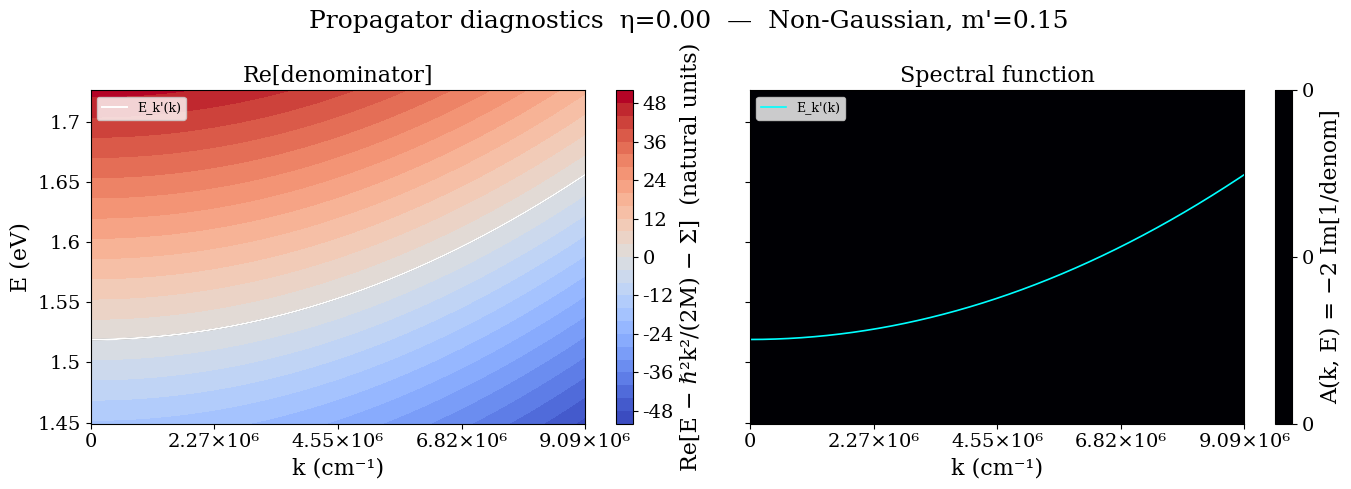

Saved  Plots/nongaussian_mprime0p15/propagator_eta_1.00_nongaussian_mprime0p15.png


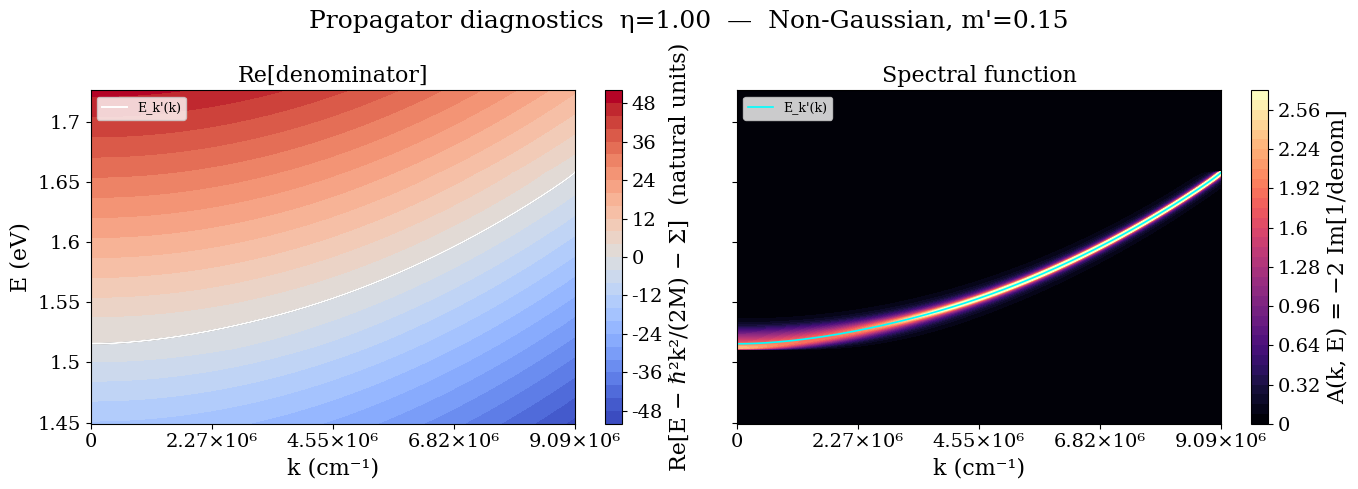

Saved  Plots/nongaussian_mprime0p15/propagator_eta_2.00_nongaussian_mprime0p15.png


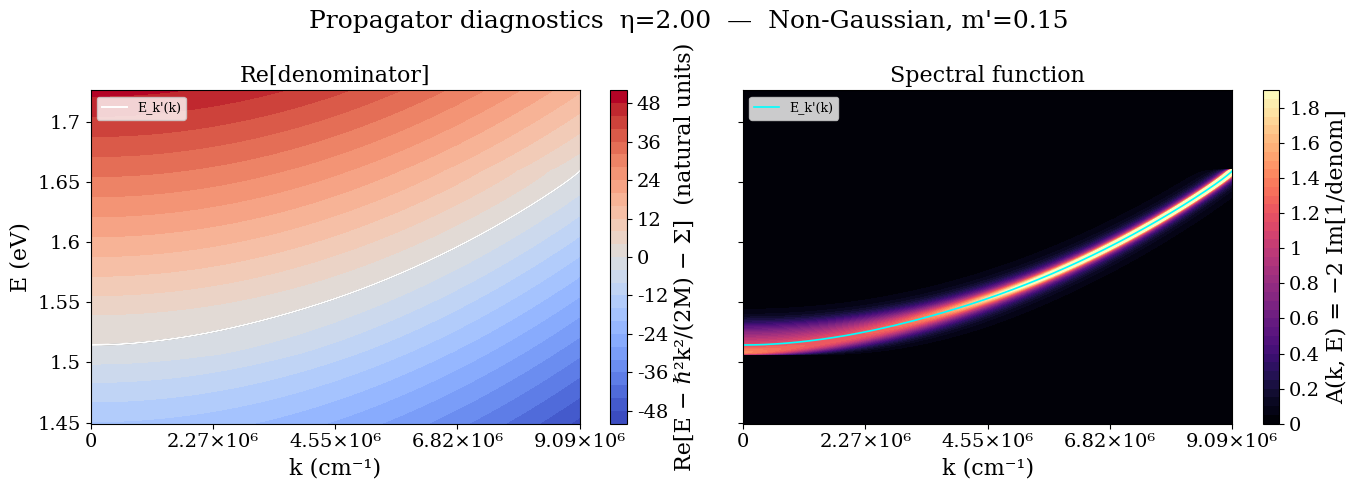

Saved  Plots/xi20nm_mprime0p15/propagator_eta_0.00_xi20nm_mprime0p15.png


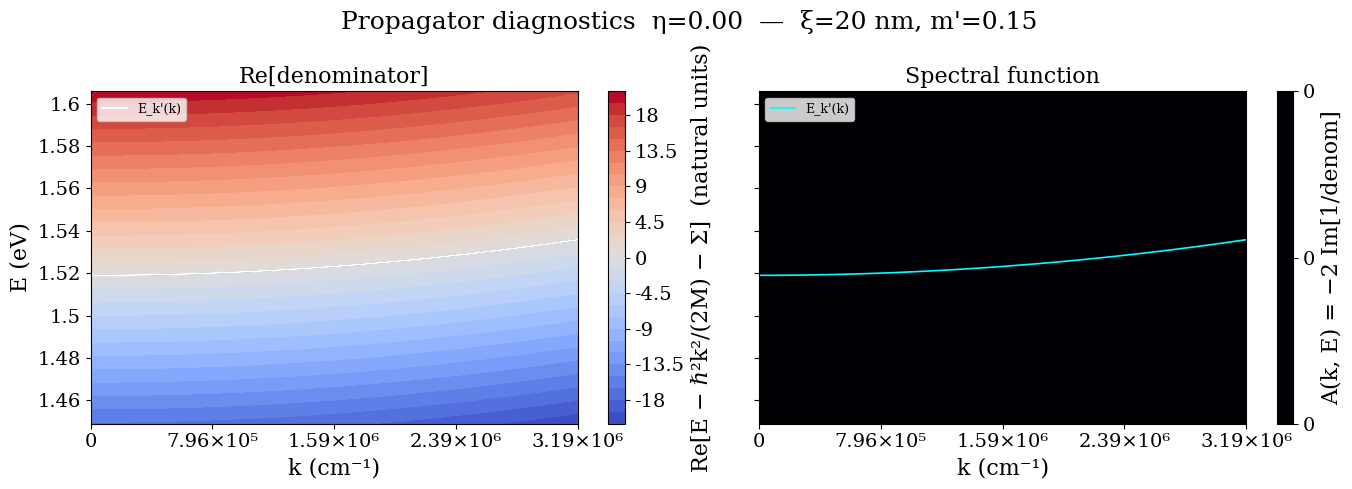

Saved  Plots/xi20nm_mprime0p15/propagator_eta_1.00_xi20nm_mprime0p15.png


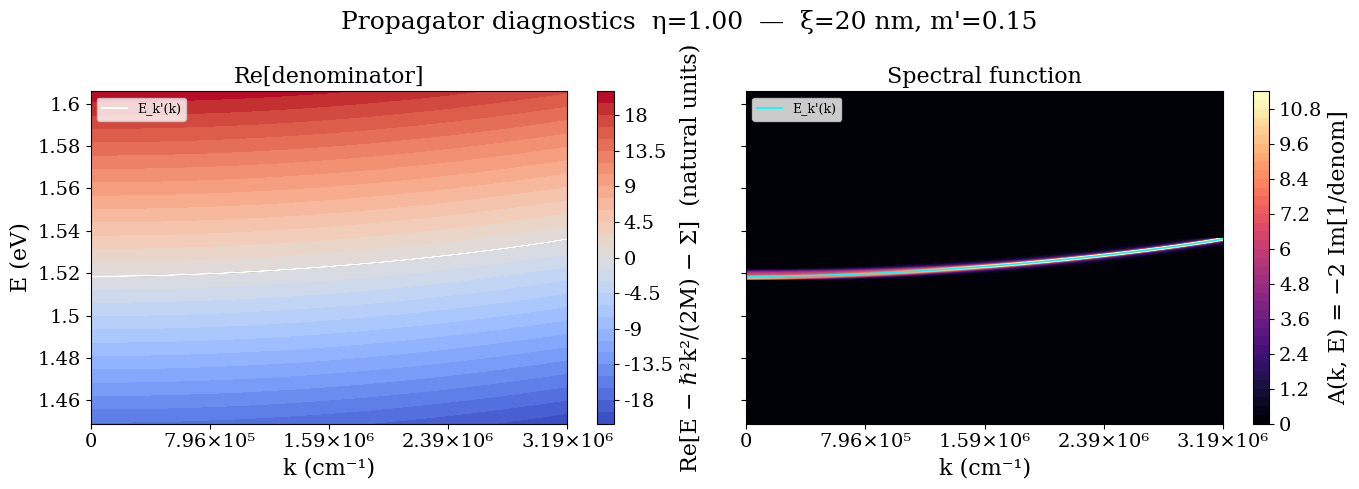

Saved  Plots/xi20nm_mprime0p15/propagator_eta_2.00_xi20nm_mprime0p15.png


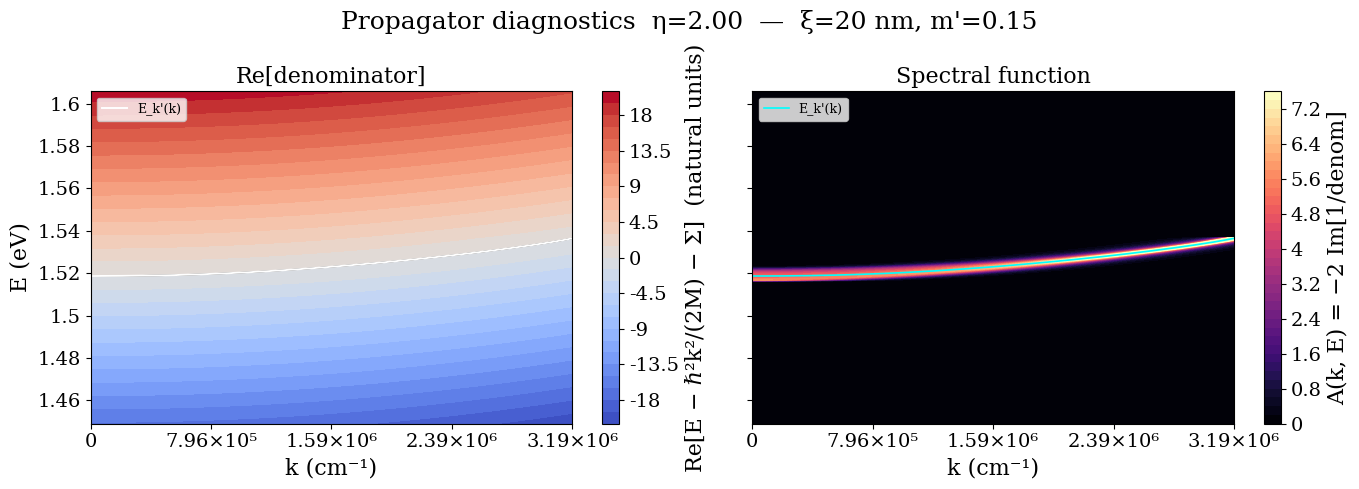

In [6]:
# Propagator denominator (signed) + spectral function (magma).
# E_ext y-axis is shown in absolute eV.
SPECTRAL_CONTOUR_LEVELS = 40
SPECTRAL_PERCENTILE     = 99.0


for plot_context in plot_contexts:
	apply_context(plot_context)
	if plot_context["Sigma_arr"] is None or plot_context["E_ext_grids_arr"] is None:
		print(f"Skipping propagator diagnostics for {result_label_text}: no Sigma sidecar saved.")
		continue

	Sigma       = plot_context["Sigma_arr"]
	E_k_prime   = plot_context["E_k_prime_arr"]
	E_ext_grids = plot_context["E_ext_grids_arr"]
	q           = q_picard
	q_cm        = k_nat_to_cm_array(q, p_nat)
	t_cm        = plot_context["t_cm"]
	ticks_cm    = plot_context["dynamic_ticks_cm"]
	offset_eV   = plot_context["E_offset_eV"]

	bare = (p_nat.hbar**2 * q**2) / (2.0 * p_nat.M)

	for ei in _select_sigma_eta_indices(eta_grid):
		eta    = float(eta_grid[ei])
		E_ext  = E_ext_grids[ei]
		E_axis = energy_nat_to_eV(E_ext, p_nat) + offset_eV

		denom    = E_ext[:, None] - bare[None, :] - Sigma[ei]
		re_denom = np.real(denom)
		spectral = -2.0 * np.imag(1.0 / denom)

		fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

		norm = _diverging_norm(re_denom)
		cs0 = axs[0].contourf(q_cm, E_axis, re_denom, levels=SIGMA_CONTOUR_LEVELS,
							cmap=SIGMA_DIVERGING_CMAP, norm=norm)
		cbar0 = fig.colorbar(cs0, ax=axs[0], label="Re[E − ℏ²k²/(2M) − Σ]  (natural units)")
		apply_smart_colorbar(cbar0)
		axs[0].contour(q_cm, E_axis, re_denom, levels=[0.0], colors="black", linewidths=1.0)
		ek = E_k_prime[ei] if E_k_prime is not None else None
		if ek is not None:
			ek_eV = energy_nat_to_eV(ek, p_nat) + offset_eV
			axs[0].plot(q_cm, np.where(np.isfinite(ek), ek_eV, np.nan),
						color="white", lw=1.4, label="E_k'(k)")
			axs[0].legend(loc="upper left", fontsize=9)
		axs[0].set_title("Re[denominator]")
		axs[0].set_xlabel(f"k ({CM_INV_LABEL})")
		axs[0].set_ylabel("E (eV)")

		finite = spectral[np.isfinite(spectral)]
		vmax = float(np.percentile(finite, SPECTRAL_PERCENTILE)) if finite.size else 1.0
		if vmax <= 0.0:
			vmax = float(np.max(finite)) if finite.size else 1.0
		if vmax <= 0.0:
			vmax = 1.0
		cs1 = axs[1].contourf(q_cm, E_axis, np.clip(spectral, 0.0, vmax),
							levels=SPECTRAL_CONTOUR_LEVELS, cmap=CMAP_NAME,
							vmin=0.0, vmax=vmax)
		cbar1 = fig.colorbar(cs1, ax=axs[1], label="A(k, E) = −2 Im[1/denom]")
		apply_smart_colorbar(cbar1)
		if ek is not None:
			ek_eV = energy_nat_to_eV(ek, p_nat) + offset_eV
			axs[1].plot(q_cm, np.where(np.isfinite(ek), ek_eV, np.nan),
						color="cyan", lw=1.2, label="E_k'(k)")
			axs[1].legend(loc="upper left", fontsize=9)
		axs[1].set_title("Spectral function")
		axs[1].set_xlabel(f"k ({CM_INV_LABEL})")

		for ax in axs:
			ax.set_xlim(0.0, t_cm)
			format_plot_ticks(ax, axes="x", ticks=ticks_cm, formatter="fixed_power", decimals=2)
			format_plot_ticks(ax, axes="y")

		fig.suptitle(f"Propagator diagnostics  η={eta:.2f}  —  {result_label_text}", y=1.02)
		plt.tight_layout()
		save_figure(fig, f"propagator_eta_{eta:.2f}_{result_slug_text}", meta={
			**context_metadata(plot_context),
			"eta": float(eta),
			"eta_index": int(ei),
			"k_max_cm_inv": t_cm,
			"spectral_percentile": SPECTRAL_PERCENTILE,
			"E_axis": "absolute_eV",
		})
		plt.show()
		plt.close(fig)


## On-shell pole E_k′(k)


Saved  Plots/nongaussian_mprime0p15/E_k_prime_nongaussian_mprime0p15.png


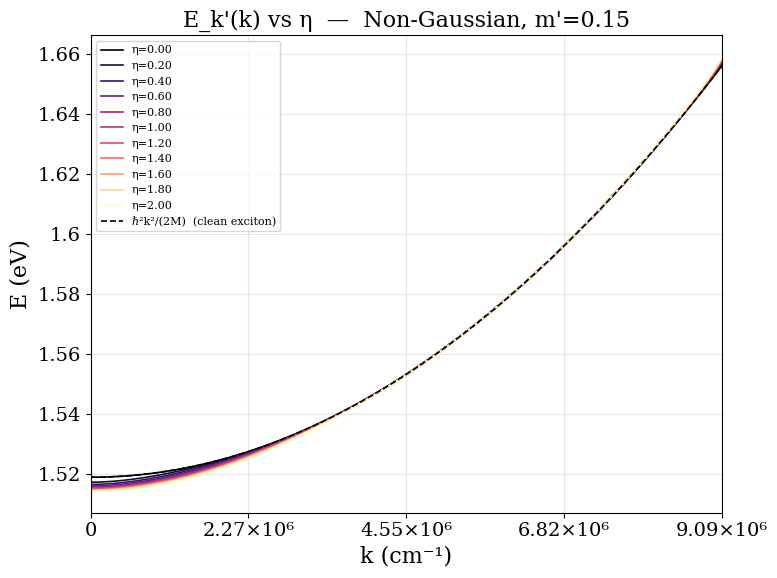

Saved  Plots/xi20nm_mprime0p15/E_k_prime_xi20nm_mprime0p15.png


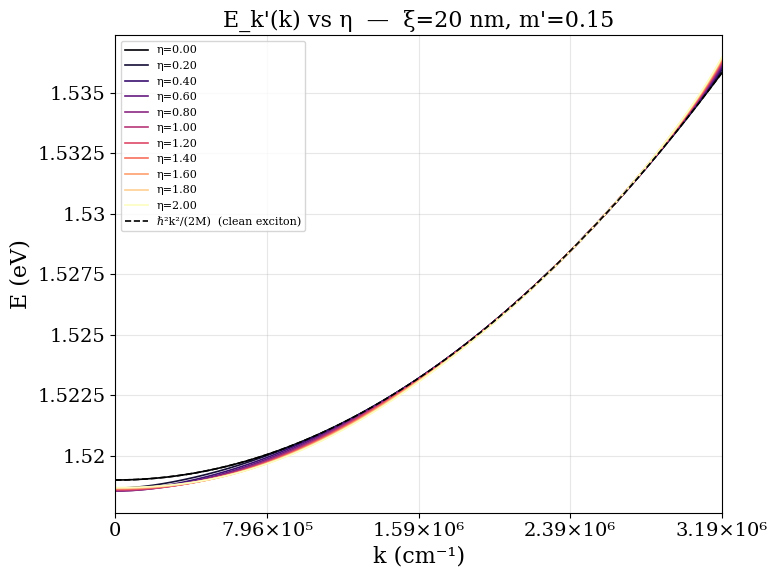

In [7]:
# E_k'(k) for each η, with the bare clean-exciton parabola overlay.
# All energies plotted in absolute eV.

for plot_context in plot_contexts:
	apply_context(plot_context)
	E_k_prime = plot_context["E_k_prime_arr"]
	if E_k_prime is None:
		print(f"Skipping E_k' diagnostic for {result_label_text}: no sidecar saved.")
		continue

	q         = q_picard
	q_cm      = k_nat_to_cm_array(q, p_nat)
	offset_eV = plot_context["E_offset_eV"]
	t_cm      = plot_context["t_cm"]
	ticks_cm  = plot_context["dynamic_ticks_cm"]
	cmap_eta  = plt.get_cmap("magma")

	bare    = (p_nat.hbar**2 * q**2) / (2.0 * p_nat.M)
	bare_eV = energy_nat_to_eV(bare, p_nat) + offset_eV

	fig, ax = plt.subplots(figsize=(8, 6))
	n_eta_local = len(eta_grid)
	for ei, eta in enumerate(eta_grid):
		colour = cmap_eta(ei / max(1, n_eta_local - 1))
		ek    = E_k_prime[ei]
		ek_eV = energy_nat_to_eV(ek, p_nat) + offset_eV
		ax.plot(q_cm, np.where(np.isfinite(ek), ek_eV, np.nan),
		        color=colour, lw=1.2, label=f"η={float(eta):.2f}")
	ax.plot(q_cm, bare_eV, "k--", lw=1.2, label="ℏ²k²/(2M)  (clean exciton)")

	ax.set_xlabel(f"k ({CM_INV_LABEL})")
	ax.set_ylabel("E (eV)")
	ax.set_title(f"E_k'(k) vs η  —  {result_label_text}")
	ax.set_xlim(0.0, t_cm)
	ax.grid(alpha=0.3)
	format_plot_ticks(ax, axes="x", ticks=ticks_cm, formatter="fixed_power", decimals=2)
	format_plot_ticks(ax, axes="y")

	if n_eta_local > 8:
		handles, labels = ax.get_legend_handles_labels()
		step = max(1, n_eta_local // 6)
		keep = list(range(0, n_eta_local, step)) + [len(handles) - 1]
		ax.legend([handles[i] for i in keep], [labels[i] for i in keep], fontsize=8, loc="best")
	else:
		ax.legend(fontsize=9, loc="best")

	nan_any = np.isnan(E_k_prime).any(axis=0)
	if nan_any.any():
		idx = np.flatnonzero(nan_any)
		splits = np.split(idx, np.flatnonzero(np.diff(idx) > 1) + 1)
		for blk in splits:
			ax.axvspan(q_cm[blk[0]], q_cm[blk[-1]], color="red", alpha=0.08)
		print(f"  {plot_context['kernel_type']}: {nan_any.sum()} k-points have at least one NaN over η")

	plt.tight_layout()
	save_figure(fig, f"E_k_prime_{result_slug_text}", meta={
		**context_metadata(plot_context),
		"k_max_cm_inv": t_cm,
		"E_axis": "absolute_eV",
	})
	plt.show()
	plt.close(fig)


Saved  Plots/nongaussian_mprime0p15/Q_diagnostics_nongaussian_mprime0p15.png


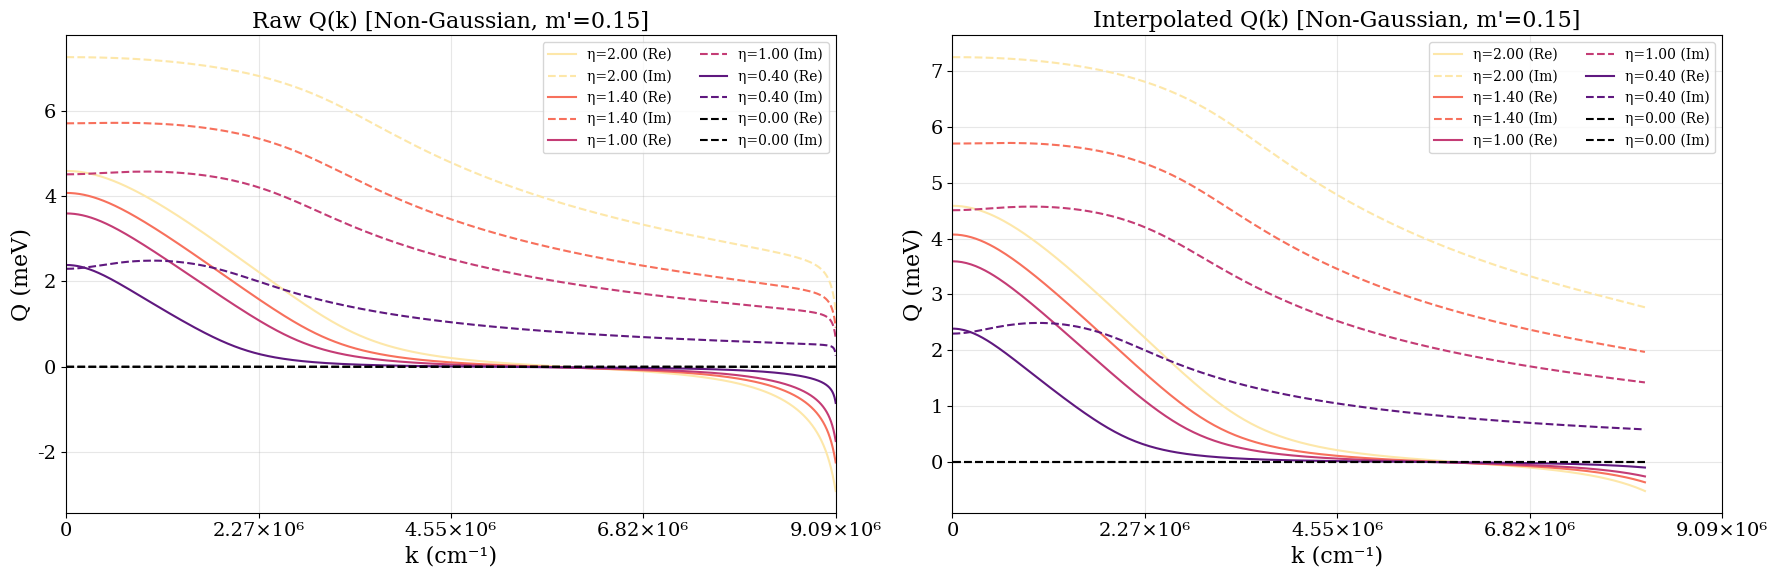

Saved  Plots/xi20nm_mprime0p15/Q_diagnostics_xi20nm_mprime0p15.png


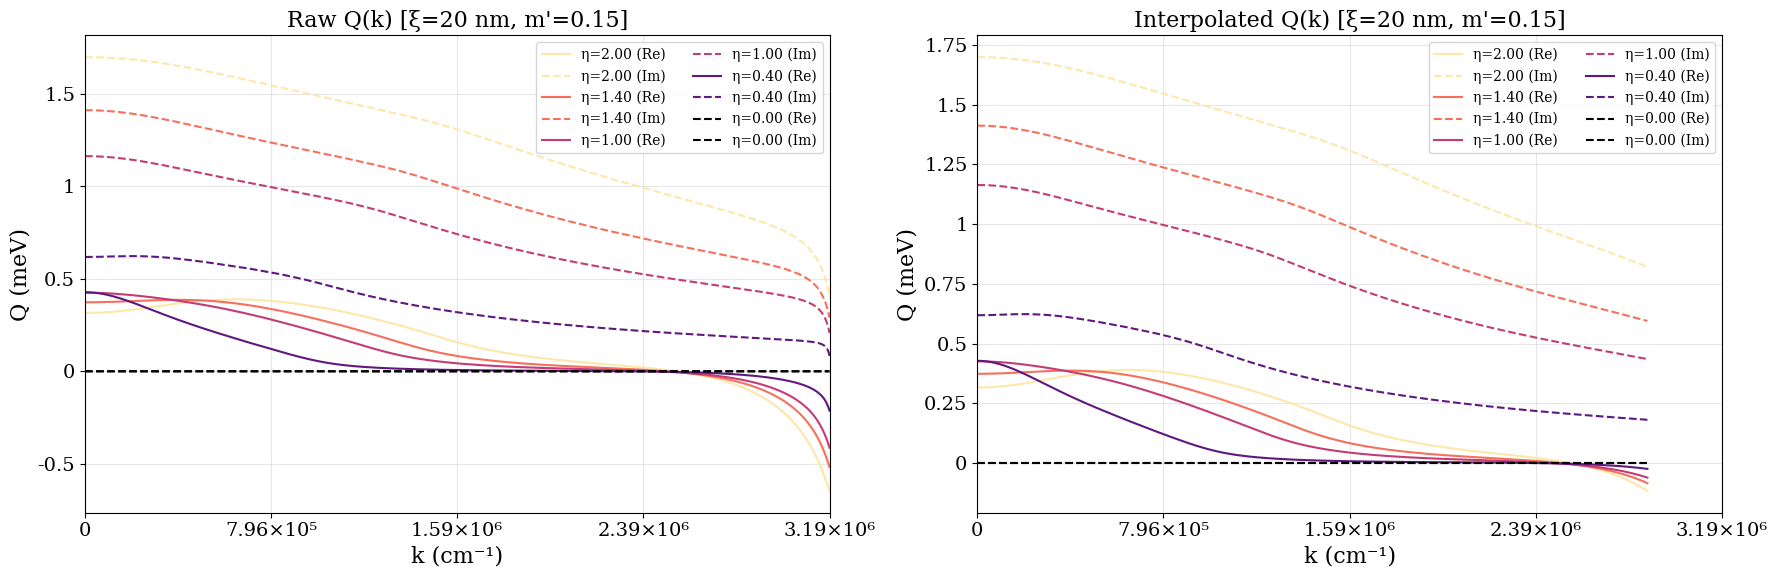

In [8]:
# Q plot x-range is dynamic per context: spans [0, t_cm] where t is the
# kernel truncation in cm^-1.


for plot_context in plot_contexts:
	apply_context(plot_context)
	plot_eta_idx = selected_eta_indices()
	q_positive = q_picard > 0.0
	q_plot_cm = k_nat_to_cm_array(q_picard[q_positive], p_nat)
	q_unit_values, q_unit_label, q_max_abs_eV = q_energy_values(Q_results[plot_eta_idx][:, q_positive], p_nat)

	fig, axs = plt.subplots(1, 2, figsize=(18, 6))

	for local_i, idx in enumerate(plot_eta_idx):
		eta_value = float(eta_grid[idx])
		real_color, real_linestyle = eta_line_style(idx, eta_value, linestyle="-")
		imag_color, imag_linestyle = eta_line_style(idx, eta_value, linestyle="--")
		lbl = f"η={eta_value:.2f}"
		axs[0].plot(q_plot_cm, np.real(q_unit_values[local_i]),
					color=real_color, linestyle=real_linestyle, label=f"{lbl} (Re)")
		axs[0].plot(q_plot_cm, np.imag(q_unit_values[local_i]),
					color=imag_color, linestyle=imag_linestyle, label=f"{lbl} (Im)")

		k_nat_test = np.linspace(first_positive_k, 0.9 * k_domain_max, 300)
		k_test_cm = k_nat_to_cm_array(k_nat_test, p_nat)
		Q_interp  = model.Q(k_nat_test, eta_grid[idx])
		Q_interp_unit = energy_nat_to_meV(Q_interp, p_nat) if q_unit_label == "meV" else energy_nat_to_eV(Q_interp, p_nat)
		axs[1].plot(k_test_cm, np.real(Q_interp_unit),
					color=real_color, linestyle=real_linestyle, label=f"{lbl} (Re)")
		axs[1].plot(k_test_cm, np.imag(Q_interp_unit),
					color=imag_color, linestyle=imag_linestyle, label=f"{lbl} (Im)")

	for ax, title in zip(axs, ["Raw Q(k)", "Interpolated Q(k)"]):
		ax.set_xlabel(f"k ({CM_INV_LABEL})")
		ax.set_ylabel(f"Q ({q_unit_label})")
		ax.set_title(f"{title} [{result_label_text}]")
		ax.legend(ncol=2, fontsize=10)
		ax.grid(alpha=0.3)
		ax.set_xlim(0.0, plot_context["t_cm"])
		format_plot_ticks(ax, axes="x", ticks=plot_context["dynamic_ticks_cm"], formatter="fixed_power", decimals=2)
		format_plot_ticks(ax, axes="y")

	plt.tight_layout()
	save_figure(fig, f"Q_diagnostics_{result_slug_text}", meta={
		**context_metadata(plot_context),
		"eta_indices": list(plot_eta_idx),
		"Q_unit": q_unit_label,
		"Q_max_abs_eV": q_max_abs_eV,
		"k_max_cm_inv": plot_context["t_cm"],
	})
	plt.show()
	plt.close(fig)


## Kernel contour K(q,k)

Downsampled from the saved Picard kernel mesh, normalized by its maximum value, and plotted on a linear color scale.


Saved  Plots/nongaussian_mprime0p15/K_contour_nongaussian_mprime0p15.png


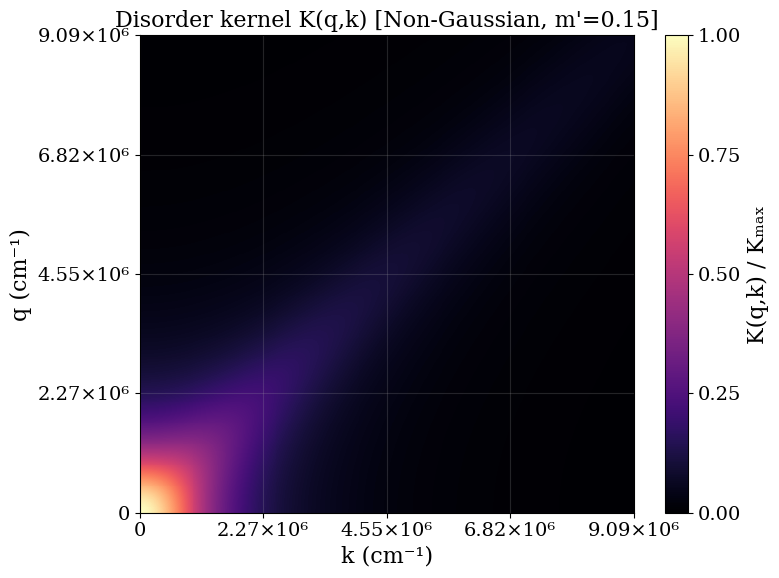

Saved  Plots/xi20nm_mprime0p15/K_contour_xi20nm_mprime0p15.png


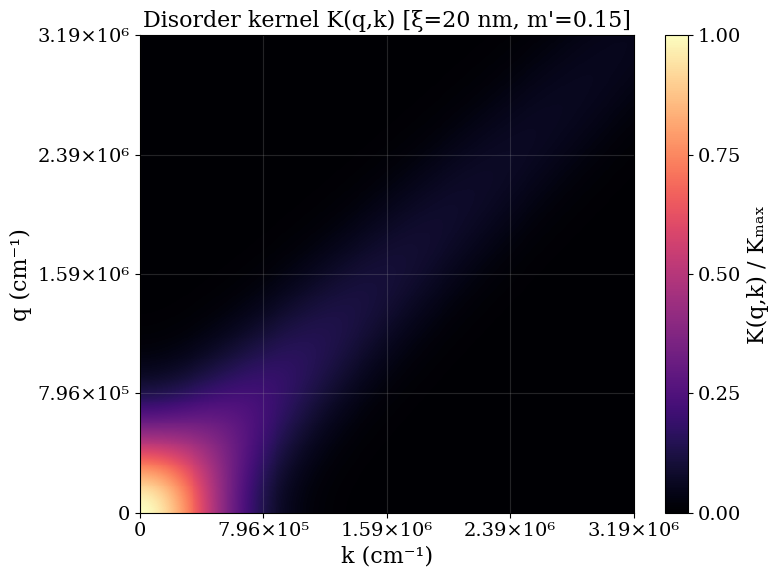

In [9]:
# Kernel contour plot K(q,k), downsampled from the saved Picard mesh.
K_CONTOUR_POINTS = 500
# K contour x/y range is dynamic per context: spans [0, t_cm].
K_COLOR_TICKS = [0.0, 0.25, 0.50, 0.75, 1.0]

for plot_context in plot_contexts:
	apply_context(plot_context)
	if kernel_stem is None:
		print(f"Skipping K contour for {result_label_text}: no kernel_stem in Q metadata")
		continue

	K_mesh, k_meta = load_result("Results/integrand_meshes", kernel_stem)
	q_all = np.array(k_meta["q_picard"])
	t_cm_local = plot_context["t_cm"]
	ticks_cm_local = plot_context["dynamic_ticks_cm"]
	q_window_max = float(k_cm_to_nat(t_cm_local, p_nat))
	window_idx = np.flatnonzero(q_all <= q_window_max)
	if window_idx.size < 2:
		raise ValueError(f"K contour for {result_label_text} has fewer than two grid points below {t_cm_local:g} {CM_INV_LABEL}.")

	stride = max(1, int(np.ceil(window_idx.size / K_CONTOUR_POINTS)))
	idx = np.unique(np.r_[window_idx[::stride], window_idx[-1]])
	K_small = np.asarray(K_mesh[np.ix_(idx, idx)], dtype=float)
	finite = K_small[np.isfinite(K_small)]
	if finite.size == 0:
		raise ValueError(f"K contour for {result_label_text} requires at least one finite kernel value.")
	K_max = float(np.nanmax(finite))
	if K_max <= 0.0:
		raise ValueError(f"K contour for {result_label_text} requires a positive kernel maximum.")
	K_plot = np.clip(K_small / K_max, 0.0, 1.0)
	q_kernel = q_all[idx]
	q_kernel_cm = k_nat_to_cm_array(q_kernel, p_nat)

	fig, ax = plt.subplots(figsize=(8, 6))
	mesh = ax.pcolormesh(q_kernel_cm, q_kernel_cm, K_plot, shading="auto", cmap=CMAP_NAME, vmin=0.0, vmax=1.0)
	cbar = plt.colorbar(mesh, ax=ax, label="K(q,k) / Kₘₐₓ")
	cbar.set_ticks(K_COLOR_TICKS)
	cbar.set_ticklabels([f"{value:.2f}" for value in K_COLOR_TICKS])
	ax.set_xlabel(f"k ({CM_INV_LABEL})")
	ax.set_ylabel(f"q ({CM_INV_LABEL})")
	ax.set_xlim(0.0, t_cm_local)
	ax.set_ylim(0.0, t_cm_local)
	ax.set_title(f"Disorder kernel K(q,k) [{result_label_text}]")
	format_plot_ticks(ax, axes=("x", "y"), ticks=ticks_cm_local, formatter="fixed_power", decimals=2)
	ax.grid(alpha=0.2)
	plt.tight_layout()
	save_figure(fig, f"K_contour_{result_slug_text}", meta={
		**context_metadata(plot_context),
		"downsample_stride": int(stride),
		"points": int(len(idx)),
		"norm": "max",
		"kernel_max": K_max,
		"k_max_cm_inv": t_cm_local,
		"q_max_cm_inv": t_cm_local,
	})
	plt.show()
	plt.close(fig)


## Exciton energy at k=0 vs disorder strength


Saved  Plots/nongaussian_mprime0p15/Eex_k0_vs_eta_nongaussian_mprime0p15.png


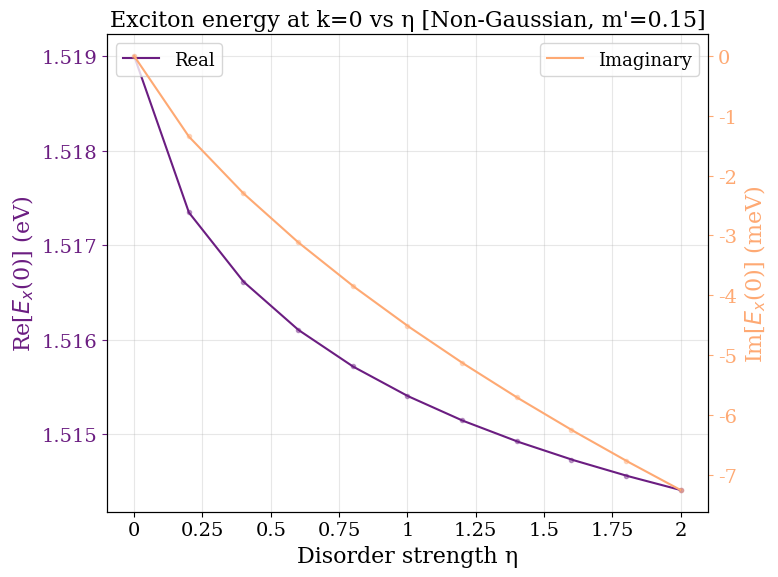

Saved  Plots/xi20nm_mprime0p15/Eex_k0_vs_eta_xi20nm_mprime0p15.png


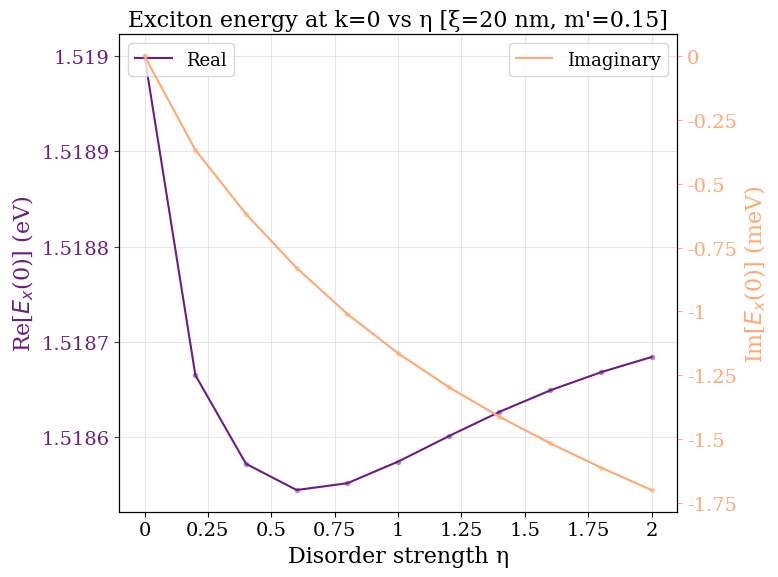

In [10]:
EEX_K0_ETA_DENSE_POINTS = 400  # dense eta sampling for a smooth interpolant

for plot_context in plot_contexts:
	apply_context(plot_context)
	# Sample at the saved eta grid (markers) and at a dense interpolated
	# eta grid (smooth line).  DispersionModel performs piecewise-linear
	# blending between eta slices internally; the dense grid simply hides
	# the kinks at slice boundaries when those boundaries are coarse.
	E_ex_k0_grid  = np.array([model.E_ex(np.array([0.0]), eta)[0] for eta in eta_grid])
	eta_dense     = np.linspace(float(eta_grid.min()), float(eta_grid.max()), EEX_K0_ETA_DENSE_POINTS)
	E_ex_k0_dense = np.array([model.E_ex(np.array([0.0]), float(eta))[0] for eta in eta_dense])
	E_real_eV       = energy_nat_to_eV(np.real(E_ex_k0_dense), p_nat) + plot_context["E_offset_eV"]
	E_imag_meV      = energy_nat_to_meV(np.imag(E_ex_k0_dense), p_nat)
	E_real_eV_grid  = energy_nat_to_eV(np.real(E_ex_k0_grid),  p_nat) + plot_context["E_offset_eV"]
	E_imag_meV_grid = energy_nat_to_meV(np.imag(E_ex_k0_grid),  p_nat)

	fig, ax = plt.subplots(figsize=(8, 6))
	ax_r = ax.twinx()

	real_color = CMAP(0.32)
	imag_color = CMAP(0.82)
	ax.plot(eta_dense, E_real_eV, color=real_color, label="Real")
	ax.plot(eta_grid, E_real_eV_grid, "o", color=real_color, ms=3, alpha=0.4)
	ax_r.plot(eta_dense, E_imag_meV, color=imag_color, label="Imaginary")
	ax_r.plot(eta_grid, E_imag_meV_grid, "o", color=imag_color, ms=3, alpha=0.4)

	ax.set_xlabel("Disorder strength η")
	ax.set_ylabel(r"Re[$E_x$(0)] (eV)", color=real_color)
	ax_r.set_ylabel(r"Im[$E_x$(0)] (meV)", color=imag_color)
	ax.tick_params(axis='y', colors=real_color)
	ax_r.tick_params(axis='y', colors=imag_color)
	ax.set_title(f"Exciton energy at k=0 vs η [{result_label_text}]")
	format_plot_ticks(ax)
	hide_axis_offset(ax_r)
	format_plot_ticks(ax_r, axes="y", formatter="smart", decimals=3, zero_tol=0.0)
	ax.grid(alpha=0.3)
	ax.legend(loc="upper left"); ax_r.legend(loc="upper right")
	plt.tight_layout()
	save_figure(fig, f"Eex_k0_vs_eta_{result_slug_text}", meta=context_metadata(plot_context))
	plt.show()
	plt.close(fig)


## Dispersion relations

Exciton and photon dispersion for a selected disorder value, and full
exciton / LP dispersions for all η.


Saved  Plots/nongaussian_mprime0p15/dispersion_nongaussian_mprime0p15_disorder_tuned_cavity.png


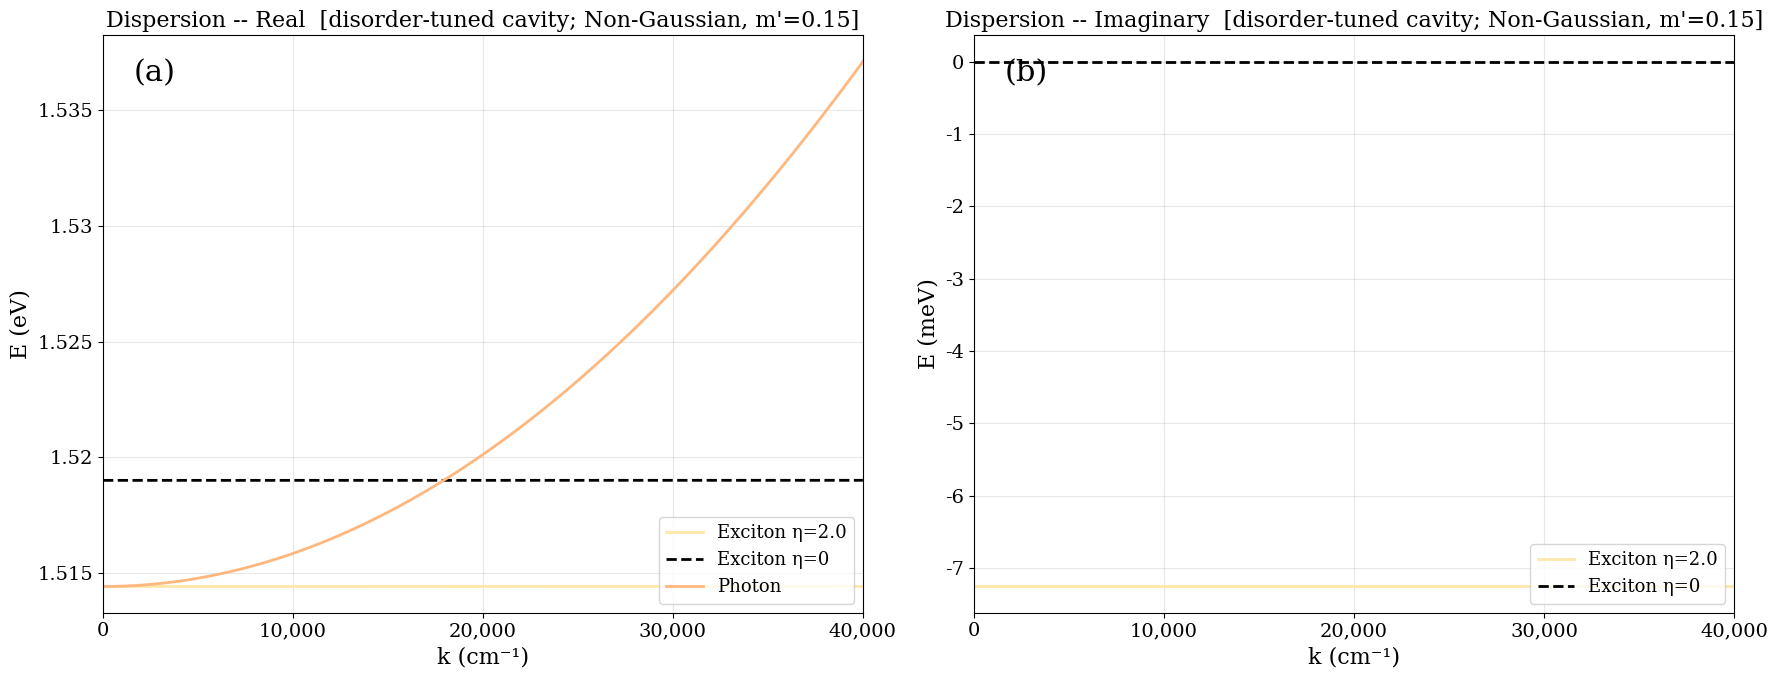

Saved  Plots/nongaussian_mprime0p15/dispersion_nongaussian_mprime0p15_disorder_free_cavity.png


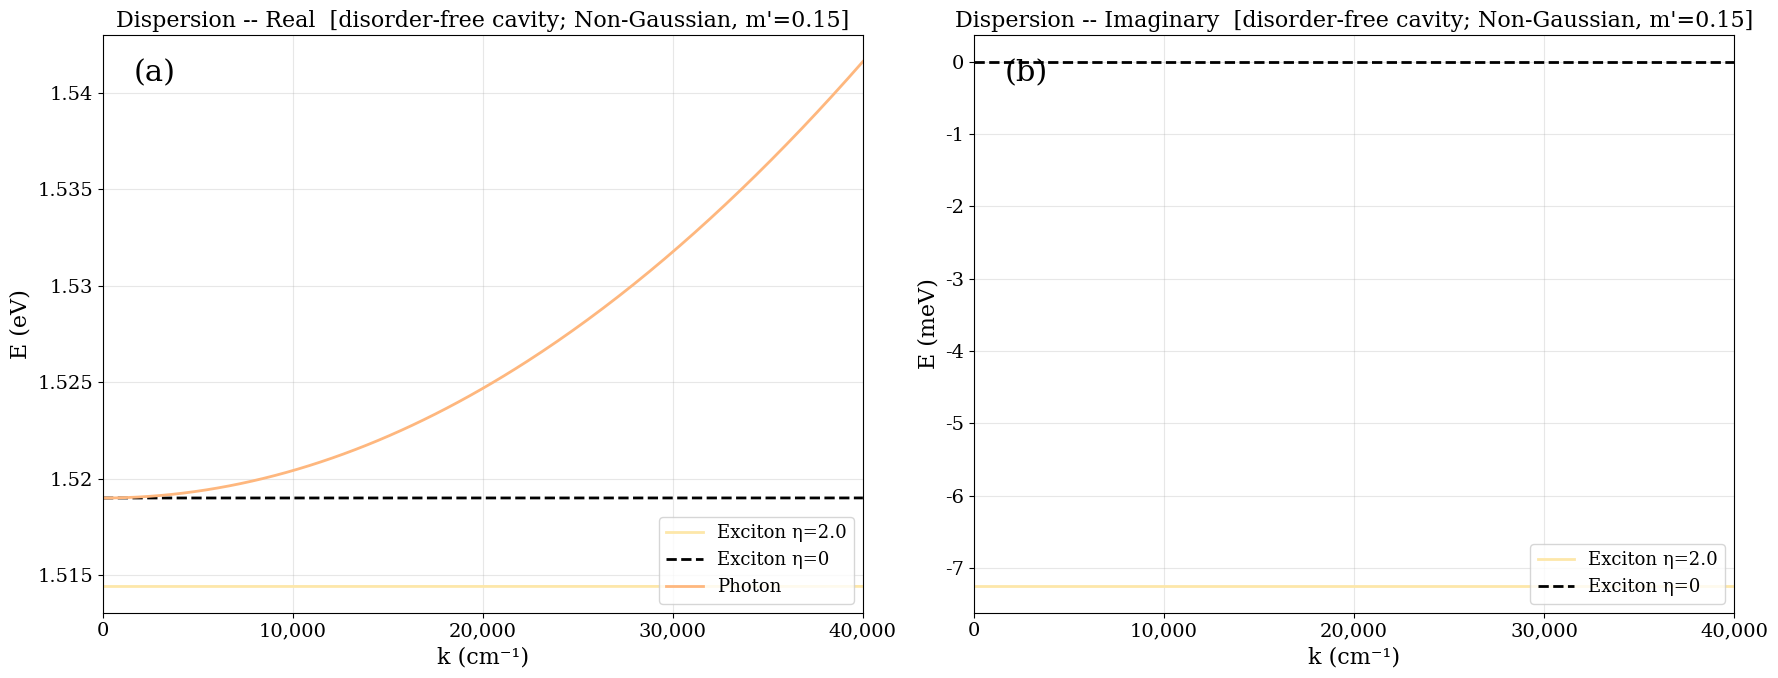

Saved  Plots/xi20nm_mprime0p15/dispersion_xi20nm_mprime0p15_disorder_tuned_cavity.png


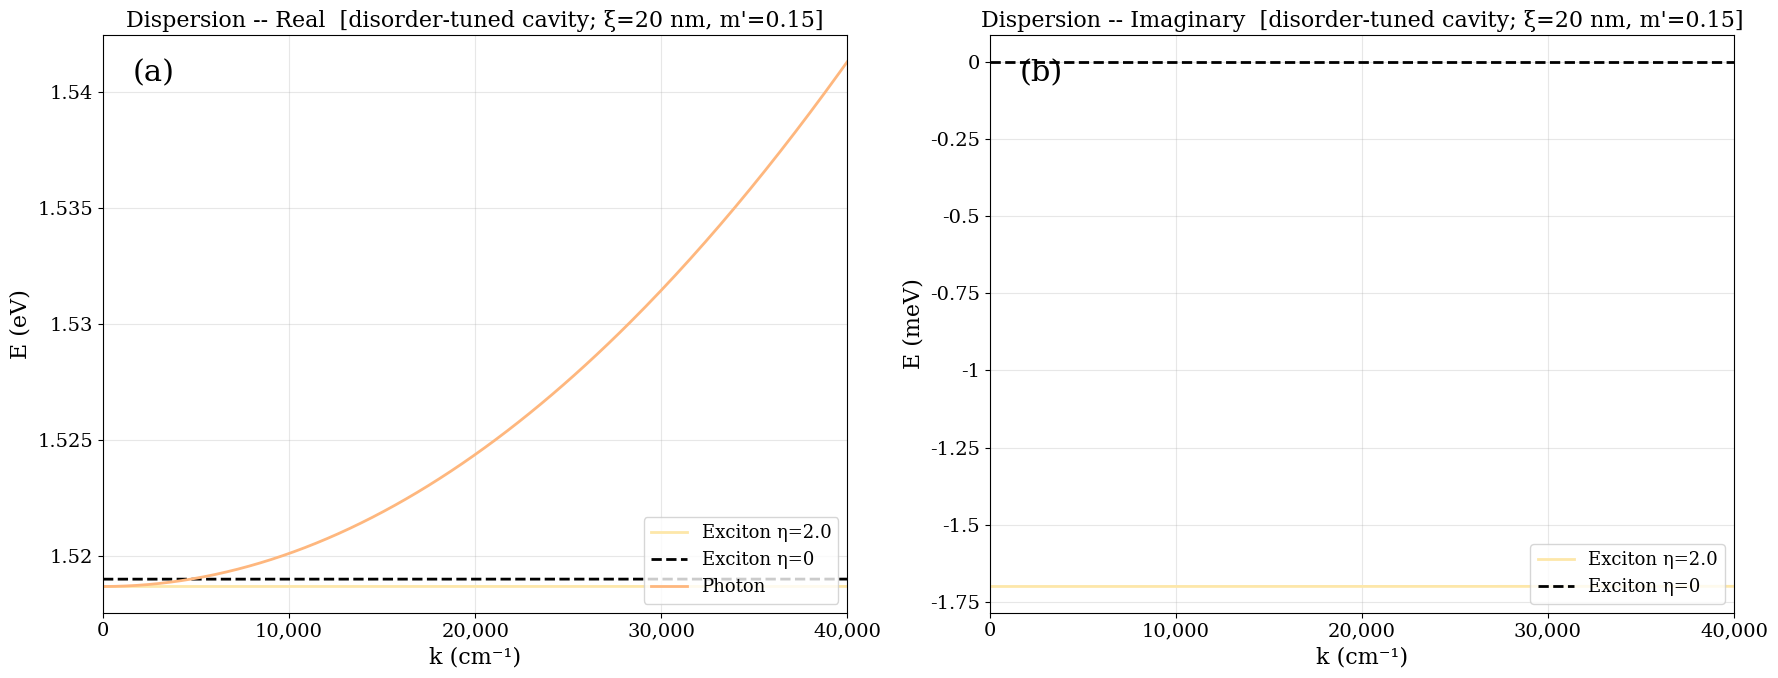

Saved  Plots/xi20nm_mprime0p15/dispersion_xi20nm_mprime0p15_disorder_free_cavity.png


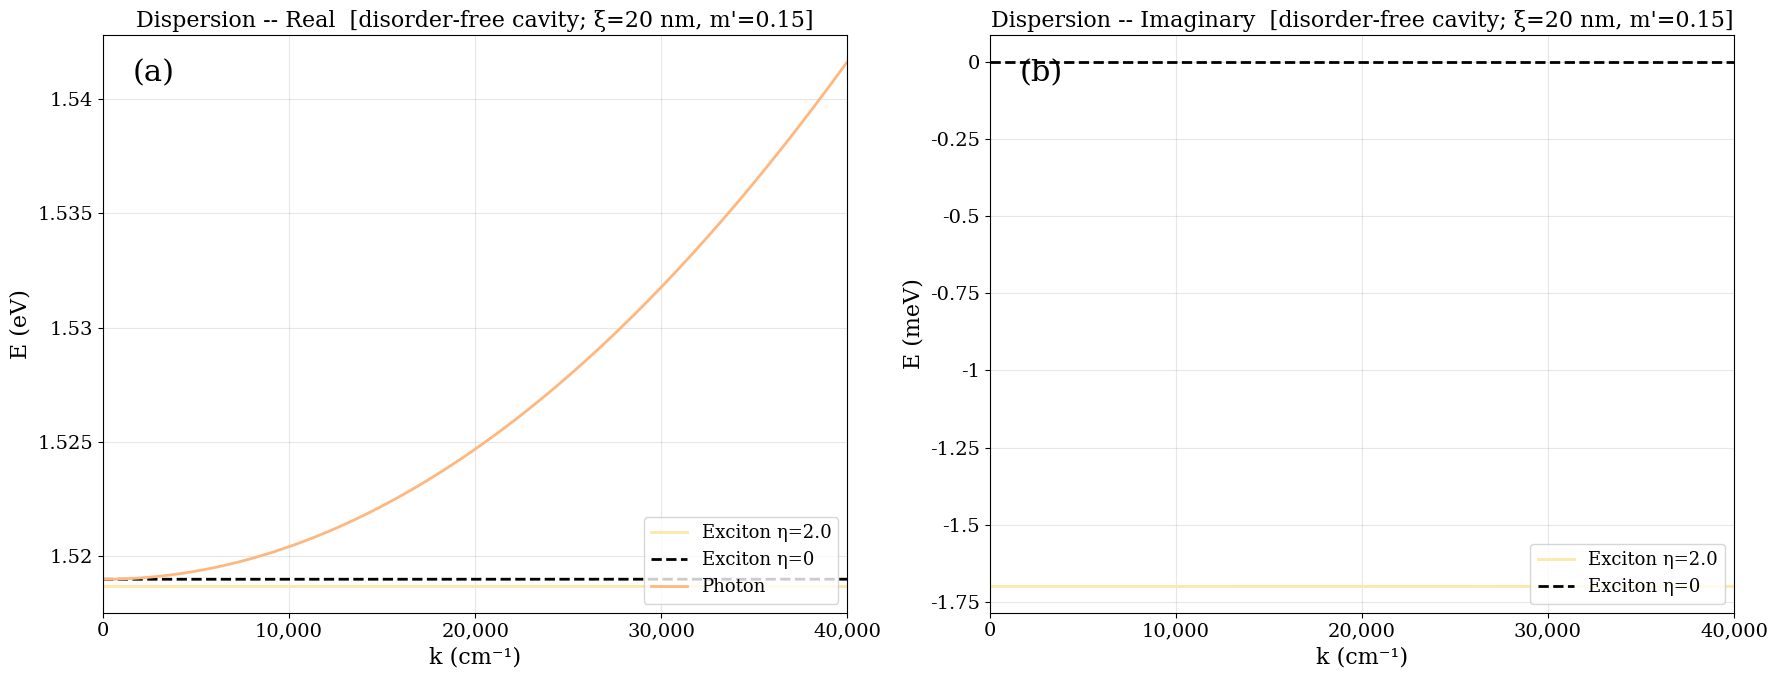

In [11]:
for plot_context in plot_contexts:
	apply_context(plot_context)
	eta_probe_idx = min(10, len(eta_grid) - 1)
	eta_probe = eta_grid[eta_probe_idx]
	k_cm = k_disp_cm

	E_ex_probe = model.E_ex(k_disp, eta_probe)
	E_ex_clean = model.E_ex(k_disp, 0.0)
	probe_color, probe_linestyle = eta_line_style(eta_probe_idx, float(eta_probe), linestyle="-")
	clean_color, clean_linestyle = eta_line_style(0, 0.0, linestyle="-")

	for tuned in (True, False):
		suffix = cavity_label(tuned)
		E_ph_use = model.E_ph(k_disp, eta_probe) if tuned else model.E_ph_untuned(k_disp)

		fig, axs = plt.subplots(1, 2, figsize=(18, 7))
		axs[0].plot(k_cm, energy_nat_to_eV(np.real(E_ex_probe), p_nat) + plot_context["E_offset_eV"], color=probe_color, linestyle=probe_linestyle, lw=2, label=f"Exciton η={eta_probe:.1f}")
		axs[0].plot(k_cm, energy_nat_to_eV(np.real(E_ex_clean), p_nat) + plot_context["E_offset_eV"], color=clean_color, linestyle=clean_linestyle, lw=2, label="Exciton η=0")
		axs[0].plot(k_cm, energy_nat_to_eV(np.real(E_ph_use), p_nat) + plot_context["E_offset_eV"], color=CMAP(0.85), lw=2, label="Photon")
		axs[1].plot(k_cm, energy_nat_to_meV(np.imag(E_ex_probe), p_nat), color=probe_color, linestyle=probe_linestyle, lw=2, label=f"Exciton η={eta_probe:.1f}")
		axs[1].plot(k_cm, energy_nat_to_meV(np.imag(E_ex_clean), p_nat), color=clean_color, linestyle=clean_linestyle, lw=2, label="Exciton η=0")

		for ax in axs:
			ax.set_xlabel(f"k ({CM_INV_LABEL})")
			ax.legend(loc="lower right")
			ax.grid(alpha=0.3)
			ax.set_xlim(0.0, 40_000.0)
			format_plot_ticks(ax, axes="x", ticks=[0, 10_000, 20_000, 30_000, 40_000])
			format_plot_ticks(ax, axes="y")
		axs[0].set_ylabel("E (eV)")
		axs[1].set_ylabel("E (meV)")
		format_plot_ticks(axs[1], axes="y", formatter="smart", decimals=3, zero_tol=0.0)
		axs[0].set_title(f"Dispersion -- Real  [{suffix}; {result_label_text}]")
		axs[1].set_title(f"Dispersion -- Imaginary  [{suffix}; {result_label_text}]")
		axs[0].text(0.04, 0.92, "(a)", transform=axs[0].transAxes, fontsize=22)
		axs[1].text(0.04, 0.92, "(b)", transform=axs[1].transAxes, fontsize=22)

		plt.tight_layout()
		save_figure(fig, f"dispersion_{result_slug_text}_{cavity_slug(tuned)}_cavity", meta={
			**context_metadata(plot_context),
			"eta_probe": float(eta_probe),
			"disorder_tuned": tuned,
		})
		plt.show()
		plt.close(fig)


## Lower polariton dispersion — all η


Saved  Plots/nongaussian_mprime0p15/LP_dispersion_nongaussian_mprime0p15_disorder_tuned.png


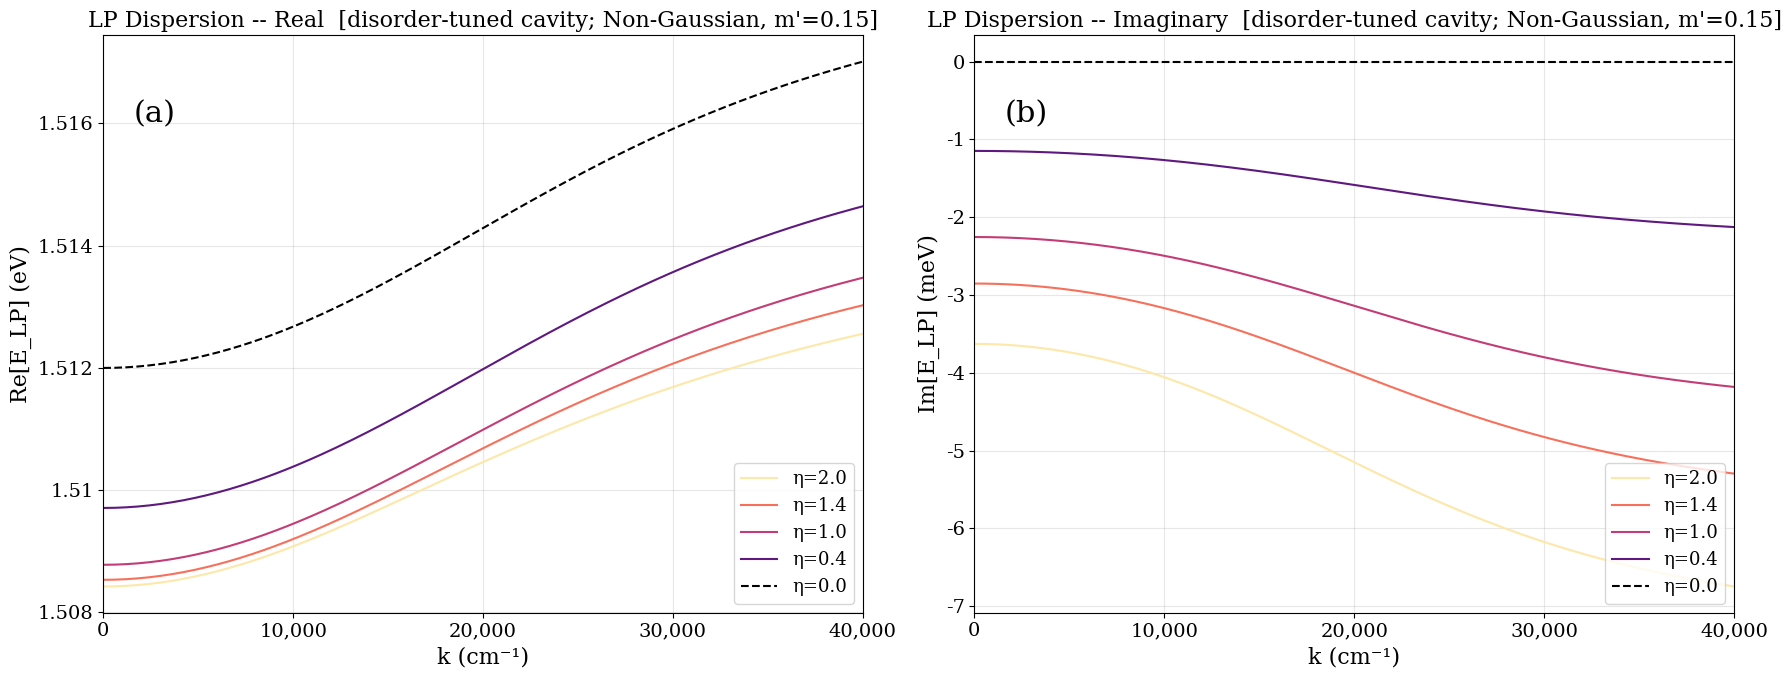

Saved  Plots/nongaussian_mprime0p15/LP_dispersion_nongaussian_mprime0p15_disorder_free.png


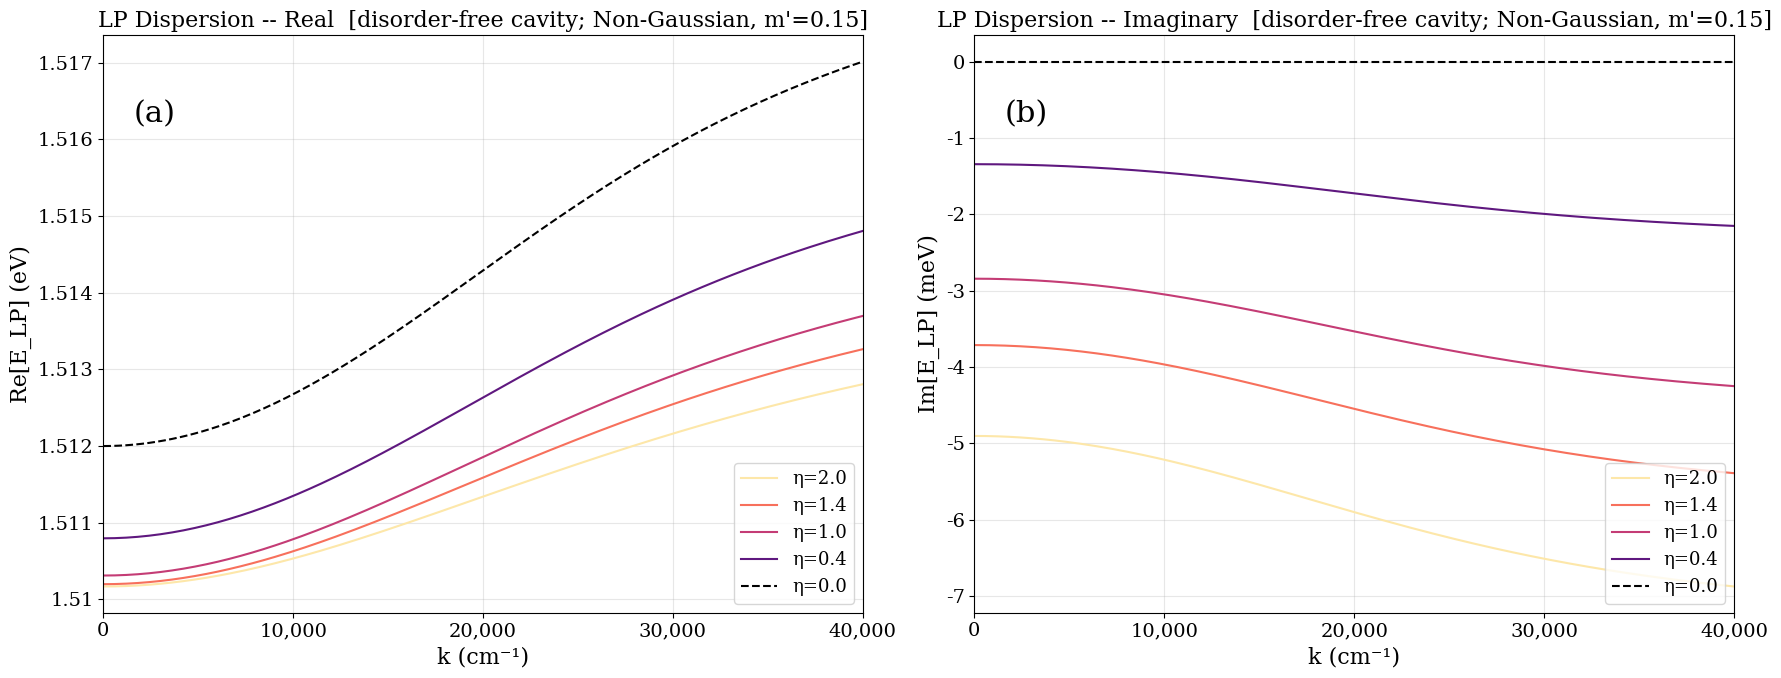

Saved  Plots/xi20nm_mprime0p15/LP_dispersion_xi20nm_mprime0p15_disorder_tuned.png


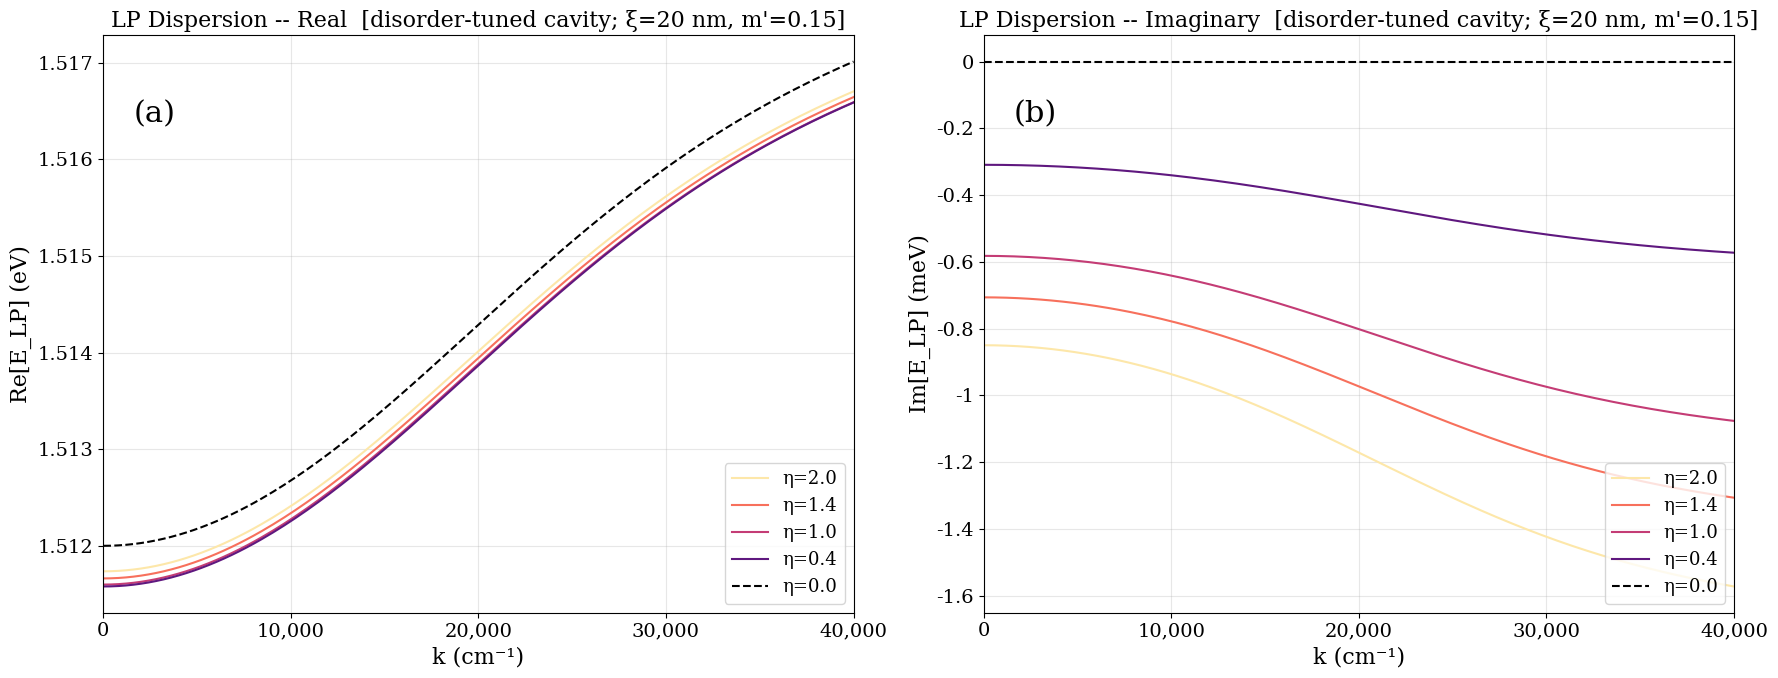

Saved  Plots/xi20nm_mprime0p15/LP_dispersion_xi20nm_mprime0p15_disorder_free.png


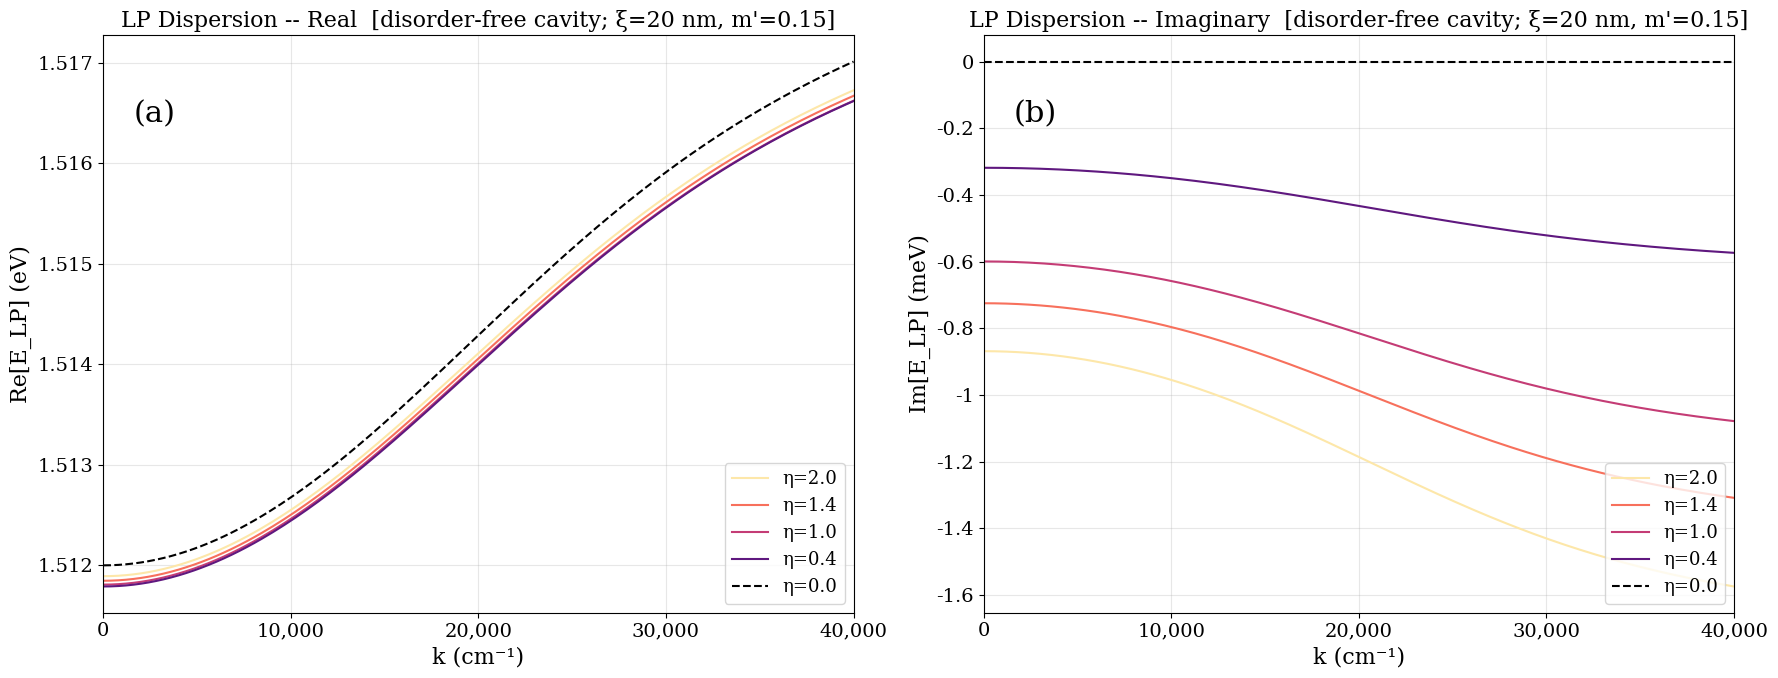

In [12]:
for plot_context in plot_contexts:
	apply_context(plot_context)
	for tuned in (True, False):
		label = cavity_label(tuned)
		fig, axs = plt.subplots(1, 2, figsize=(18, 7))
		for ei in selected_eta_indices():
			eta = float(eta_grid[ei])
			clr, linestyle = eta_line_style(ei, eta, linestyle="-")
			lbl = f"η={eta:.1f}"
			E_lp = model.E_LP(k_disp, eta, disorder_tuned=tuned)
			axs[0].plot(k_disp_cm, energy_nat_to_eV(np.real(E_lp), p_nat) + plot_context["E_offset_eV"], color=clr, linestyle=linestyle, label=lbl)
			axs[1].plot(k_disp_cm, energy_nat_to_meV(np.imag(E_lp), p_nat), color=clr, linestyle=linestyle, label=lbl)

		for ax in axs:
			ax.set_xlabel(f"k ({CM_INV_LABEL})")
			ax.legend(loc="lower right")
			ax.grid(alpha=0.3)
			ax.set_xlim(0.0, 40_000.0)
			format_plot_ticks(ax, axes="x", ticks=[0, 10_000, 20_000, 30_000, 40_000])
			format_plot_ticks(ax, axes="y")
		axs[0].set_ylabel("Re[E_LP] (eV)")
		axs[1].set_ylabel("Im[E_LP] (meV)")
		format_plot_ticks(axs[1], axes="y", formatter="smart", decimals=3, zero_tol=0.0)
		axs[0].set_title(f"LP Dispersion -- Real  [{label}; {result_label_text}]")
		axs[1].set_title(f"LP Dispersion -- Imaginary  [{label}; {result_label_text}]")
		axs[0].text(0.04, 0.85, "(a)", transform=axs[0].transAxes, fontsize=22)
		axs[1].text(0.04, 0.85, "(b)", transform=axs[1].transAxes, fontsize=22)

		plt.tight_layout()
		save_figure(fig, f"LP_dispersion_{result_slug_text}_{cavity_slug(tuned)}", meta={
			**context_metadata(plot_context),
			"disorder_tuned": tuned,
		})
		plt.show()
		plt.close(fig)


## Upper polariton dispersion — all η


Saved  Plots/nongaussian_mprime0p15/UP_dispersion_nongaussian_mprime0p15_disorder_tuned.png


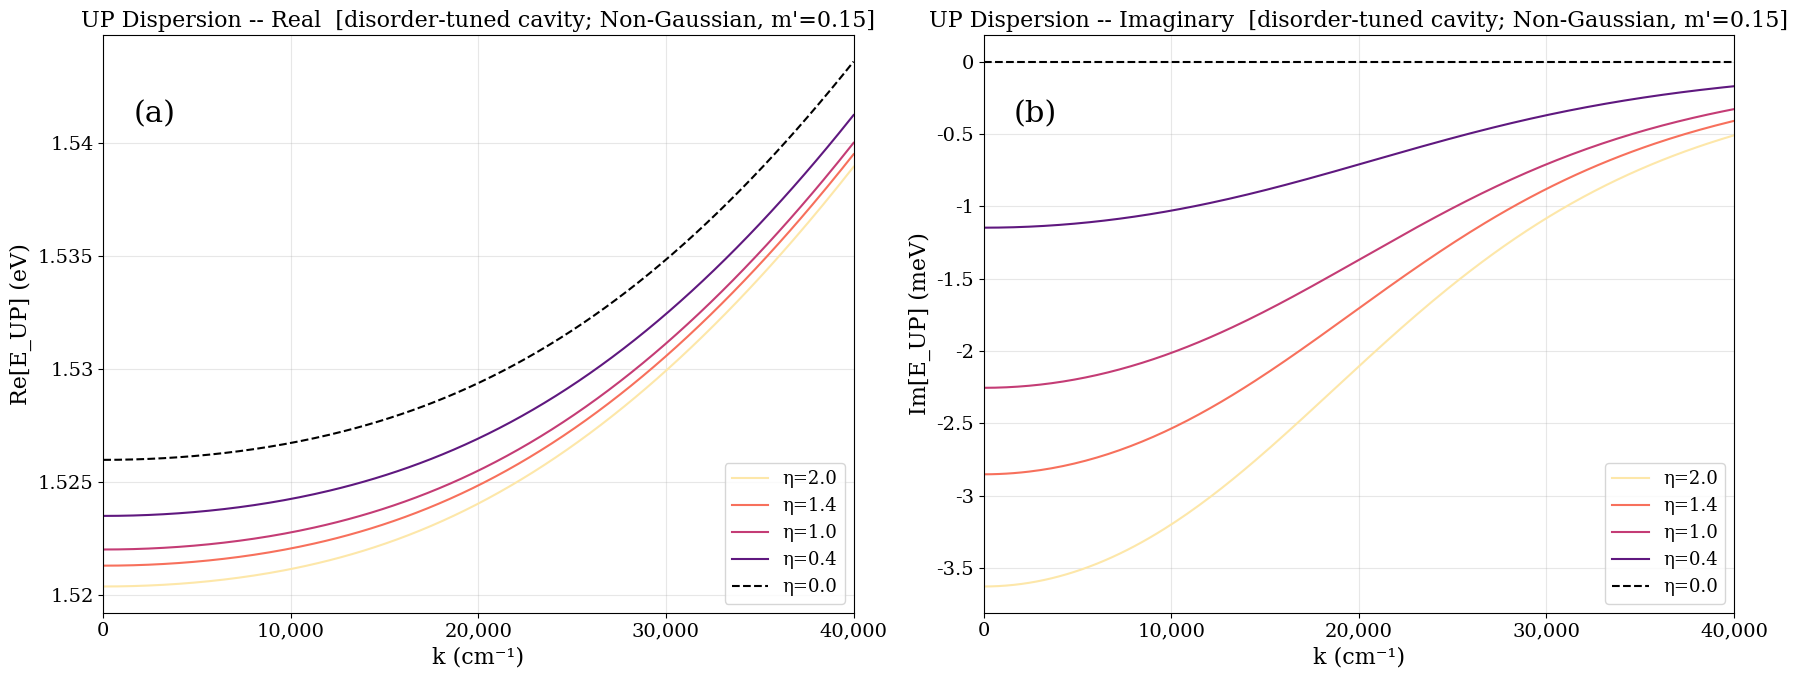

Saved  Plots/nongaussian_mprime0p15/UP_dispersion_nongaussian_mprime0p15_disorder_free.png


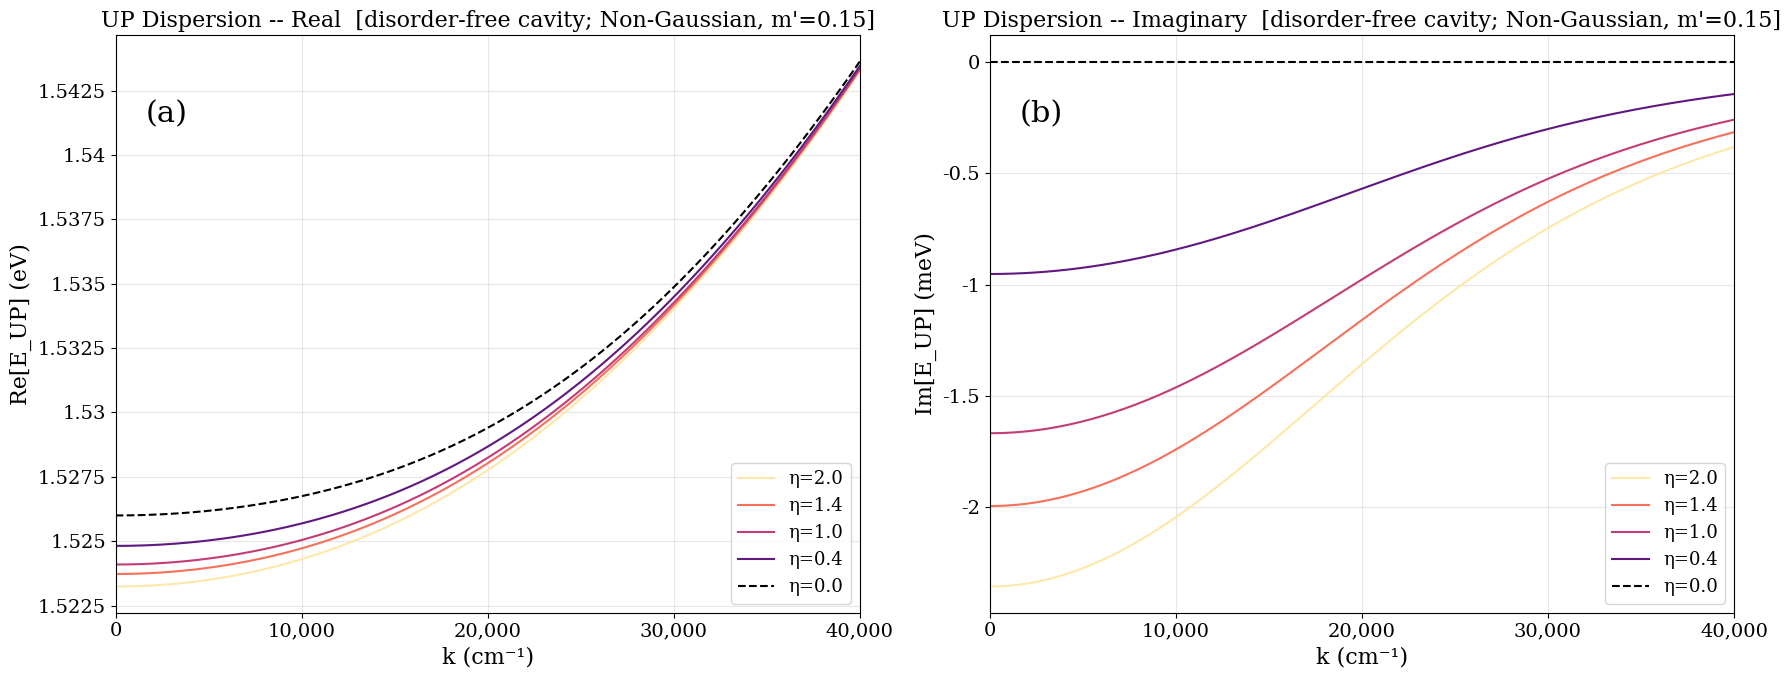

Saved  Plots/xi20nm_mprime0p15/UP_dispersion_xi20nm_mprime0p15_disorder_tuned.png


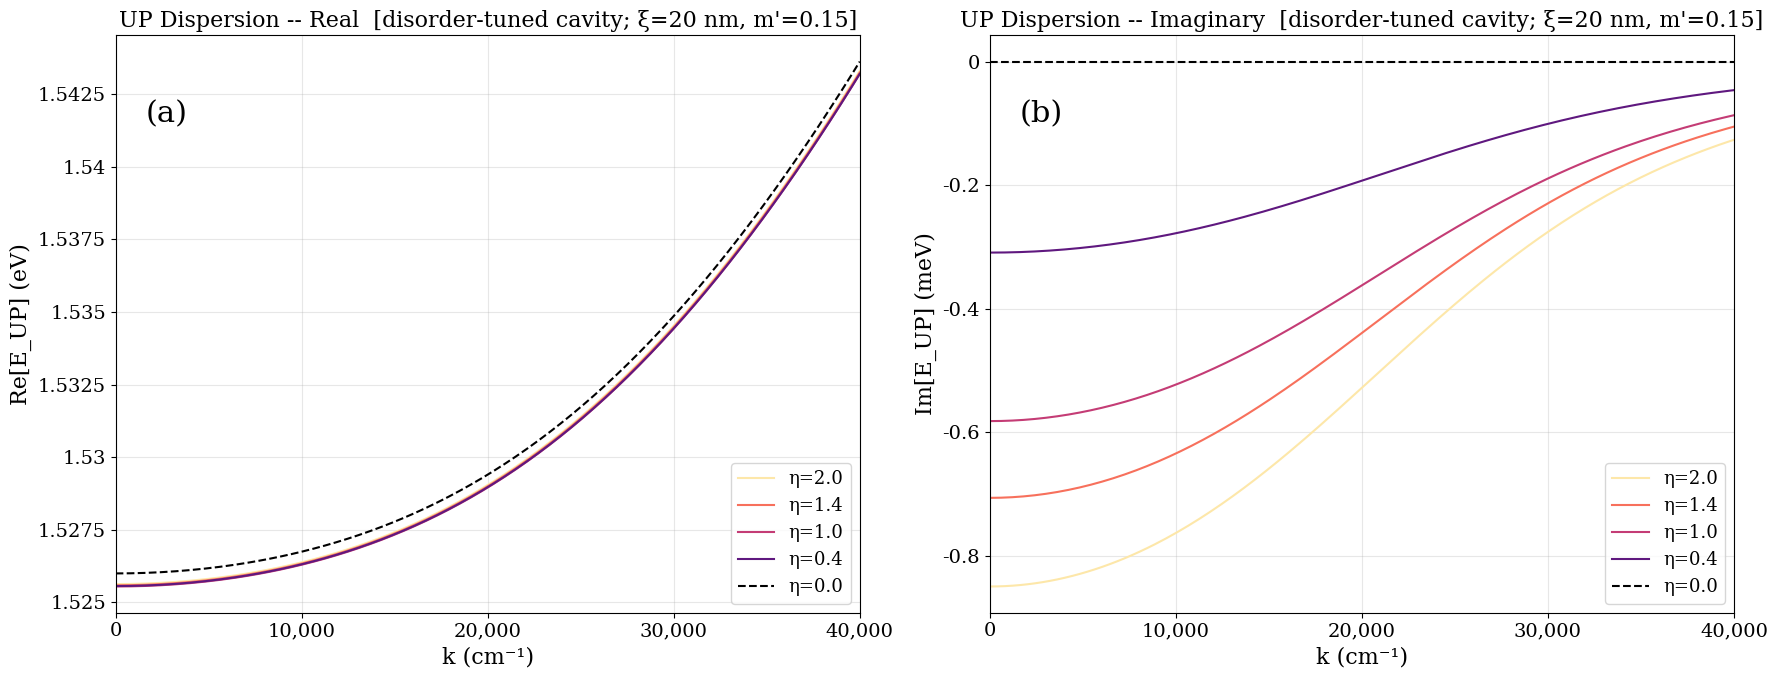

Saved  Plots/xi20nm_mprime0p15/UP_dispersion_xi20nm_mprime0p15_disorder_free.png


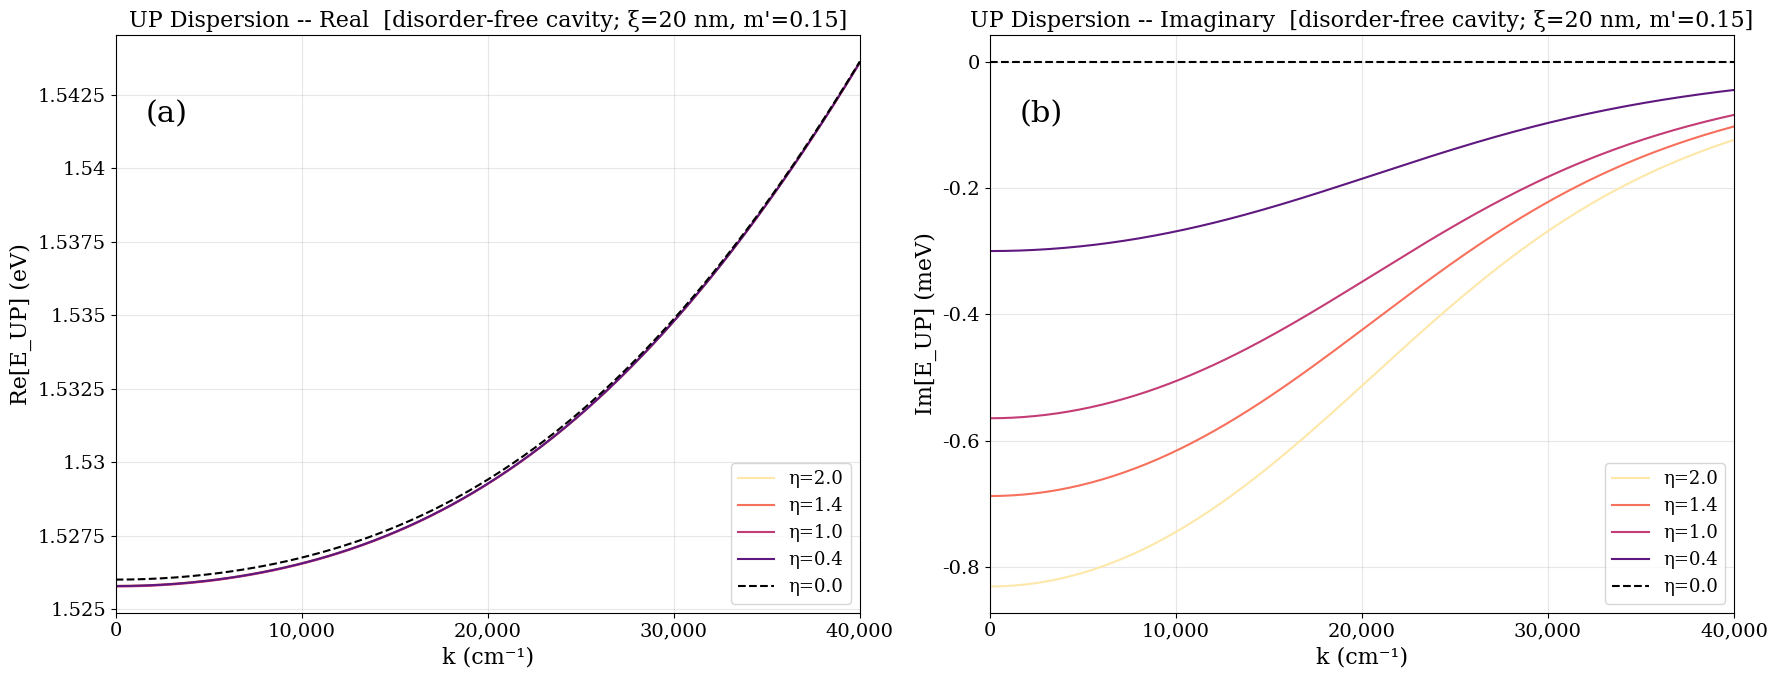

In [13]:
for plot_context in plot_contexts:
	apply_context(plot_context)
	for tuned in (True, False):
		label = cavity_label(tuned)
		fig, axs = plt.subplots(1, 2, figsize=(18, 7))
		for ei in selected_eta_indices():
			eta = float(eta_grid[ei])
			clr, linestyle = eta_line_style(ei, eta, linestyle="-")
			lbl = f"η={eta:.1f}"
			E_up = model.E_UP(k_disp, eta, disorder_tuned=tuned)
			axs[0].plot(k_disp_cm, energy_nat_to_eV(np.real(E_up), p_nat) + plot_context["E_offset_eV"], color=clr, linestyle=linestyle, label=lbl)
			axs[1].plot(k_disp_cm, energy_nat_to_meV(np.imag(E_up), p_nat), color=clr, linestyle=linestyle, label=lbl)

		for ax in axs:
			ax.set_xlabel(f"k ({CM_INV_LABEL})")
			ax.legend(loc="lower right")
			ax.grid(alpha=0.3)
			ax.set_xlim(0.0, 40_000.0)
			format_plot_ticks(ax, axes="x", ticks=[0, 10_000, 20_000, 30_000, 40_000])
			format_plot_ticks(ax, axes="y")
		axs[0].set_ylabel("Re[E_UP] (eV)")
		axs[1].set_ylabel("Im[E_UP] (meV)")
		format_plot_ticks(axs[1], axes="y", formatter="smart", decimals=3, zero_tol=0.0)
		axs[0].set_title(f"UP Dispersion -- Real  [{label}; {result_label_text}]")
		axs[1].set_title(f"UP Dispersion -- Imaginary  [{label}; {result_label_text}]")
		axs[0].text(0.04, 0.85, "(a)", transform=axs[0].transAxes, fontsize=22)
		axs[1].text(0.04, 0.85, "(b)", transform=axs[1].transAxes, fontsize=22)

		plt.tight_layout()
		save_figure(fig, f"UP_dispersion_{result_slug_text}_{cavity_slug(tuned)}", meta={
			**context_metadata(plot_context),
			"disorder_tuned": tuned,
		})
		plt.show()
		plt.close(fig)


## Combined exciton (dashed) & LP (solid) dispersion — narrow η

Side-by-side real / imaginary panels for a small set of η values, including η=0 in black.

Saved  Plots/nongaussian_mprime0p15/combined_dispersion_nongaussian_mprime0p15_disorder_tuned__cavity=disorder_tuned_etas=0p00_0p90_1p00_1p10.png


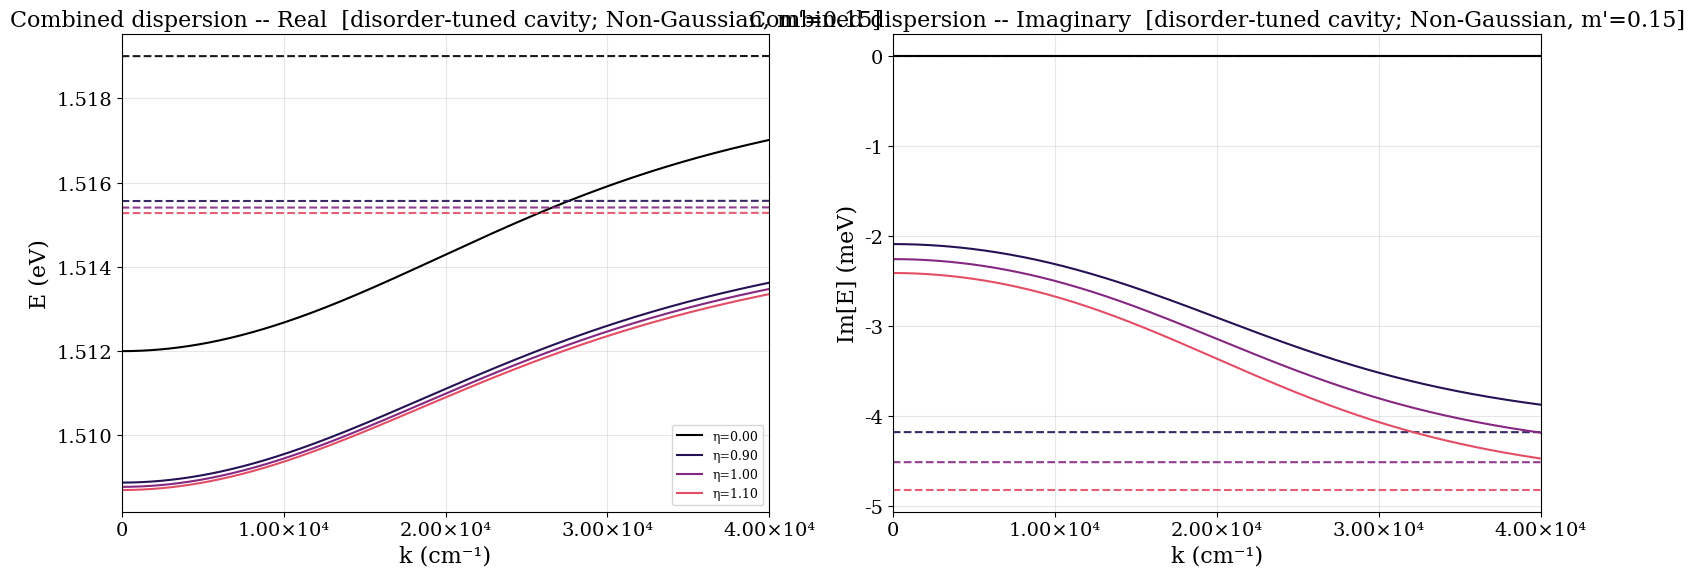

Saved  Plots/nongaussian_mprime0p15/combined_dispersion_nongaussian_mprime0p15_disorder_free__cavity=disorder_free_etas=0p00_0p90_1p00_1p10.png


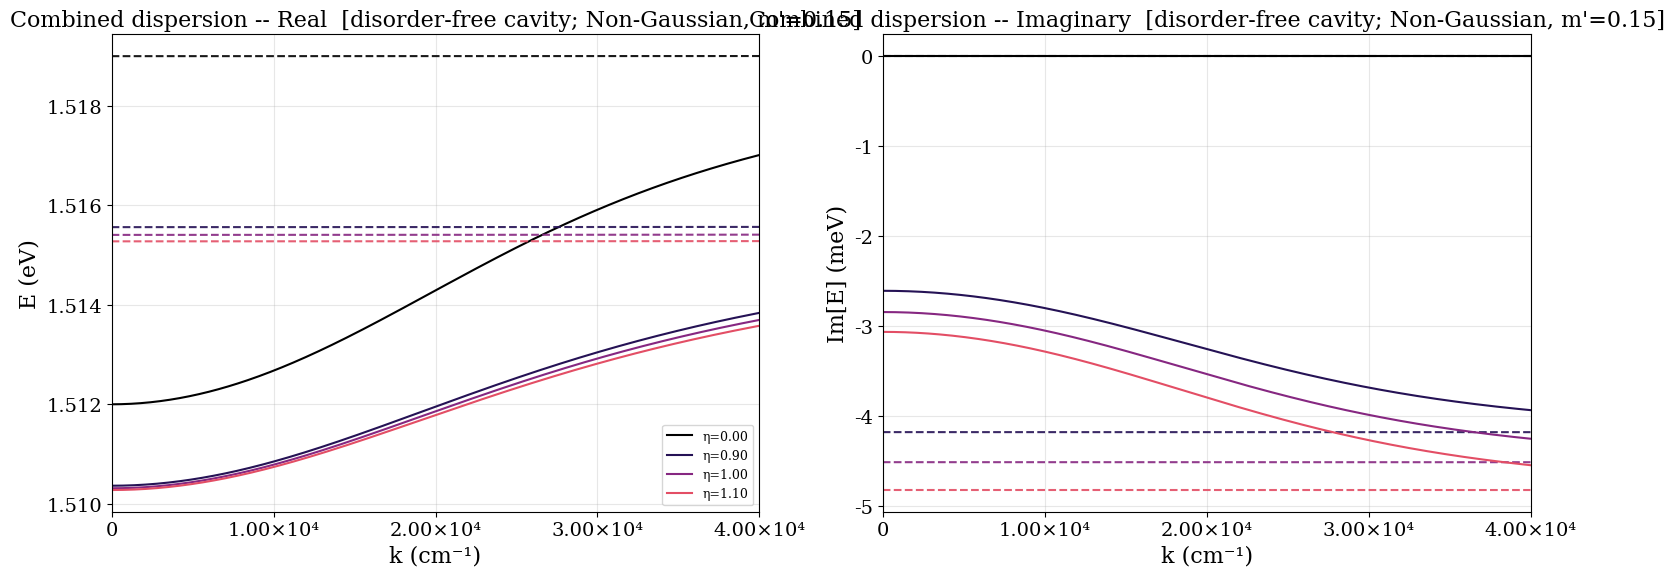

Saved  Plots/xi20nm_mprime0p15/combined_dispersion_xi20nm_mprime0p15_disorder_tuned__cavity=disorder_tuned_etas=0p00_0p90_1p00_1p10.png


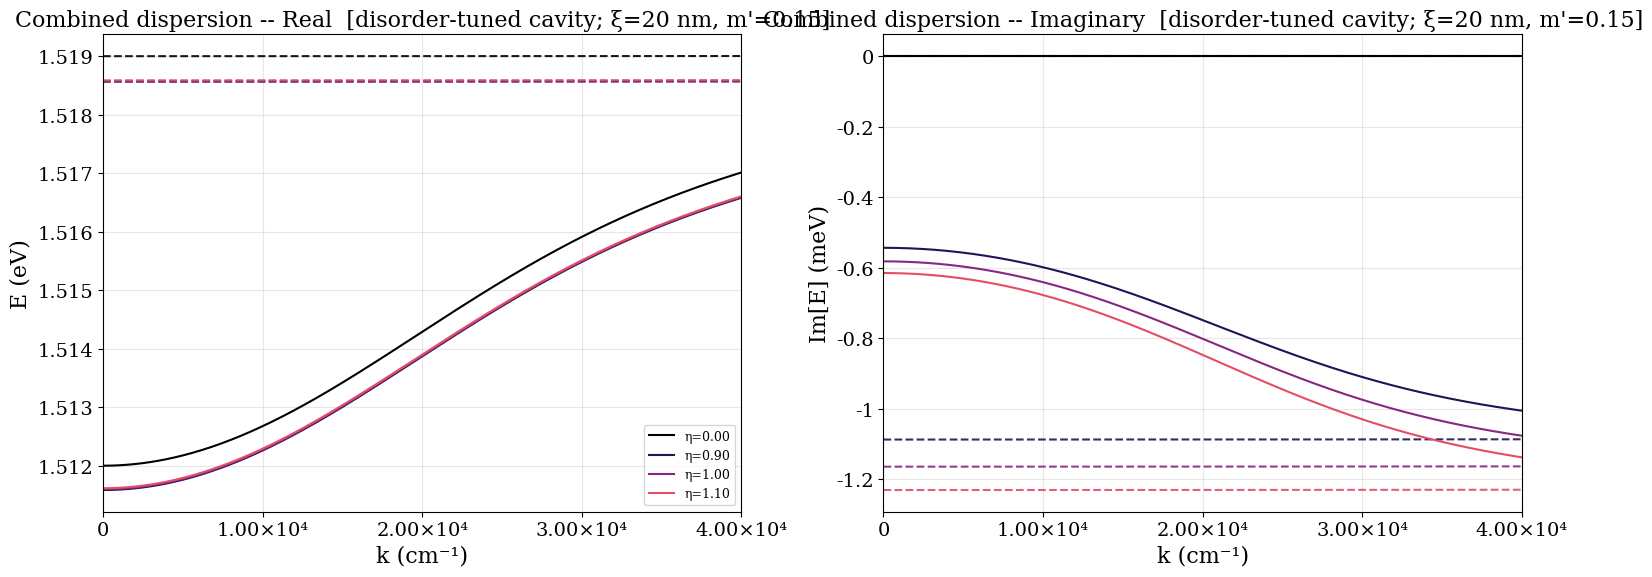

Saved  Plots/xi20nm_mprime0p15/combined_dispersion_xi20nm_mprime0p15_disorder_free__cavity=disorder_free_etas=0p00_0p90_1p00_1p10.png


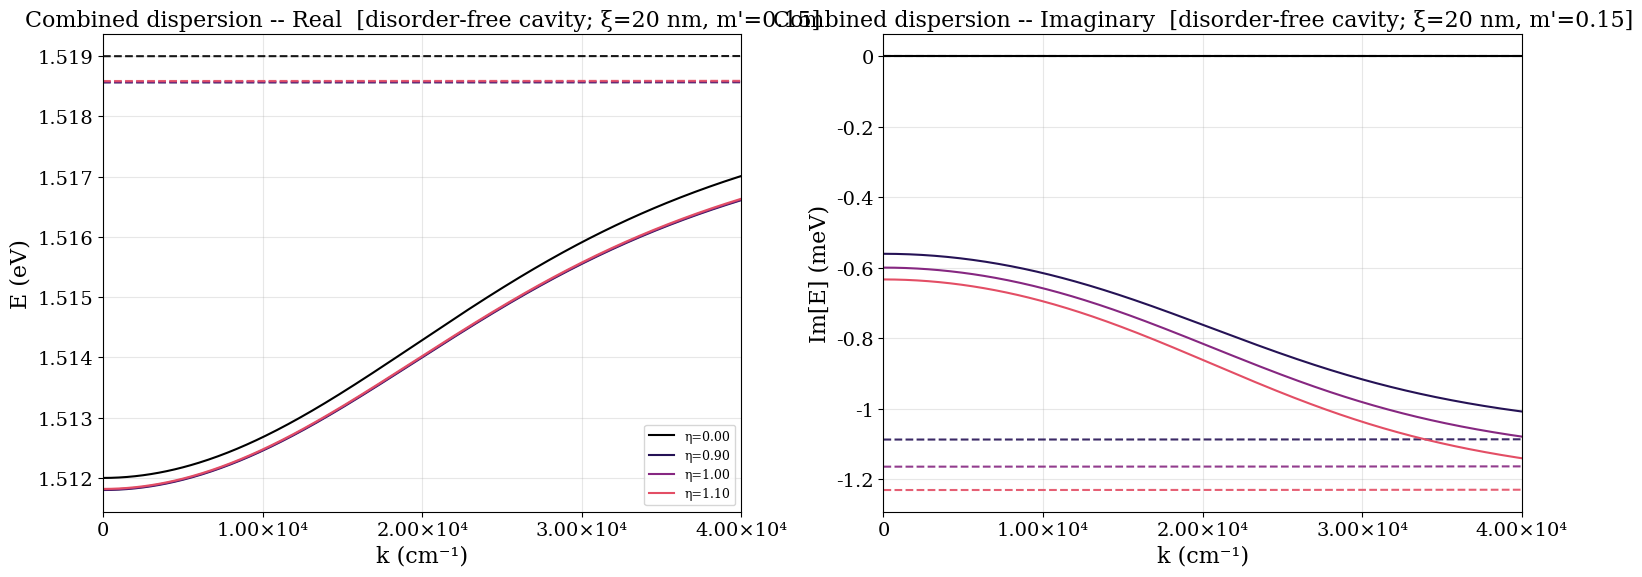

In [14]:
# Combined exciton (dashed) and LP (solid) dispersion for a narrow set of eta values.
# eta=0 is drawn in black; remaining etas use the magma colormap.
COMBINED_DISPERSION_ETAS = (0.0, 0.9, 1.0, 1.1)
COMBINED_DISP_K_UPPER_CM = 40_000.0
COMBINED_DISP_N_K = 401

import matplotlib as _mpl

def _combined_eta_colors(etas):
    n = len(etas)
    nonzero = [i for i, e in enumerate(etas) if not np.isclose(e, 0.0, atol=1e-12)]
    cmap = _mpl.cm.get_cmap("magma")
    colors = [None] * n
    for j, i in enumerate(nonzero):
        frac = 0.15 + (0.7 * (j / max(n - 1, 1)))
        colors[i] = cmap(frac)
    for i, e in enumerate(etas):
        if np.isclose(e, 0.0, atol=1e-12):
            colors[i] = (0.0, 0.0, 0.0, 1.0)
    return colors

for plot_context in plot_contexts:
    apply_context(plot_context)
    model = DispersionModel(p_nat, q_picard, eta_grid, Q_results)
    etas = tuple(float(e) for e in COMBINED_DISPERSION_ETAS)
    colors = _combined_eta_colors(etas)
    k_disp_cm = np.linspace(0.0, COMBINED_DISP_K_UPPER_CM, COMBINED_DISP_N_K)
    k_disp = k_cm_to_nat(k_disp_cm, p_nat)

    for tuned in (True, False):
        fig, axs = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
        offset_eV = plot_context["E_offset_eV"]
        for eta_value, clr in zip(etas, colors):
            E_ex = model.E_ex(k_disp, eta_value)
            E_lp = model.E_LP(k_disp, eta_value, disorder_tuned=tuned)
            label = f"η={eta_value:.2f}"
            re_ex = energy_nat_to_eV(np.real(E_ex), p_nat) + offset_eV
            re_lp = energy_nat_to_eV(np.real(E_lp), p_nat) + offset_eV
            im_ex = energy_nat_to_meV(np.imag(E_ex), p_nat)
            im_lp = energy_nat_to_meV(np.imag(E_lp), p_nat)
            axs[0].plot(k_disp_cm, re_ex, color=clr, linestyle="--", alpha=0.9)
            axs[0].plot(k_disp_cm, re_lp, color=clr, linestyle="-",  label=label)
            axs[1].plot(k_disp_cm, im_ex, color=clr, linestyle="--", alpha=0.9)
            axs[1].plot(k_disp_cm, im_lp, color=clr, linestyle="-",  label=label)

        for ax in axs:
            ax.set_xlabel(f"k ({CM_INV_LABEL})")
            ax.set_xlim(0.0, COMBINED_DISP_K_UPPER_CM)
            ax.grid(alpha=0.3)
            format_plot_ticks(ax, axes="x", ticks=[0, 10_000, 20_000, 30_000, 40_000])
        axs[0].set_ylabel("E (eV)")
        axs[1].set_ylabel("Im[E] (meV)")
        format_plot_ticks(axs[1], axes="y", formatter="smart", decimals=3, zero_tol=0.0)
        axs[0].set_title(f"Combined dispersion -- Real  [{cavity_label(tuned)}; {result_label_text}]")
        axs[1].set_title(f"Combined dispersion -- Imaginary  [{cavity_label(tuned)}; {result_label_text}]")
        axs[0].legend(loc="lower right", fontsize=9)
        plt.tight_layout()
        etas_token = "_".join(f"{e:.2f}".replace(".", "p") for e in etas)
        save_figure(
            fig,
            f"combined_dispersion_{result_slug_text}_{cavity_slug(tuned)}",
            meta={
                **context_metadata(plot_context),
                "disorder_tuned": tuned,
                "etas": list(etas),
                "k_upper_cm_inv": COMBINED_DISP_K_UPPER_CM,
                "n_k": COMBINED_DISP_N_K,
            },
            file_meta_suffix={"cavity": cavity_slug(tuned), "etas": etas_token},
        )
        plt.show()
        plt.close(fig)


## Hopfield coefficients


Saved  Plots/nongaussian_mprime0p15/hopfield_coefficients_nongaussian_mprime0p15_disorder_tuned.png


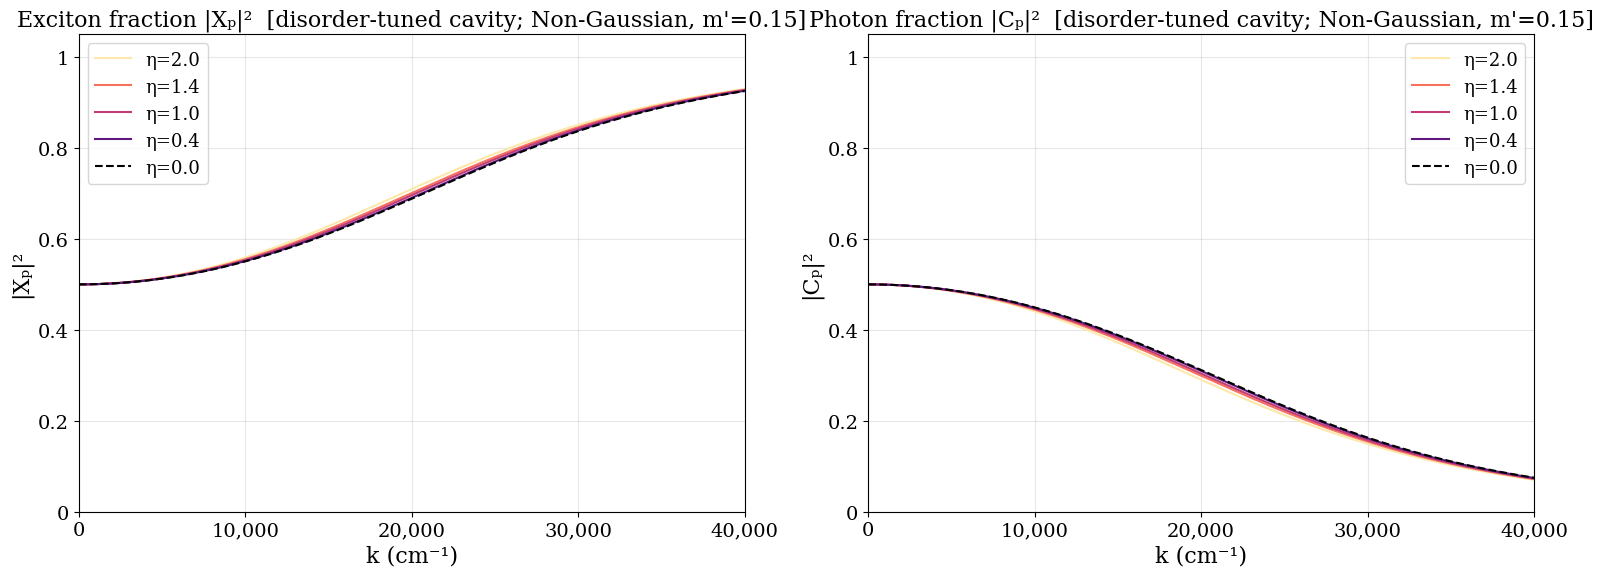

Saved  Plots/nongaussian_mprime0p15/hopfield_coefficients_nongaussian_mprime0p15_disorder_free.png


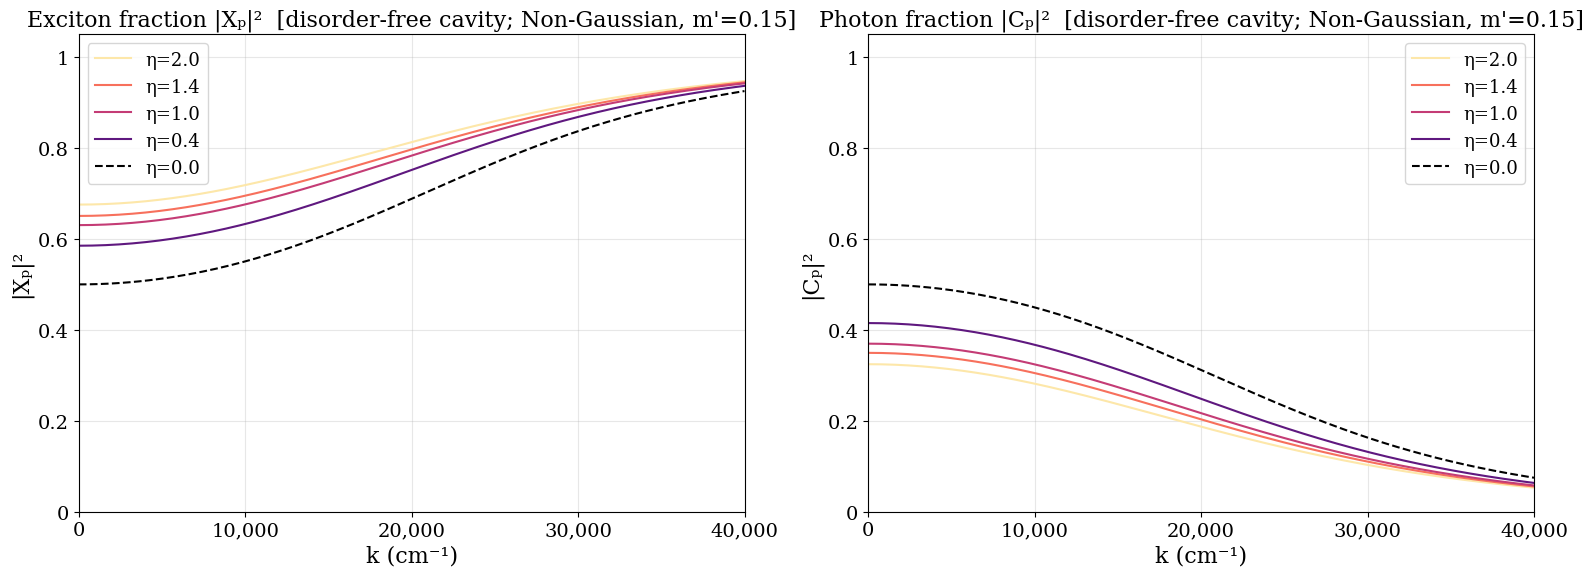

Saved  Plots/xi20nm_mprime0p15/hopfield_coefficients_xi20nm_mprime0p15_disorder_tuned.png


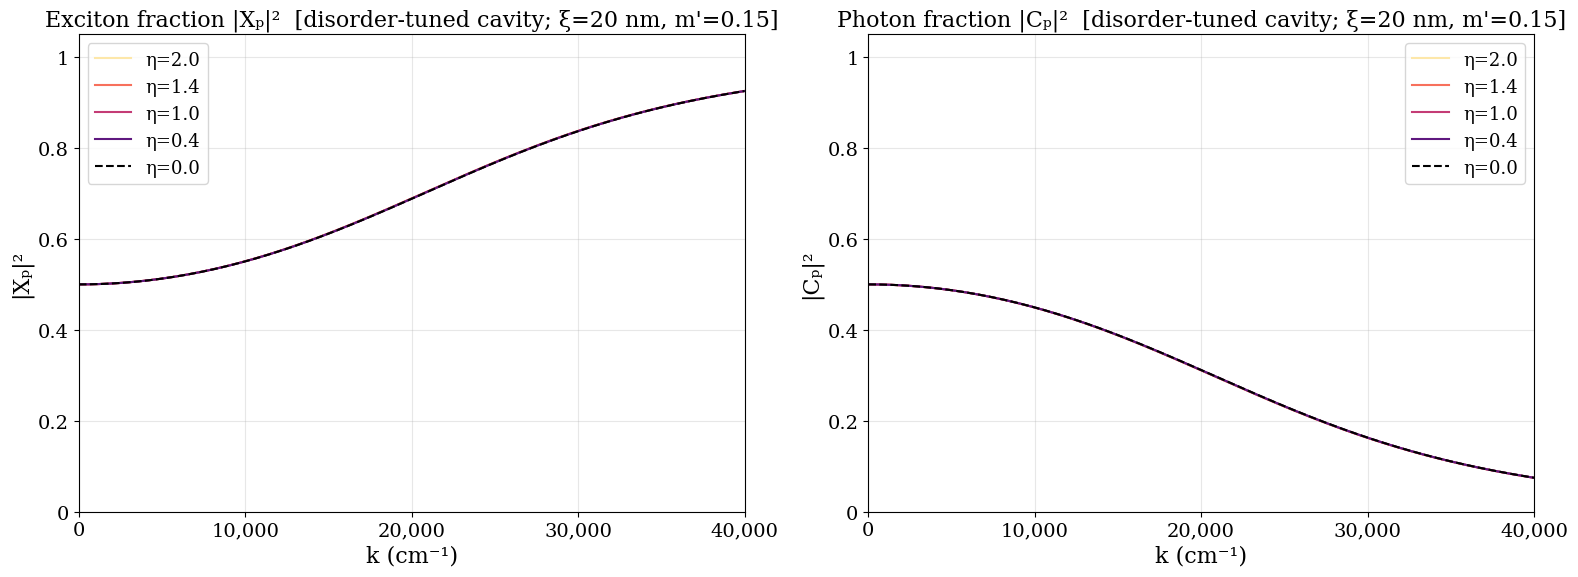

Saved  Plots/xi20nm_mprime0p15/hopfield_coefficients_xi20nm_mprime0p15_disorder_free.png


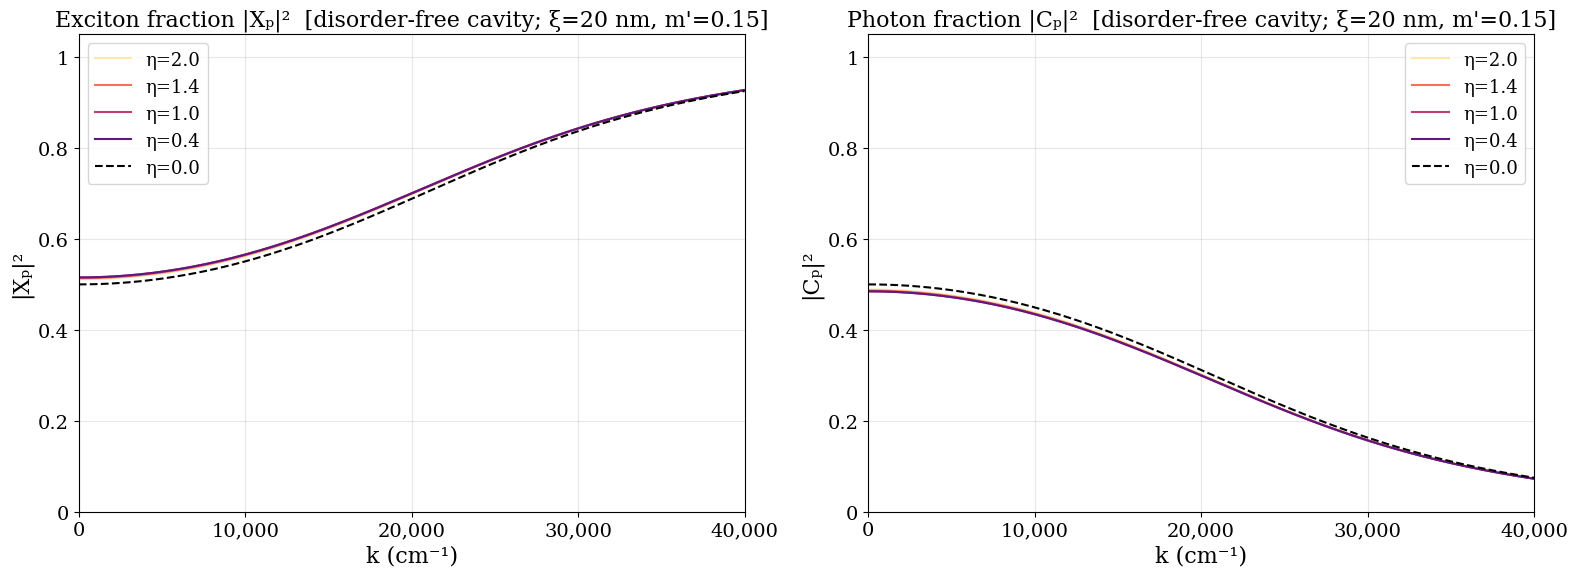

In [15]:
for plot_context in plot_contexts:
	apply_context(plot_context)
	for tuned in (True, False):
		fig, axs = plt.subplots(1, 2, figsize=(16, 6))
		for ei in selected_eta_indices():
			eta_value = float(eta_grid[ei])
			clr, linestyle = eta_line_style(ei, eta_value, linestyle="-")
			X_LP, C_LP = hopfield_coefficients(model, eta_value, k_disp, disorder_tuned=tuned)
			axs[0].plot(k_disp_cm, np.abs(X_LP)**2, color=clr, linestyle=linestyle, label=f"η={eta_value:.1f}")
			axs[1].plot(k_disp_cm, np.abs(C_LP)**2, color=clr, linestyle=linestyle, label=f"η={eta_value:.1f}")

		for ax, title, y_label in zip(
			axs,
			["Exciton fraction |Xₚ|²", "Photon fraction |Cₚ|²"],
			["|Xₚ|²", "|Cₚ|²"],
		):
			ax.set_xlabel(f"k ({CM_INV_LABEL})")
			ax.set_ylabel(y_label)
			ax.set_title(f"{title}  [{cavity_label(tuned)}; {result_label_text}]")
			ax.set_xlim(0.0, 40_000.0)
			ax.set_ylim(0, 1.05)
			ax.legend()
			ax.grid(alpha=0.3)
			format_plot_ticks(ax, axes="x", ticks=[0, 10_000, 20_000, 30_000, 40_000])
			format_plot_ticks(ax, axes="y")

		plt.tight_layout()
		save_figure(fig, f"hopfield_coefficients_{result_slug_text}_{cavity_slug(tuned)}", meta={
			**context_metadata(plot_context),
			"disorder_tuned": tuned,
		})
		plt.show()
		plt.close(fig)


## Detuning Δ(k, η) = E_ph − E_ex


Saved  Plots/nongaussian_mprime0p15/detuning_nongaussian_mprime0p15_disorder_tuned.png


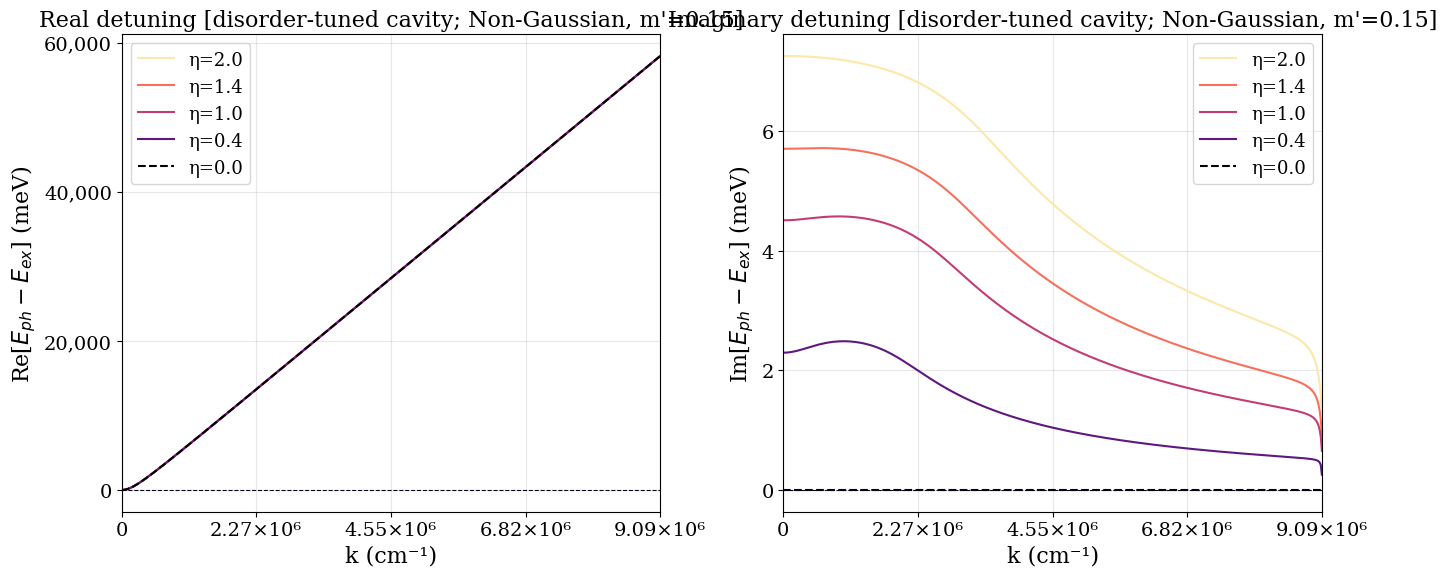

Saved  Plots/nongaussian_mprime0p15/detuning_nongaussian_mprime0p15_disorder_free.png


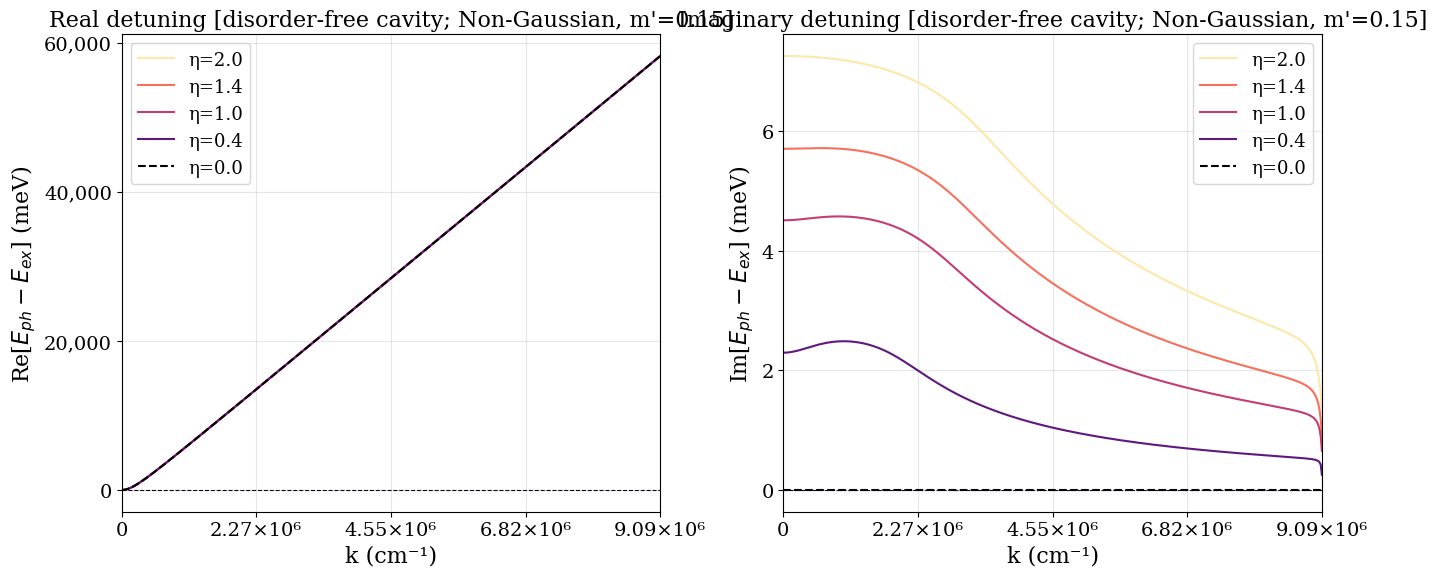

Saved  Plots/xi20nm_mprime0p15/detuning_xi20nm_mprime0p15_disorder_tuned.png


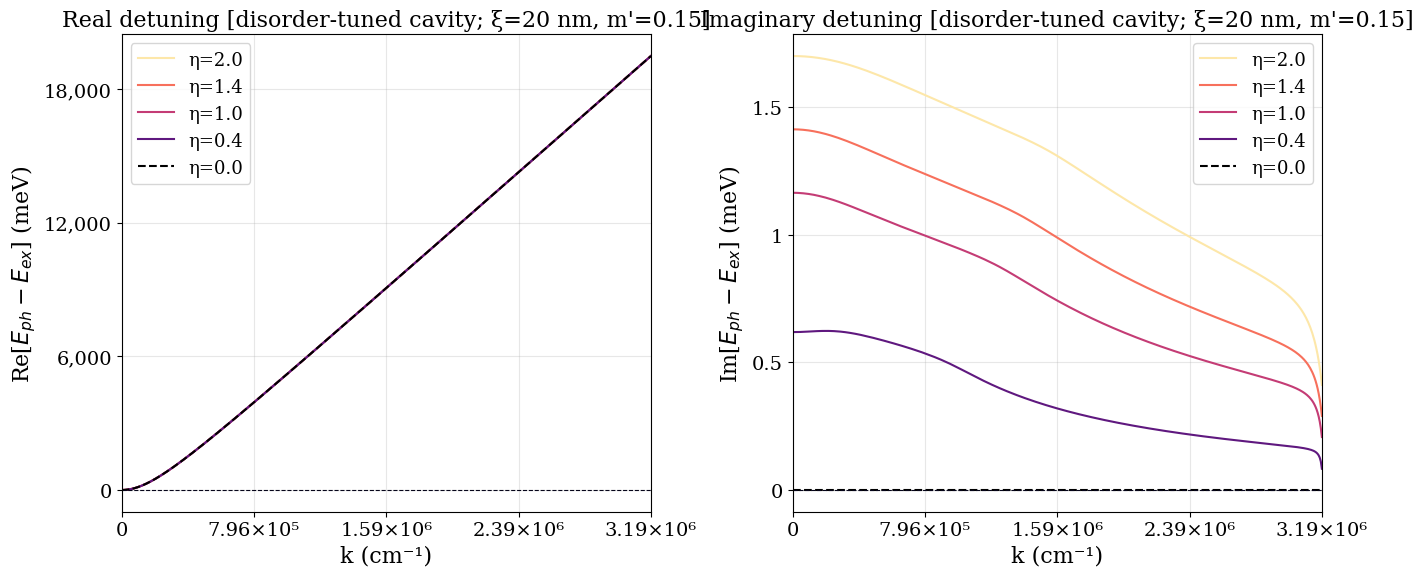

Saved  Plots/xi20nm_mprime0p15/detuning_xi20nm_mprime0p15_disorder_free.png


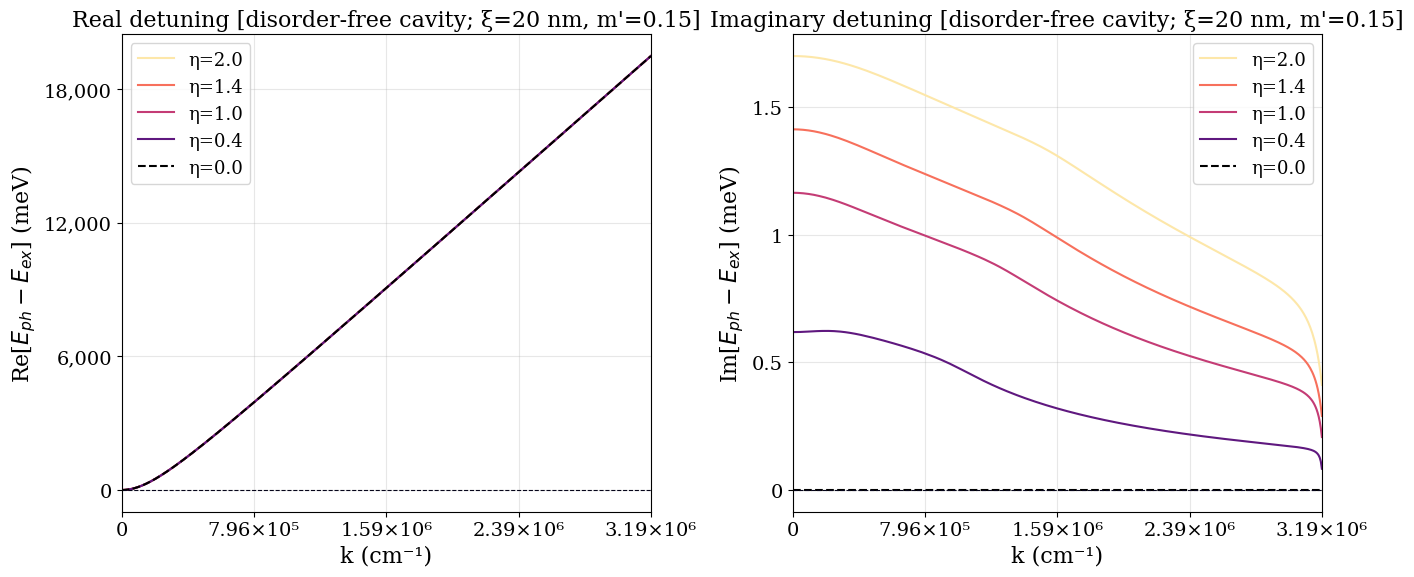

In [16]:
# Detuning x-range is dynamic per context: spans [0, t_cm].

for plot_context in plot_contexts:
	apply_context(plot_context)
	for tuned in (True, False):
		fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
		for ei in selected_eta_indices():
			eta = float(eta_grid[ei])
			clr, linestyle = eta_line_style(ei, eta, linestyle="-")
			lbl = f"η={eta:.1f}"
			E_ph = model.E_ph(k_wide, eta) if tuned else model.E_ph_untuned(k_wide)
			delta = E_ph - model.E_ex(k_wide, eta)
			ax1.plot(k_wide_cm, energy_nat_to_meV(np.real(delta), p_nat), color=clr, linestyle=linestyle, label=lbl)
			ax2.plot(k_wide_cm, energy_nat_to_meV(np.imag(delta), p_nat), color=clr, linestyle=linestyle, label=lbl)

		for ax in (ax1, ax2):
			ax.axhline(0, color=CMAP(0.05), lw=0.8, ls='--')
			ax.set_xlabel(f"k ({CM_INV_LABEL})")
			ax.legend()
			ax.grid(alpha=0.3)
			ax.set_xlim(0.0, plot_context["t_cm"])
			format_plot_ticks(ax, axes="x", ticks=plot_context["dynamic_ticks_cm"], formatter="fixed_power", decimals=2)
			format_plot_ticks(ax, axes="y", nbins=4)

		ax1.set_ylabel(r"Re[$E_{ph}−E_{ex}$] (meV)")
		ax1.set_title(f"Real detuning [{cavity_label(tuned)}; {result_label_text}]")
		ax2.set_ylabel(r"Im[$E_{ph}−E_{ex}$] (meV)")
		ax2.set_title(f"Imaginary detuning [{cavity_label(tuned)}; {result_label_text}]")

		plt.tight_layout()
		save_figure(fig, f"detuning_{result_slug_text}_{cavity_slug(tuned)}", meta={
			**context_metadata(plot_context),
			"disorder_tuned": tuned,
			"k_max_cm_inv": plot_context["t_cm"],
		})
		plt.show()
		plt.close(fig)


## Polariton interaction strength vs k


/tmp/ipykernel_474212/192373116.py:228: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved  Plots/nongaussian_mprime0p15/g_interactions_nongaussian_mprime0p15_disorder_tuned.png


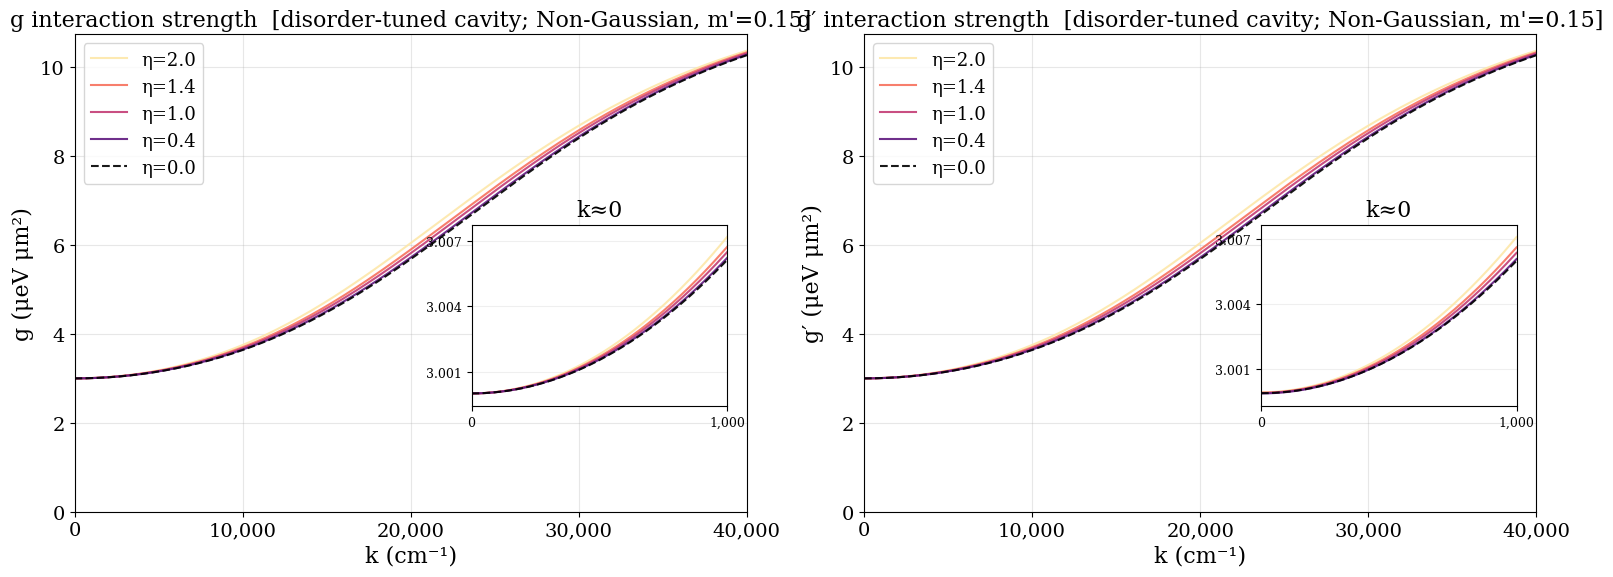

Saved  Plots/nongaussian_mprime0p15/g_interactions_nongaussian_mprime0p15_disorder_free.png


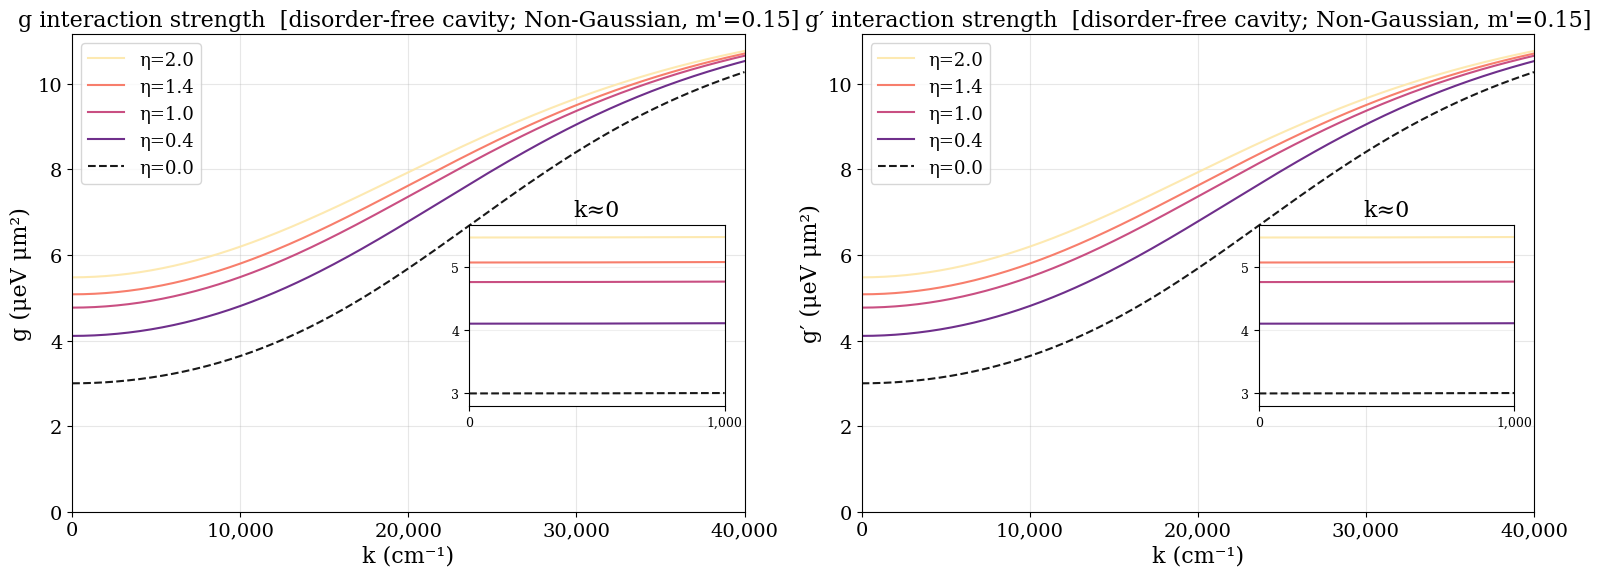

Saved  Plots/xi20nm_mprime0p15/g_interactions_xi20nm_mprime0p15_disorder_tuned.png


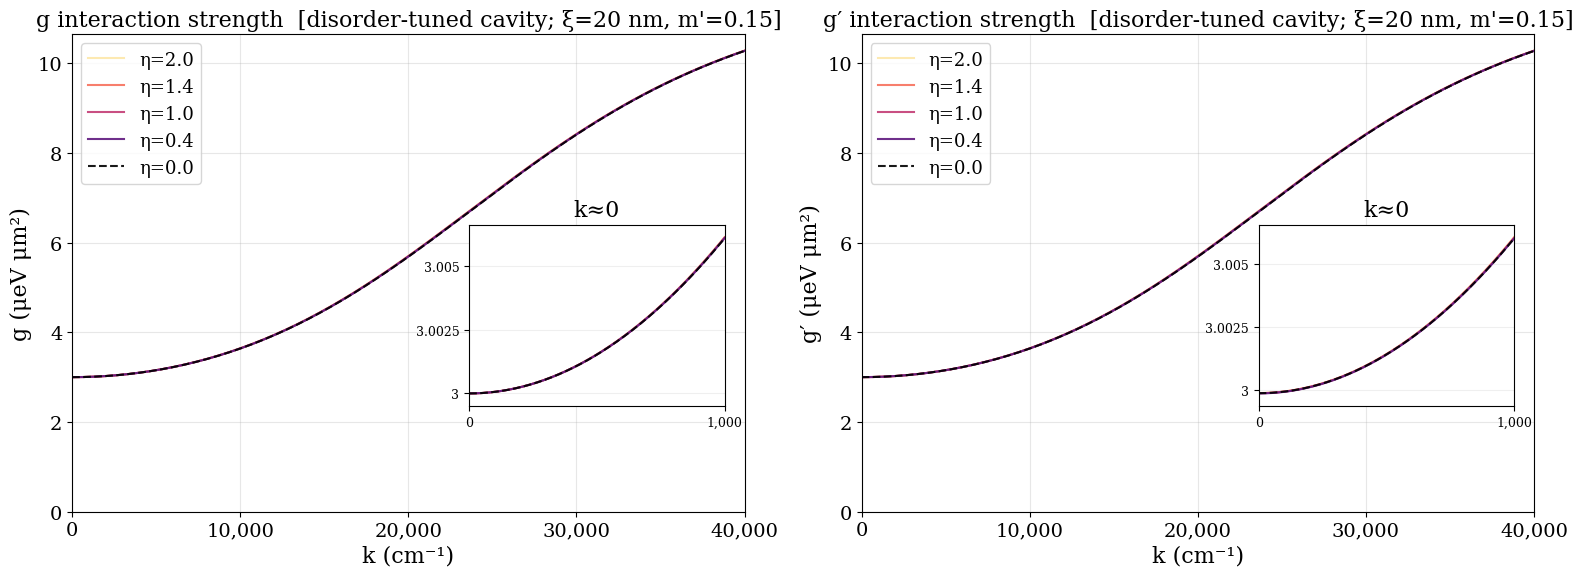

Saved  Plots/xi20nm_mprime0p15/g_interactions_xi20nm_mprime0p15_disorder_free.png


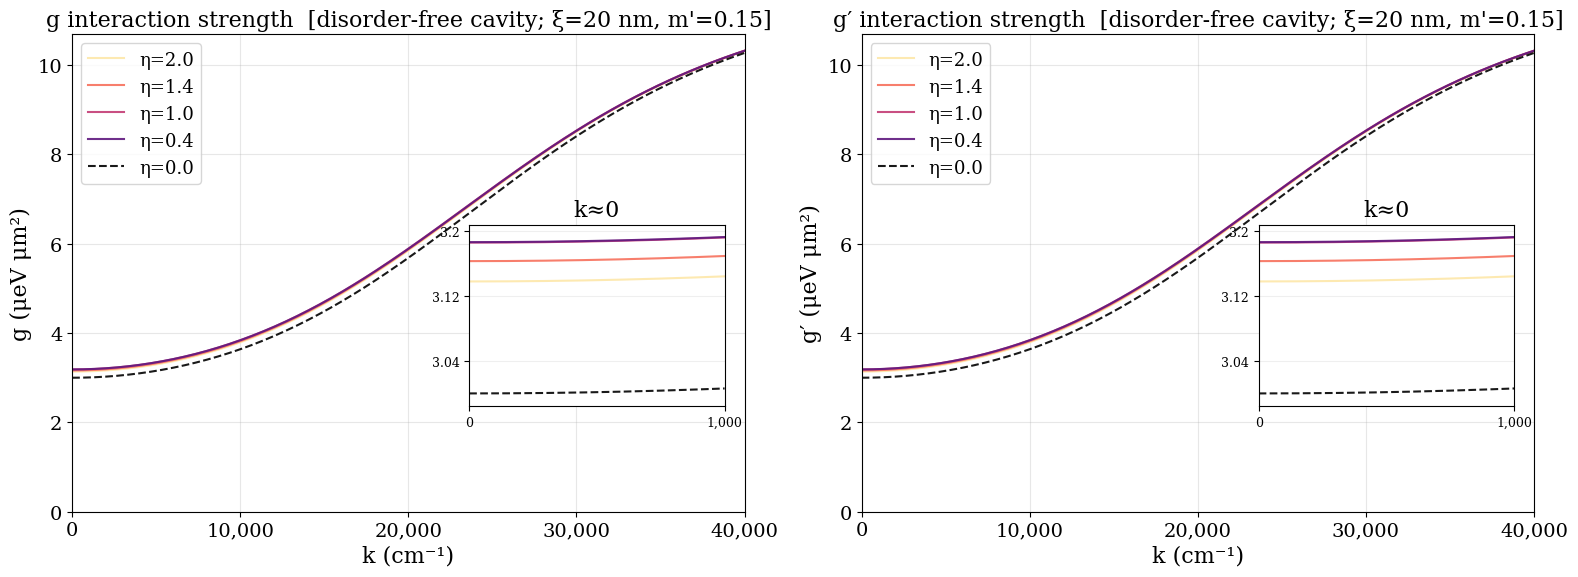

In [17]:
# Parameters for the many-body calculation
SIDE_BY_SIDE = True
L_TERMS = 100
K_UPPER = 1.0    # natural momentum for chemical-potential integration
N_K = 100_000
K_UPPER_MASS = 1e-3
N_K_MASS = 64
INTERACTION_RESULTS_DIR = Path("Results/interaction_strengths")
# Full-plot x-range is fixed at [0, INTERACTION_FULL_MAX_CM] cm^-1 for all contexts.
INTERACTION_FULL_MAX_CM  = 40_000.0
INTERACTION_INSET_MAX_CM = 1000.0
INTERACTION_INSET_POINTS = 500
INTERACTION_QUANTITY_AXIS = ["bare", "screened"]


INTERACTION_LOGX_MIN_CM = 100.0
INTERACTION_LOGX_MAX_CM = 200_000.0
INTERACTION_LOGX_POINTS = 400

def interaction_grid_cm_values(grid_role: str, ctx=None) -> np.ndarray:
	if grid_role == "full_plot":
		return np.linspace(0.0, INTERACTION_FULL_MAX_CM, 240)
	if grid_role == "dense_inset":
		return np.linspace(0.0, INTERACTION_INSET_MAX_CM, INTERACTION_INSET_POINTS)
	if grid_role == "logx_extended":
		return np.geomspace(INTERACTION_LOGX_MIN_CM, INTERACTION_LOGX_MAX_CM, INTERACTION_LOGX_POINTS)
	raise ValueError(f"Unknown interaction grid role: {grid_role!r}")


def interaction_grid_stem(ctx, *, disorder_tuned: bool, grid_role: str, k_grid: np.ndarray) -> str:
	extra = {
		"quantity": "polariton_interaction_strength",
		"sweep_schema": SWEEP_SCHEMA,
		"result_slug": ctx["result_slug_text"],
		"q_stem": ctx["q_stem"],
		"kernel_stem": ctx.get("kernel_stem"),
		"disorder_tuned": bool(disorder_tuned),
		"grid_role": grid_role,
		"k_grid_len": int(len(k_grid)),
		"k_grid_min": float(np.min(k_grid)),
		"k_grid_max": float(np.max(k_grid)),
		"eta_grid": [float(value) for value in ctx["eta_grid"]],
		"quantity_axis": INTERACTION_QUANTITY_AXIS,
		"L_terms": L_TERMS,
		"k_upper_natural": K_UPPER,
		"n_k": N_K,
		"k_upper_mass_natural": K_UPPER_MASS,
		"n_k_mass": N_K_MASS,
	}
	return make_sweep_stem("g", ctx["p_nat"], extra=extra)


def interaction_result_metadata(ctx, *, disorder_tuned: bool, grid_role: str, k_grid: np.ndarray, k_grid_cm: np.ndarray) -> dict:
	return {
		**context_metadata(ctx),
		"quantity": "polariton_interaction_strength",
		"eta_grid": [float(value) for value in ctx["eta_grid"]],
		"k_grid": [float(value) for value in k_grid],
		"k_grid_cm_inv": [float(value) for value in k_grid_cm],
		"quantity_axis": INTERACTION_QUANTITY_AXIS,
		"disorder_tuned": bool(disorder_tuned),
		"cavity": cavity_slug(disorder_tuned),
		"grid_role": grid_role,
		"kernel_stem": ctx.get("kernel_stem"),
		"q_stem": ctx["q_stem"],
		"L_terms": L_TERMS,
		"k_upper_natural": K_UPPER,
		"n_k": N_K,
		"k_upper_mass_natural": K_UPPER_MASS,
		"n_k_mass": N_K_MASS,
		"interaction_units": "natural",
	}


def bubble_for_interaction(eta: float, disorder_tuned: bool, bubble_cache: dict) -> float:
	key = (float(eta), bool(disorder_tuned))
	if key not in bubble_cache:
		bubble_cache[key] = Pi0(
			model, eta,
			L_terms=L_TERMS,
			k_upper=K_UPPER,
			n_k=N_K,
			k_upper_mass=K_UPPER_MASS,
			n_k_mass=N_K_MASS,
			disorder_tuned=disorder_tuned,
		)
	return bubble_cache[key]


def compute_interaction_grid(k_values: np.ndarray, *, disorder_tuned: bool, bubble_cache: dict) -> np.ndarray:
	values = np.empty((2, len(eta_grid), len(k_values)), dtype=float)
	for ei, eta in enumerate(eta_grid):
		bubble = bubble_for_interaction(float(eta), disorder_tuned, bubble_cache)
		g_bare, g_screened = polariton_interaction_strength(
			model, float(eta), k_values,
			L_terms=L_TERMS,
			k_upper=K_UPPER,
			n_k=N_K,
			k_upper_mass=K_UPPER_MASS,
			n_k_mass=N_K_MASS,
			disorder_tuned=disorder_tuned,
			bubble=bubble,
		)
		values[0, ei, :] = g_bare
		values[1, ei, :] = g_screened
	return values


def load_or_compute_interaction_grid(ctx, *, disorder_tuned: bool, grid_role: str, bubble_cache: dict) -> tuple[np.ndarray, str, np.ndarray, np.ndarray]:
	k_grid_cm = interaction_grid_cm_values(grid_role, ctx)
	k_grid = np.asarray(k_cm_to_nat(k_grid_cm, ctx["p_nat"]), dtype=float)
	stem = interaction_grid_stem(ctx, disorder_tuned=disorder_tuned, grid_role=grid_role, k_grid=k_grid)
	expected_shape = (2, len(ctx["eta_grid"]), len(k_grid))
	try:
		data, meta = load_result(INTERACTION_RESULTS_DIR, stem)
		if tuple(data.shape) == expected_shape and meta.get("quantity_axis") == INTERACTION_QUANTITY_AXIS:
			return data, stem, k_grid, k_grid_cm
		print(f"Recomputing {stem}: saved shape/metadata does not match current plot grid.")
	except FileNotFoundError:
		pass

	data = compute_interaction_grid(k_grid, disorder_tuned=disorder_tuned, bubble_cache=bubble_cache)
	save_result(
		data,
		INTERACTION_RESULTS_DIR,
		stem,
		ctx["p_nat"],
		extra_meta=interaction_result_metadata(
			ctx,
			disorder_tuned=disorder_tuned,
			grid_role=grid_role,
			k_grid=k_grid,
			k_grid_cm=k_grid_cm,
		),
	)
	return data, stem, k_grid, k_grid_cm


def add_low_k_inset(ax, curves, *, x_max=INTERACTION_INSET_MAX_CM):
	if not curves:
		return
	inset = inset_axes(
		ax, width="38%", height="38%", loc="lower right",
		bbox_to_anchor=(0.0, 0.09, 1.0, 1.0),
		bbox_transform=ax.transAxes, borderpad=1.1,
	)
	y_segments = []
	for x_values, y_values, color, linestyle in curves:
		mask = x_values <= x_max
		if np.count_nonzero(mask) < 2:
			continue
		inset.plot(x_values[mask], y_values[mask], color=color, linestyle=linestyle, alpha=0.9)
		y_segments.append(y_values[mask])

	y_all = np.concatenate([segment[np.isfinite(segment)] for segment in y_segments if segment.size]) if y_segments else np.array([])
	if y_all.size:
		y_min = float(np.nanmin(y_all))
		y_max = float(np.nanmax(y_all))
		spread = y_max - y_min
		pad = 0.08 * spread if spread > 0.0 else 0.01 * max(abs(y_max), 1.0)
		lower = y_min - pad
		upper = y_max + pad
		if y_min > 0.0 and lower <= 0.0:
			lower = max(0.5 * y_min, np.nextafter(0.0, 1.0))
		elif y_max < 0.0 and upper >= 0.0:
			upper = min(0.5 * y_max, np.nextafter(0.0, -1.0))
		inset.set_ylim(lower, upper)
	inset.set_xlim(0.0, x_max)
	inset.set_title("k≈0", fontsize=10)
	inset.grid(alpha=0.2)
	format_plot_ticks(inset, axes="x", ticks=[0, 1_000, 2_000])
	format_plot_ticks(inset, axes="y", nbins=3)
	inset.tick_params(labelsize=9)


def format_interaction_axis(ax, ctx):
	ax.set_xlabel(f"k ({CM_INV_LABEL})")
	ax.set_xlim(0.0, INTERACTION_FULL_MAX_CM)
	ax.set_ylim(0, None)
	ax.grid(alpha=0.3)
	format_plot_ticks(ax, axes="x", ticks=[0, 10_000, 20_000, 30_000, 40_000])
	format_plot_ticks(ax, axes="y")


def plot_interaction_family(plot_context) -> None:
	for tuned in (True, False):
		bubble_cache = {}
		full_data, full_stem, _, full_k_cm = load_or_compute_interaction_grid(
			plot_context,
			disorder_tuned=tuned,
			grid_role="full_plot",
			bubble_cache=bubble_cache,
		)
		inset_data, inset_stem, _, inset_k_cm = load_or_compute_interaction_grid(
			plot_context,
			disorder_tuned=tuned,
			grid_role="dense_inset",
			bubble_cache=bubble_cache,
		)

		if SIDE_BY_SIDE:
			fig, axs = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
			panels = [(axs[0], 0, "g", f"g ({INTERACTION_UNIT_LABEL})"), (axs[1], 1, "g′", f"g′ ({INTERACTION_UNIT_LABEL})")]
			figure_name = f"g_interactions_{result_slug_text}_{cavity_slug(tuned)}"
		else:
			fig, ax = plt.subplots(figsize=(8, 6))
			axs = [ax]
			panels = [(ax, 1, "g′", f"g′ ({INTERACTION_UNIT_LABEL})")]
			figure_name = f"g_screened_{result_slug_text}_{cavity_slug(tuned)}"

		for ax, quantity_idx, quantity_label, y_label in panels:
			inset_curves = []
			for ei in selected_eta_indices():
				eta = float(eta_grid[ei])
				clr, linestyle = eta_line_style(ei, eta, linestyle="-")
				lbl = f"η={eta:.1f}"
				y_values = interaction_nat_to_microev_um2(full_data[quantity_idx, ei, :], p_nat)
				y_inset = interaction_nat_to_microev_um2(inset_data[quantity_idx, ei, :], p_nat)
				ax.plot(full_k_cm, y_values, color=clr, linestyle=linestyle, label=lbl, alpha=0.9)
				inset_curves.append((inset_k_cm, y_inset, clr, linestyle))

			ax.set_ylabel(y_label)
			ax.set_title(f"{quantity_label} interaction strength  [{cavity_label(tuned)}; {result_label_text}]")
			ax.legend()
			format_interaction_axis(ax, plot_context)
			add_low_k_inset(ax, inset_curves)

		plt.tight_layout()
		save_figure(fig, figure_name, meta={
			**context_metadata(plot_context),
			"disorder_tuned": tuned,
			"side_by_side": SIDE_BY_SIDE,
			"quantity_axis": INTERACTION_QUANTITY_AXIS,
			"interaction_result_stems": {
				"full_plot": full_stem,
				"dense_inset": inset_stem,
			},
			"L_terms": L_TERMS,
			"k_upper_natural": K_UPPER,
			"n_k": N_K,
			"k_upper_mass_natural": K_UPPER_MASS,
			"n_k_mass": N_K_MASS,
			"k_min_cm_inv": float(full_k_cm[0]),
			"k_max_cm_inv": float(full_k_cm[-1]),
			"inset_max_cm_inv": INTERACTION_INSET_MAX_CM,
			"interaction_unit": INTERACTION_UNIT_LABEL,
		})
		plt.show()
		plt.close(fig)


for plot_context in plot_contexts:
	apply_context(plot_context)
	plot_interaction_family(plot_context)


## Polariton interaction strength vs k (log-x, extended range)

Same g and g' quantities as the linear-axis plot above, but using a log-scaled k axis extending out to ~2×10^5 cm^-1.

Saved  Plots/nongaussian_mprime0p15/g_interactions_logx_nongaussian_mprime0p15_disorder_tuned__cavity=disorder_tuned.png


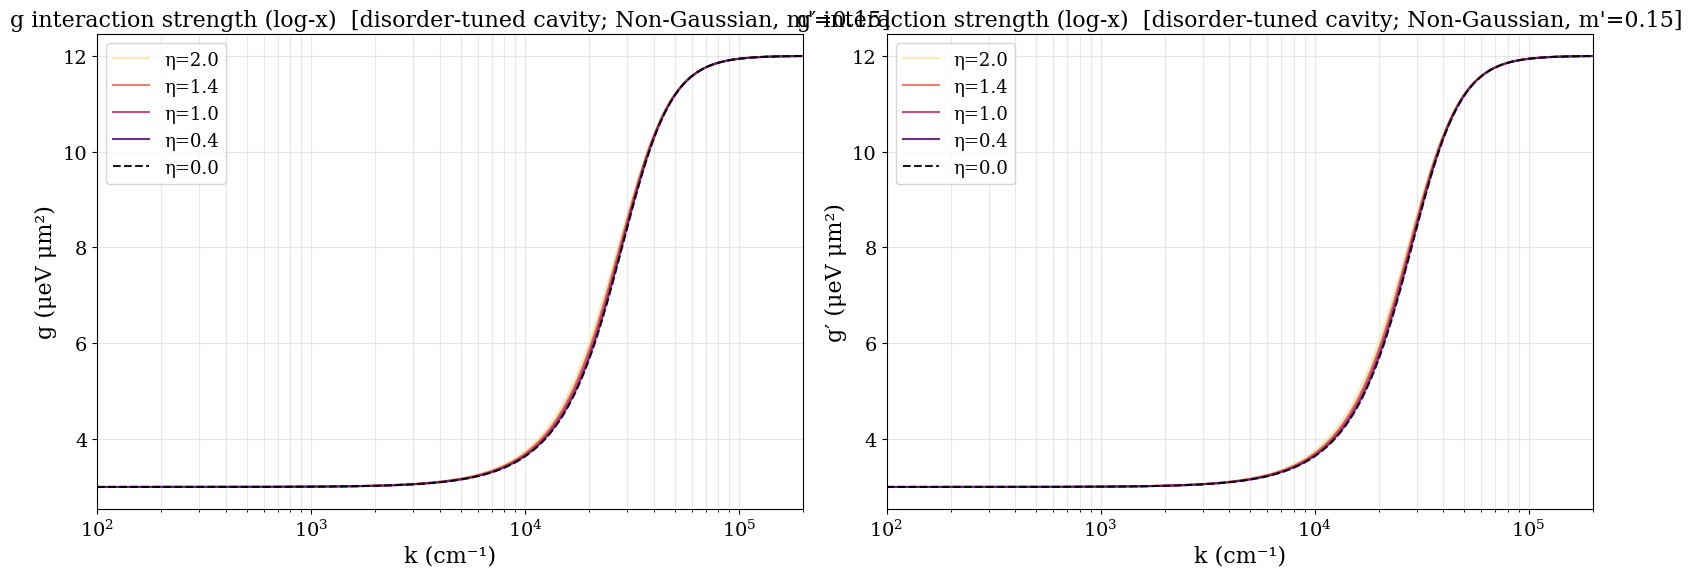

Saved  Plots/nongaussian_mprime0p15/g_interactions_logx_nongaussian_mprime0p15_disorder_free__cavity=disorder_free.png


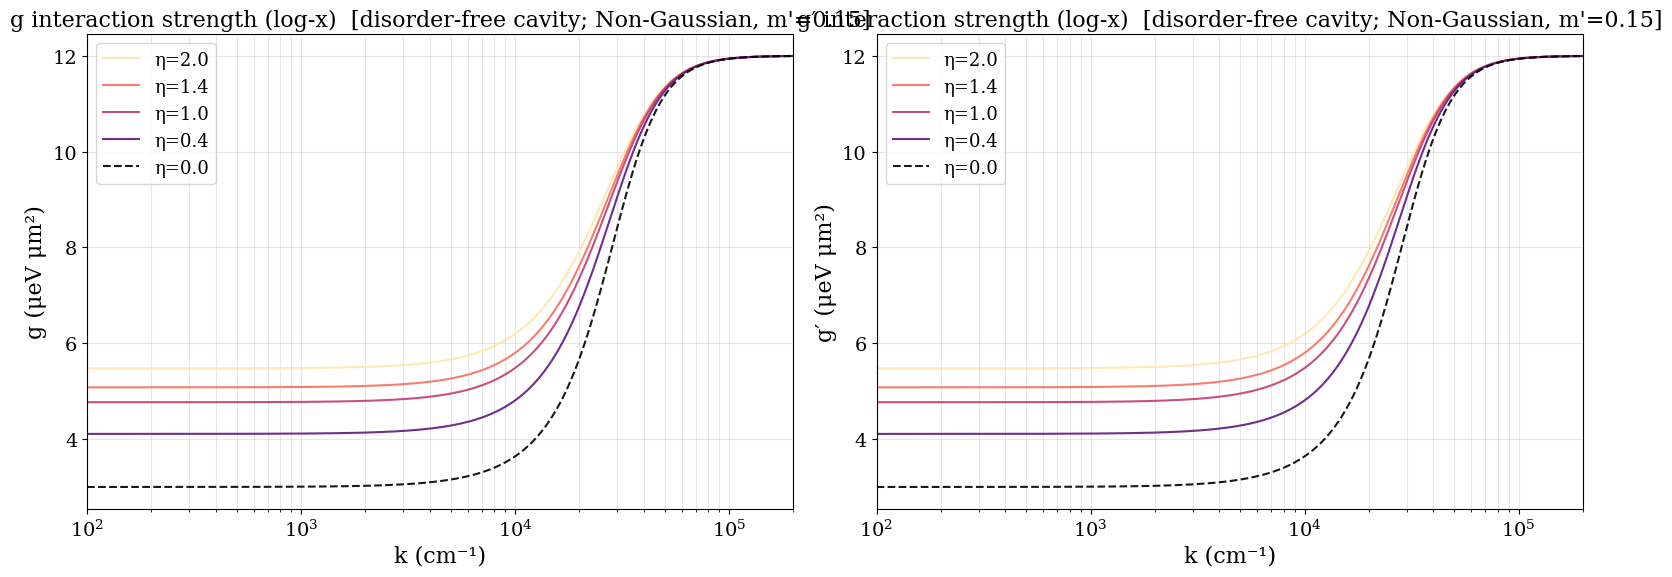

Saved  Plots/xi20nm_mprime0p15/g_interactions_logx_xi20nm_mprime0p15_disorder_tuned__cavity=disorder_tuned.png


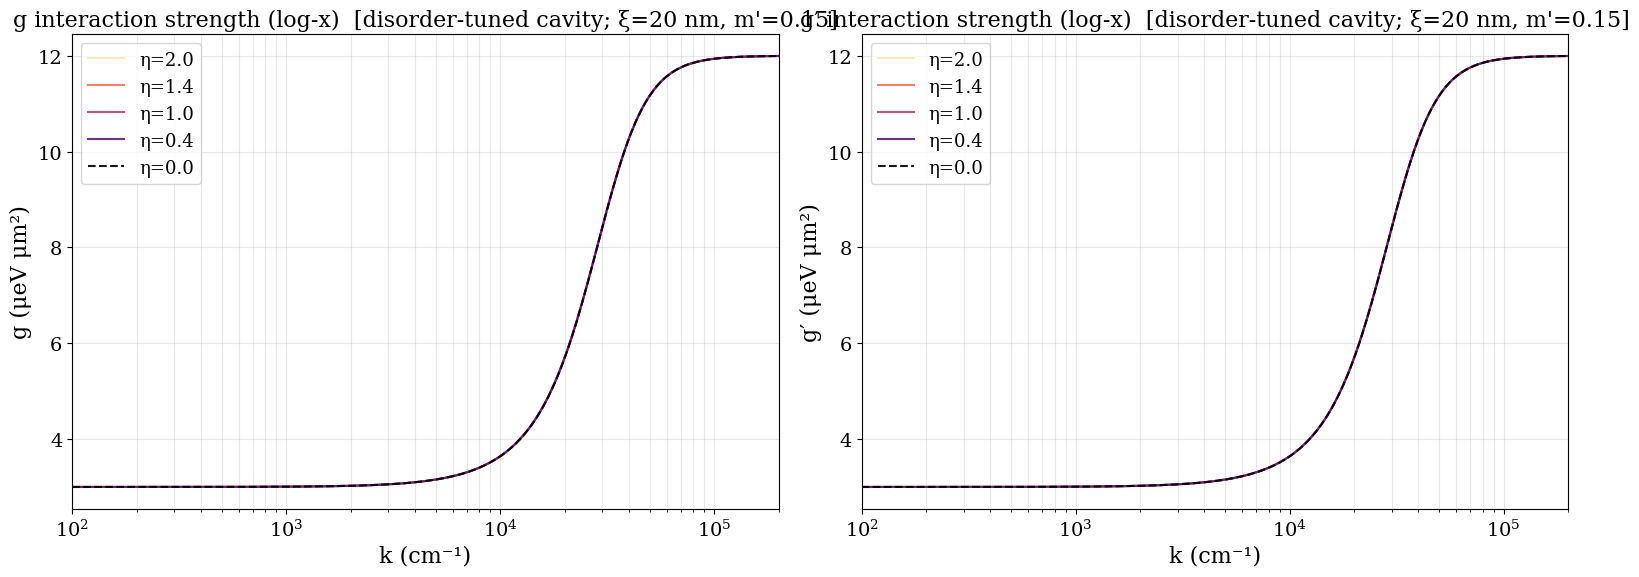

Saved  Plots/xi20nm_mprime0p15/g_interactions_logx_xi20nm_mprime0p15_disorder_free__cavity=disorder_free.png


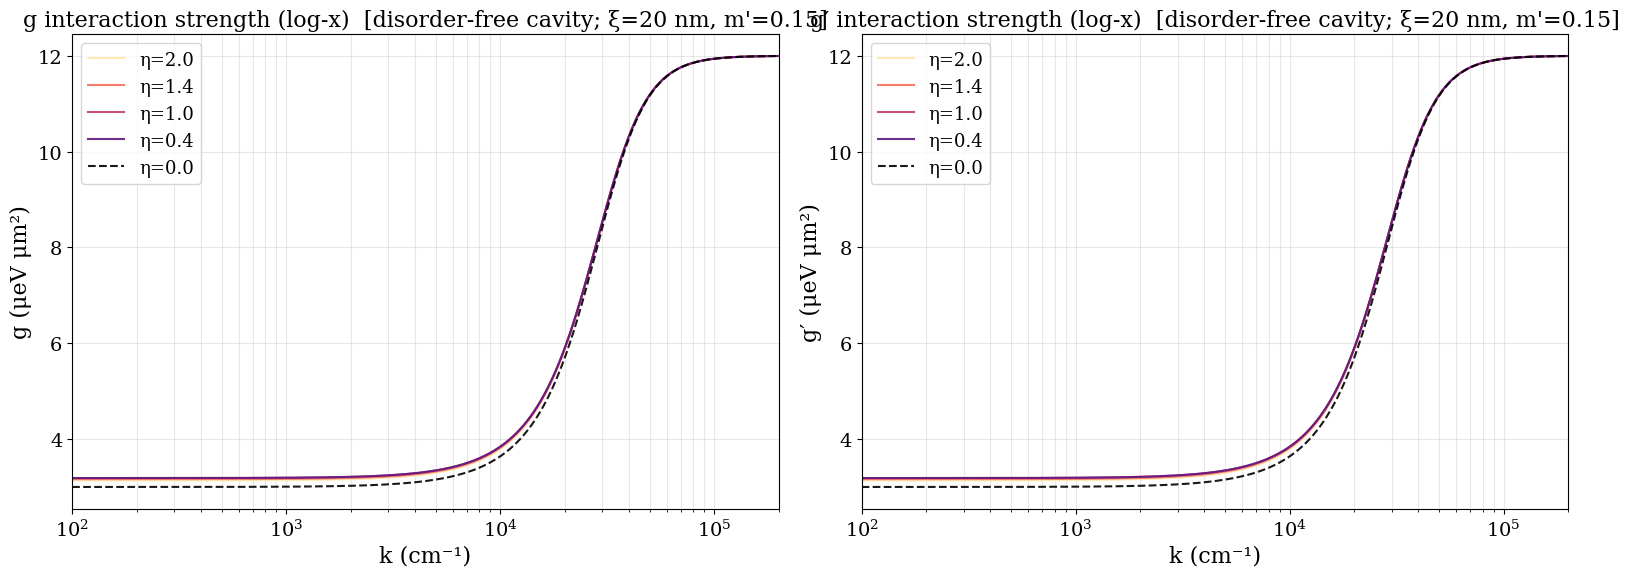

In [18]:
# Log-x interaction strength panel: extends k out to 2e5 cm^-1.
for plot_context in plot_contexts:
	apply_context(plot_context)
	for tuned in (True, False):
		bubble_cache = {}
		data, stem, _, k_cm = load_or_compute_interaction_grid(
			plot_context,
			disorder_tuned=tuned,
			grid_role="logx_extended",
			bubble_cache=bubble_cache,
		)
		fig, axs = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
		panels = [(axs[0], 0, "g", f"g ({INTERACTION_UNIT_LABEL})"),
		          (axs[1], 1, "g′", f"g′ ({INTERACTION_UNIT_LABEL})")]
		for ax, q_idx, q_label, y_label in panels:
			for ei in selected_eta_indices():
				eta = float(eta_grid[ei])
				clr, linestyle = eta_line_style(ei, eta, linestyle="-")
				y = interaction_nat_to_microev_um2(data[q_idx, ei, :], p_nat)
				ax.plot(k_cm, y, color=clr, linestyle=linestyle, label=f"η={eta:.1f}", alpha=0.9)
			ax.set_xscale("log")
			ax.set_xlabel(f"k ({CM_INV_LABEL})")
			ax.set_ylabel(y_label)
			ax.set_xlim(INTERACTION_LOGX_MIN_CM, INTERACTION_LOGX_MAX_CM)
			ax.grid(alpha=0.3, which="both")
			ax.legend()
			ax.set_title(f"{q_label} interaction strength (log-x)  [{cavity_label(tuned)}; {result_label_text}]")
			format_plot_ticks(ax, axes="y", formatter="smart", decimals=3, zero_tol=0.0)
		plt.tight_layout()
		save_figure(
			fig,
			f"g_interactions_logx_{result_slug_text}_{cavity_slug(tuned)}",
			meta={
				**context_metadata(plot_context),
				"disorder_tuned": tuned,
				"interaction_result_stem": stem,
				"grid_role": "logx_extended",
				"k_min_cm_inv": INTERACTION_LOGX_MIN_CM,
				"k_max_cm_inv": INTERACTION_LOGX_MAX_CM,
				"n_k": INTERACTION_LOGX_POINTS,
				"x_scale": "log",
				"interaction_unit": INTERACTION_UNIT_LABEL,
			},
			file_meta_suffix={"cavity": cavity_slug(tuned)},
		)
		plt.show()
		plt.close(fig)


## Interaction strength at k=0 vs temperature

Exact k=0 values for bare and screened interactions across temperature.


Saved  Plots/nongaussian_mprime0p15/g_k0_vs_temperature_nongaussian_mprime0p15_disorder_tuned.png


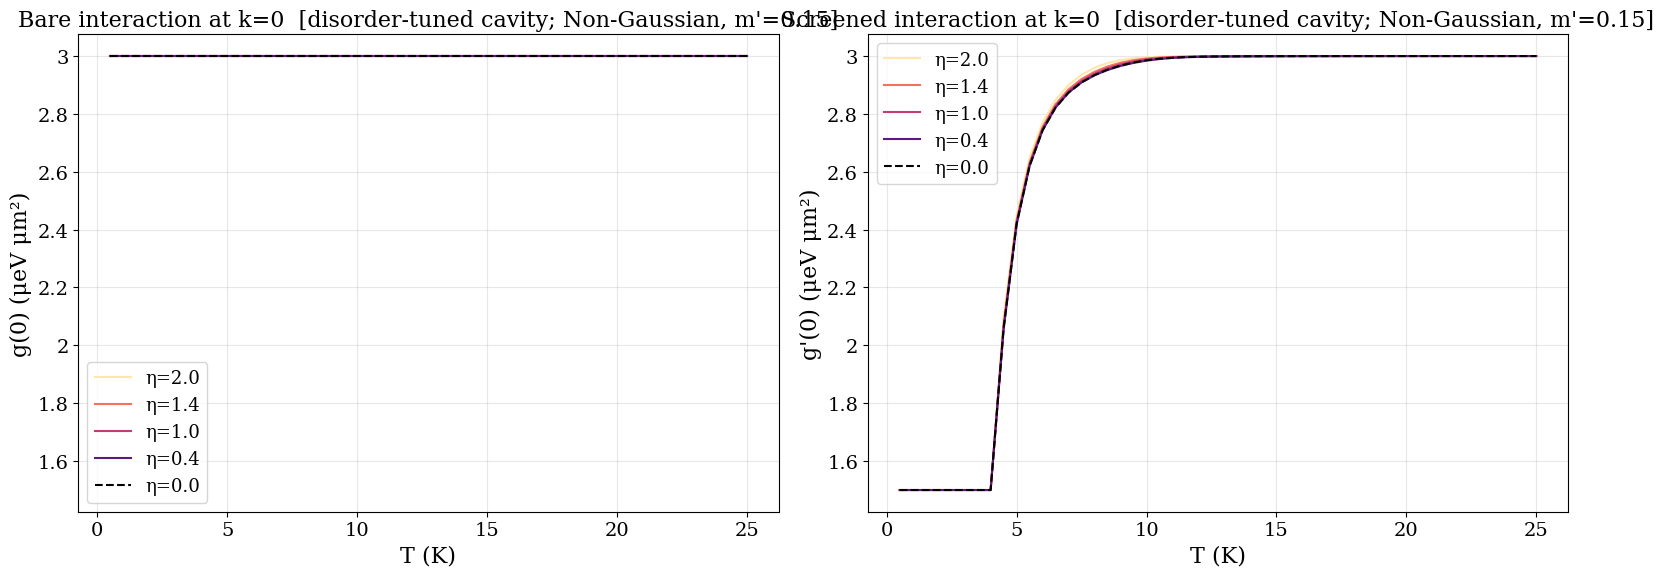

KeyboardInterrupt: 

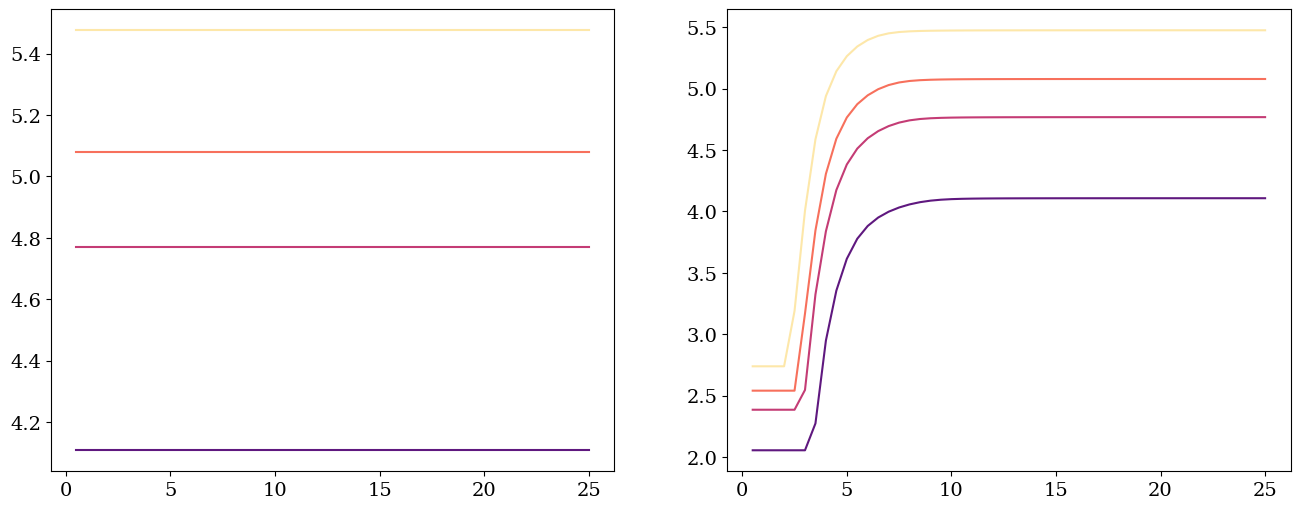

In [19]:
# Adaptive L_terms scales the Bose-Einstein fugacity series so the truncated
# sum still converges at low T (where many higher-order terms contribute).
# Empirically, L_terms ~ 5/(k_B*T_nat) gives <1% truncation error down to ~2.5K.
from polaritons.many_body import hopfield_coefficients  # T=0 fallback for g'

def adaptive_L_terms(T_K: float, p_nat, *, base: int = 1000, scale: float = 5.0, cap: int = 200_000) -> int:
	beta_nat = 1.0 / (p_nat.k_B * float(T_K))
	return int(min(cap, max(base, np.ceil(scale * beta_nat))))


TEMPERATURES = np.linspace(0.5, 25.0, 50)  # K  (extended down to 0.5 K so the T->0 limit is visible)
K_ZERO = np.array([0.0])
TEMP_N_K_MU = 30_000
TEMP_K_UPPER_MASS = 1e-3
TEMP_N_K_MASS = 64

for plot_context in plot_contexts:
	apply_context(plot_context)

	# Q is independent of T, so build the DispersionModel once and pass the
	# temperature in via beta = 1 / (k_B * T_nat).  This avoids rebuilding the
	# k-spline per temperature.
	temp_model = DispersionModel(p_nat, q_picard, eta_grid, Q_results)

	for tuned in (True, False):
		fig, axs = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

		# Track per-eta curves so we can apply a shared y-range across panels.
		bare_curves = []
		screened_curves = []

		low_T_K = []
		for ei in selected_eta_indices():
			eta_value = float(eta_grid[ei])
			clr, linestyle = eta_line_style(ei, eta_value, linestyle="-")
			zorder = 10 if np.isclose(eta_value, 0.0, atol=1e-12) else 2
			# First pass: attempt the full RPA series at every T; record failures.
			bare_vals     = [np.nan] * len(TEMPERATURES)
			screened_vals = [np.nan] * len(TEMPERATURES)
			failed_idx    = []
			for k_idx, T in enumerate(TEMPERATURES):
				L_terms_T = adaptive_L_terms(float(T), p_nat)
				beta_T    = 1.0 / (p_nat.k_B * float(T))
				try:
					bubble = Pi0(
						temp_model, eta_value,
						beta=beta_T,
						L_terms=L_terms_T,
						k_upper=K_UPPER,
						n_k=TEMP_N_K_MU,
						k_upper_mass=TEMP_K_UPPER_MASS,
						n_k_mass=TEMP_N_K_MASS,
						disorder_tuned=tuned,
					)
					g_bare, g_screened = polariton_interaction_strength(
						temp_model, eta_value, K_ZERO,
						beta=beta_T,
						L_terms=L_terms_T,
						k_upper=K_UPPER,
						n_k=TEMP_N_K_MU,
						k_upper_mass=TEMP_K_UPPER_MASS,
						n_k_mass=TEMP_N_K_MASS,
						disorder_tuned=tuned,
						bubble=bubble,
					)
					bare_vals[k_idx]     = float(g_bare[0])
					screened_vals[k_idx] = float(g_screened[0])
				except ValueError:
					failed_idx.append(k_idx)
					low_T_K.append(float(T))

			# T -> 0 closed form (RPA gives g'(k) -> g(k)/2 as mu -> 0^-).
			X_LP, _ = hopfield_coefficients(temp_model, eta_value, K_ZERO, disorder_tuned=tuned)
			g_bare_0     = float((p_nat.g_ex / p_nat.N_qw) * X_LP[0]**4)
			g_screened_0 = 0.5 * g_bare_0

			# Smoothly interpolate the failed (low-T) range linearly from the
			# lowest converged T down to the T=0 analytic limit at T=0.  This
			# replaces the previous abrupt jump to the T=0 closed form.
			failed_set = set(failed_idx)
			converged_idx = [k for k in range(len(TEMPERATURES)) if k not in failed_set]
			if failed_idx and converged_idx:
				k_min_c   = min(converged_idx)
				T_min_c   = float(TEMPERATURES[k_min_c])
				bare_c    = bare_vals[k_min_c]
				scr_c     = screened_vals[k_min_c]
				for k_idx in failed_idx:
					T = float(TEMPERATURES[k_idx])
					frac = T / T_min_c if T_min_c > 0.0 else 0.0
					bare_vals[k_idx]     = g_bare_0     + (bare_c - g_bare_0) * frac
					screened_vals[k_idx] = g_screened_0 + (scr_c  - g_screened_0) * frac
			elif failed_idx:
				for k_idx in failed_idx:
					bare_vals[k_idx]     = g_bare_0
					screened_vals[k_idx] = g_screened_0

			bare_arr     = interaction_nat_to_microev_um2(np.asarray(bare_vals),     p_nat)
			screened_arr = interaction_nat_to_microev_um2(np.asarray(screened_vals), p_nat)
			bare_curves.append(bare_arr)
			screened_curves.append(screened_arr)
			axs[0].plot(TEMPERATURES, bare_arr,     color=clr, linestyle=linestyle, label=f"η={eta_value:.1f}", zorder=zorder)
			axs[1].plot(TEMPERATURES, screened_arr, color=clr, linestyle=linestyle, label=f"η={eta_value:.1f}", zorder=zorder)

		# Fixed shared y-axis range (user-specified).
		for ax in axs:
			ax.set_ylim(0.0, 3.05)

		for ax in axs:
			ax.set_xlabel("T (K)")
			ax.grid(alpha=0.3)
			ax.legend()
			format_plot_ticks(ax)
		axs[0].set_ylabel(f"g(0) ({INTERACTION_UNIT_LABEL})")
		axs[1].set_ylabel(f"g'(0) ({INTERACTION_UNIT_LABEL})")
		axs[0].set_title(f"Bare interaction at k=0  [{cavity_label(tuned)}; {result_label_text}]")
		axs[1].set_title(f"Screened interaction at k=0  [{cavity_label(tuned)}; {result_label_text}]")
		plt.tight_layout()
		save_figure(fig, f"g_k0_vs_temperature_{result_slug_text}_{cavity_slug(tuned)}", meta={
			**context_metadata(plot_context),
			"disorder_tuned": tuned,
			"temperatures_K": TEMPERATURES.tolist(),
			"L_terms_per_T": [adaptive_L_terms(float(T), p_nat) for T in TEMPERATURES],
			"k_upper_natural": K_UPPER,
			"n_k": TEMP_N_K_MU,
			"n_k_mu": TEMP_N_K_MU,
			"k_upper_mass_natural": TEMP_K_UPPER_MASS,
			"n_k_mass": TEMP_N_K_MASS,
			"shared_y_axis": True,
			"y_range": [0.0, 3.05],
			"t_zero_limit_T_K": sorted(set(low_T_K)),
		})
		plt.show()
		plt.close(fig)
